# Bitcoin and Gold under Economic Policy Uncertainty and Geopolitical Risk


### Preliminary analysis

Prepare one common daily sample, transform prices into returns or changes, examine stationarity, and diagnose the statistical features that determine the later models.

### Pillar 1 — Return-response channel

Estimate whether contemporaneous changes in EPU and GPR are associated with Bitcoin and gold returns:

1. controlled OLS with HAC standard errors;
2. post-estimation checks of the conditional-mean equations;
3. quantile regression using the same regressors.

### Pillar 2 — Hedge, safe-haven, and portfolio-risk channel

$$
\text{returns}
\longrightarrow
\text{GARCH volatility filters}
\longrightarrow
\text{standardised shocks}
\longrightarrow
\text{DCC correlations}
\longrightarrow
\text{regime tests}
\longrightarrow
\text{portfolio-risk evaluation}.
$$

- **GARCH** estimates each asset's changing volatility and produces comparable standardised shocks.
- **DCC** estimates one Bitcoin–S&P 500 and one gold–S&P 500 conditional correlation for every day.
- **Regime inference** tests whether those daily correlations change during HighEPU, HighGPR, HighVIX, and S&P 500 downside conditions.
- **Robustness** checks standard GARCH-DCC, tighter regimes, global optimization, S&P 500 ex-Magnificent Seven series
- **Portfolio analysis** combines volatility and correlation to assess whether adding Bitcoin or gold reduces equity-portfolio risk.


The notebook contains analysis explanations and result interpretation only. Literature discussion and report-writing material are excluded.


# PRELIMINARY ANALYSIS


## A1. Data preparation and variable design

Create one common trading-day sample.  
The Pillar 1 exposures are current-day EPU and GPR changes, while VIX, WTI, DXY, and DGS10 controls are lagged by one trading day.

> Gold exposure is represented by SPDR Gold Shares (GLD), a tradable proxy for gold rather than the spot gold price.


In [ ]:
# STEP 0.1 — IMPORTS AND RESEARCH SETTINGS
# Install once if required:
# !pip install yfinance pandas numpy scipy statsmodels openpyxl

from pathlib import Path
import warnings

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm

from scipy.stats import skew, kurtosis, jarque_bera
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.stats.diagnostic import (
    acorr_ljungbox,
    het_arch,
    het_breuschpagan,
    linear_reset
)
from statsmodels.stats.stattools import durbin_watson
from statsmodels.stats.outliers_influence import variance_inflation_factor
from IPython.display import display

warnings.filterwarnings("ignore")

START_DATE = "2020-12-31"
END_DATE = "2026-04-01"

# Update these paths before running.
EPU_FILE = "../data/US_EPU_daily.csv"
GPR_FILE = "../data/GPR_daily.csv"
DGS10_FILE = "../data/DGS10.csv"
SP500_EX7_FILE = "../data/SP500Ex7.csv"

SAVE_OUTPUTS = False
OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

TICKERS = {
    "BTC": "BTC-USD",
    "Gold": "GLD",
    "SP500": "^GSPC",
    "VIX": "^VIX",
    "WTI": "CL=F",
    "DXY": "DX-Y.NYB"
}

HAC_LAGS = 5
SIGNIFICANCE_LEVEL = 0.05
HIGH_REGIME_QUANTILE = 0.80

QUANTILES = [0.10, 0.25, 0.50]
QR_BOOTSTRAP_REPS = 300
QR_BLOCK_LENGTH = 10
RANDOM_SEED = 20260724
RUN_QR_BOOTSTRAP = True


In [2]:
# STEP 0.2 — HELPER FUNCTIONS

def save_table(df, filename):
    if SAVE_OUTPUTS:
        path = OUTPUT_DIR / filename
        df.to_csv(path, index=False)
        print(f"Saved: {path}")
    return df


def display_report_table(df, title=None, decimals=5):
    if title:
        print(f"\n{title}")
    display(df.round(decimals))


def run_adf(series):
    x = pd.Series(series).dropna().astype(float)
    stat, p_value, *_ = adfuller(x, autolag="AIC")
    return stat, p_value


def run_kpss(series):
    x = pd.Series(series).dropna().astype(float)
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        stat, p_value, *_ = kpss(x, regression="c", nlags="auto")
    return stat, p_value


def descriptive_statistics(df, columns):
    rows = []

    for col in columns:
        x = df[col].dropna().astype(float)

        try:
            jb_stat, jb_p = jarque_bera(x)
        except Exception:
            jb_stat, jb_p = np.nan, np.nan

        try:
            adf_stat, adf_p = run_adf(x)
        except Exception:
            adf_stat, adf_p = np.nan, np.nan

        try:
            kpss_stat, kpss_p = run_kpss(x)
        except Exception:
            kpss_stat, kpss_p = np.nan, np.nan

        rows.append({
            "Variable": col,
            "Observations": len(x),
            "Mean": x.mean(),
            "Std Dev": x.std(),
            "Minimum": x.min(),
            "Maximum": x.max(),
            "Skewness": skew(x),
            "Kurtosis": kurtosis(x, fisher=False),
            "Jarque-Bera statistic": jb_stat,
            "Jarque-Bera p-value": jb_p,
            "ADF statistic": adf_stat,
            "ADF p-value": adf_p,
            "KPSS statistic": kpss_stat,
            "KPSS p-value": kpss_p
        })

    return pd.DataFrame(rows)


def preliminary_return_test(series, asset_name, lb_lags=(10, 20), arch_lags=10):
    # Preliminary tests on demeaned raw returns.
    x = pd.Series(series).dropna().astype(float)
    simple_mean_resid = x - x.mean()

    lb_return = acorr_ljungbox(
        simple_mean_resid,
        lags=list(lb_lags),
        return_df=True
    )
    lb_squared = acorr_ljungbox(
        simple_mean_resid.pow(2),
        lags=list(lb_lags),
        return_df=True
    )

    arch_lm_stat, arch_lm_p, arch_f_stat, arch_f_p = het_arch(
        simple_mean_resid,
        nlags=arch_lags
    )
    return {
        "Asset": asset_name,
        f"LB return p ({lb_lags[0]})": lb_return.loc[lb_lags[0], "lb_pvalue"],
        f"LB return p ({lb_lags[1]})": lb_return.loc[lb_lags[1], "lb_pvalue"],
        f"LB squared p ({lb_lags[0]})": lb_squared.loc[lb_lags[0], "lb_pvalue"],
        f"LB squared p ({lb_lags[1]})": lb_squared.loc[lb_lags[1], "lb_pvalue"],
        f"ARCH-LM statistic ({arch_lags})": arch_lm_stat,
        f"ARCH-LM p-value ({arch_lags})": arch_lm_p
    }


def calculate_vif(df, variables):
    variables = [v for v in variables if v in df.columns]
    X = df[variables].dropna().astype(float)
    X = sm.add_constant(X, has_constant="add")

    rows = []
    for i, variable in enumerate(X.columns):
        rows.append({
            "Variable": variable,
            "VIF": variance_inflation_factor(X.values, i)
        })

    result = pd.DataFrame(rows)
    return (
        result[result["Variable"] != "const"]
        .sort_values("VIF", ascending=False)
        .reset_index(drop=True)
    )


def run_hac_ols(df, y_var, x_vars, model_name, maxlags=HAC_LAGS):
    model_data = df[[y_var] + list(x_vars)].dropna().copy()
    y = model_data[y_var].astype(float)
    X = sm.add_constant(model_data[list(x_vars)].astype(float), has_constant="add")

    model = sm.OLS(y, X).fit(
        cov_type="HAC",
        cov_kwds={"maxlags": maxlags}
    )

    ci = model.conf_int(alpha=0.05)

    result_table = pd.DataFrame({
        "Model": model_name,
        "Dependent Variable": y_var,
        "Variable": model.params.index,
        "Coefficient": model.params.values,
        "HAC Std Error": model.bse.values,
        "t-statistic": model.tvalues.values,
        "p-value": model.pvalues.values,
        "CI 95% Low": ci.iloc[:, 0].values,
        "CI 95% High": ci.iloc[:, 1].values,
        "Observations": int(model.nobs),
        "R-squared": model.rsquared,
        "Adjusted R-squared": model.rsquared_adj
    })

    return model, result_table, model_data


def ols_residual_diagnostics(model, model_name, lb_lags=(10, 20), arch_lags=10):
    resid = pd.Series(model.resid).dropna().astype(float)

    lb_return = acorr_ljungbox(resid, lags=list(lb_lags), return_df=True)
    lb_squared = acorr_ljungbox(resid.pow(2), lags=list(lb_lags), return_df=True)

    arch_lm_stat, arch_lm_p, arch_f_stat, arch_f_p = het_arch(
        resid,
        nlags=arch_lags
    )
    bp_lm_stat, bp_lm_p, bp_f_stat, bp_f_p = het_breuschpagan(
        resid,
        model.model.exog
    )

    try:
        reset_result = linear_reset(model, power=2, use_f=True)
        reset_stat = float(reset_result.fvalue)
        reset_p = float(reset_result.pvalue)
    except Exception:
        reset_stat, reset_p = np.nan, np.nan

    jb_stat, jb_p = jarque_bera(resid)

    return {
        "Model": model_name,
        "Observations": len(resid),
        "Durbin-Watson": durbin_watson(resid),
        "Jarque-Bera statistic": jb_stat,
        "Jarque-Bera p-value": jb_p,
        f"LB residual p ({lb_lags[0]})": lb_return.loc[lb_lags[0], "lb_pvalue"],
        f"LB residual p ({lb_lags[1]})": lb_return.loc[lb_lags[1], "lb_pvalue"],
        f"LB squared residual p ({lb_lags[0]})": lb_squared.loc[lb_lags[0], "lb_pvalue"],
        f"LB squared residual p ({lb_lags[1]})": lb_squared.loc[lb_lags[1], "lb_pvalue"],
        f"ARCH-LM statistic ({arch_lags})": arch_lm_stat,
        f"ARCH-LM p-value ({arch_lags})": arch_lm_p,
        "Breusch-Pagan statistic": bp_lm_stat,
        "Breusch-Pagan p-value": bp_lm_p,
        "RESET statistic": reset_stat,
        "RESET p-value": reset_p
    }


def run_quantile_models(df, y_var, x_vars, quantiles=QUANTILES):
    model_data = df[[y_var] + list(x_vars)].dropna().copy()
    y = model_data[y_var].astype(float)
    X = sm.add_constant(model_data[list(x_vars)].astype(float), has_constant="add")

    models = {}
    rows = []

    for q in quantiles:
        result = sm.QuantReg(y, X).fit(
            q=q,
            max_iter=10000,
            p_tol=1e-8,
            vcov="robust"
        )
        models[q] = result

        for variable in result.params.index:
            rows.append({
                "Dependent Variable": y_var,
                "Quantile": q,
                "Variable": variable,
                "Coefficient": result.params[variable],
                "Robust Std Error": result.bse[variable],
                "t-statistic": result.tvalues[variable],
                "p-value": result.pvalues[variable],
                "Observations": int(result.nobs),
                "Pseudo R-squared": result.prsquared,
                "Iterations": getattr(result, "iterations", np.nan)
            })

    return models, pd.DataFrame(rows), model_data


def moving_block_indices(n, block_length, rng):
    if block_length < 1:
        raise ValueError("block_length must be at least 1.")
    block_length = min(block_length, n)
    number_of_blocks = int(np.ceil(n / block_length))
    starts = rng.integers(
        low=0,
        high=n - block_length + 1,
        size=number_of_blocks
    )
    indices = np.concatenate([
        np.arange(start, start + block_length)
        for start in starts
    ])
    return indices[:n]


def block_bootstrap_quantile_difference(
    model_data,
    y_var,
    x_vars,
    variables_to_test=("d_EPU_100", "d_GPR_100"),
    q_low=0.10,
    q_reference=0.50,
    reps=QR_BOOTSTRAP_REPS,
    block_length=QR_BLOCK_LENGTH,
    seed=RANDOM_SEED
):
    # Moving-block bootstrap for coefficient(q_low) - coefficient(q_reference).
    data = model_data[[y_var] + list(x_vars)].dropna().reset_index(drop=True)
    n = len(data)
    rng = np.random.default_rng(seed)

    y_original = data[y_var].astype(float)
    X_original = sm.add_constant(
        data[list(x_vars)].astype(float),
        has_constant="add"
    )

    original_low = sm.QuantReg(y_original, X_original).fit(
        q=q_low, max_iter=10000, p_tol=1e-8, vcov="robust"
    )
    original_reference = sm.QuantReg(y_original, X_original).fit(
        q=q_reference, max_iter=10000, p_tol=1e-8, vcov="robust"
    )

    observed = {
        variable: (
            original_low.params[variable]
            - original_reference.params[variable]
        )
        for variable in variables_to_test
    }

    bootstrap_differences = {
        variable: []
        for variable in variables_to_test
    }

    for _ in range(reps):
        idx = moving_block_indices(n, block_length, rng)
        sample = data.iloc[idx].reset_index(drop=True)

        y_boot = sample[y_var].astype(float)
        X_boot = sm.add_constant(
            sample[list(x_vars)].astype(float),
            has_constant="add"
        )

        try:
            low_result = sm.QuantReg(y_boot, X_boot).fit(
                q=q_low, max_iter=10000, p_tol=1e-7, vcov="robust"
            )
            reference_result = sm.QuantReg(y_boot, X_boot).fit(
                q=q_reference, max_iter=10000, p_tol=1e-7, vcov="robust"
            )

            for variable in variables_to_test:
                bootstrap_differences[variable].append(
                    low_result.params[variable]
                    - reference_result.params[variable]
                )
        except Exception:
            continue

    rows = []

    for variable in variables_to_test:
        values = np.asarray(bootstrap_differences[variable], dtype=float)
        values = values[np.isfinite(values)]

        if len(values) == 0:
            rows.append({
                "Variable": variable,
                "Low quantile": q_low,
                "Reference quantile": q_reference,
                "Observed coefficient difference": observed[variable],
                "Bootstrap CI 2.5%": np.nan,
                "Bootstrap CI 97.5%": np.nan,
                "Bootstrap p-value": np.nan,
                "Successful repetitions": 0
            })
            continue

        lower = np.quantile(values, 0.025)
        upper = np.quantile(values, 0.975)

        share_nonpositive = np.mean(values <= 0)
        share_nonnegative = np.mean(values >= 0)
        p_value = min(1.0, 2 * min(share_nonpositive, share_nonnegative))

        rows.append({
            "Variable": variable,
            "Low quantile": q_low,
            "Reference quantile": q_reference,
            "Observed coefficient difference": observed[variable],
            "Bootstrap CI 2.5%": lower,
            "Bootstrap CI 97.5%": upper,
            "Bootstrap p-value": p_value,
            "Successful repetitions": len(values)
        })

    return pd.DataFrame(rows)


In [3]:
# STEP 0.3 — LOAD RAW DATA AND CHECK COVERAGE

for local_file in [EPU_FILE, GPR_FILE, DGS10_FILE]:
    if not Path(local_file).exists():
        print(f"WARNING: local file not found — update path before running: {local_file}")

raw_market = yf.download(
    tickers=list(TICKERS.values()),
    start=START_DATE,
    end=END_DATE,
    interval="1d",
    auto_adjust=True,
    group_by="ticker",
    progress=True
)

market_levels = pd.DataFrame(index=raw_market.index)

for name, ticker in TICKERS.items():
    market_levels[name] = raw_market[ticker]["Close"]

market_levels.index = pd.to_datetime(market_levels.index)
market_levels.index.name = "Date"
market_levels = market_levels.sort_index()

epu_raw = pd.read_csv(EPU_FILE)
epu_raw.columns = epu_raw.columns.str.strip()
epu_raw["Date"] = pd.to_datetime(
    dict(
        year=epu_raw["year"],
        month=epu_raw["month"],
        day=epu_raw["day"]
    ),
    errors="coerce"
)
epu = epu_raw[["Date", "daily_policy_index"]].copy()
epu = epu.rename(columns={"daily_policy_index": "EPU"})
epu["EPU"] = pd.to_numeric(epu["EPU"], errors="coerce")
epu = (
    epu.dropna(subset=["Date", "EPU"])
    .set_index("Date")
    .sort_index()
    .loc[START_DATE:END_DATE]
)

gpr_raw = pd.read_csv(GPR_FILE)
gpr_raw.columns = gpr_raw.columns.str.strip()

if "date" in gpr_raw.columns:
    gpr_raw["Date"] = pd.to_datetime(gpr_raw["date"], errors="coerce")
else:
    gpr_raw["Date"] = pd.to_datetime(
        gpr_raw["DAY"].astype(str),
        format="%Y%m%d",
        errors="coerce"
    )

gpr_columns = [
    "Date", "GPRD", "GPRD_ACT", "GPRD_THREAT",
    "GPRD_MA30", "GPRD_MA7"
]
gpr_columns = [column for column in gpr_columns if column in gpr_raw.columns]

gpr = gpr_raw[gpr_columns].copy()
gpr = gpr.rename(columns={
    "GPRD": "GPR",
    "GPRD_ACT": "GPR_ACT",
    "GPRD_THREAT": "GPR_THREAT",
    "GPRD_MA30": "GPR_MA30",
    "GPRD_MA7": "GPR_MA7"
})

for column in gpr.columns:
    if column != "Date":
        gpr[column] = pd.to_numeric(gpr[column], errors="coerce")

gpr = (
    gpr.dropna(subset=["Date", "GPR"])
    .set_index("Date")
    .sort_index()
    .loc[START_DATE:END_DATE]
)

dgs10_raw = pd.read_csv(DGS10_FILE)
dgs10_raw.columns = dgs10_raw.columns.str.strip()
dgs10_raw["Date"] = pd.to_datetime(
    dgs10_raw["observation_date"],
    errors="coerce"
)
dgs10_raw["DGS10"] = pd.to_numeric(
    dgs10_raw["DGS10"],
    errors="coerce"
)

dgs10 = dgs10_raw[["Date", "DGS10"]].copy()
dgs10 = (
    dgs10.dropna(subset=["Date"])
    .set_index("Date")
    .sort_index()
    .loc[START_DATE:END_DATE]
    .ffill()
)

def coverage_row(df, name):
    return {
        "Dataset": name,
        "Start date": df.index.min(),
        "End date": df.index.max(),
        "Observations": len(df),
        "Missing values": int(df.isna().sum().sum())
    }

coverage_rows = []

for column in ["BTC", "Gold", "SP500", "VIX", "WTI", "DXY"]:
    coverage_rows.append(
        coverage_row(market_levels[[column]].dropna(), column)
    )

coverage_rows.extend([
    coverage_row(epu[["EPU"]].dropna(), "EPU"),
    coverage_row(gpr[["GPR"]].dropna(), "GPR"),
    coverage_row(dgs10[["DGS10"]].dropna(), "DGS10")
])

coverage_table = pd.DataFrame(coverage_rows)
display_report_table(coverage_table, "Data coverage before merging")
#save_table(coverage_table, "01_data_coverage.csv")


[*********************100%***********************]  6 of 6 completed



Data coverage before merging


,Dataset,Start date,End date,Observations,Missing values
0,BTC,2020-12-31,2026-03-31,1917,0
1,Gold,2020-12-31,2026-03-31,1317,0
2,SP500,2020-12-31,2026-03-31,1317,0
3,VIX,2020-12-31,2026-03-31,1317,0
4,WTI,2020-12-31,2026-03-31,1319,0
5,DXY,2020-12-31,2026-03-31,1319,0
6,EPU,2020-12-31,2026-04-01,1918,0
7,GPR,2020-12-31,2026-04-01,1918,0
8,DGS10,2020-12-31,2026-04-01,1370,0


In [4]:
# STEP 0.4 — CREATE THE COMMON SAMPLE AND MODELLING VARIABLES

level_data = market_levels.join(epu, how="inner")
level_data = level_data.join(gpr, how="inner")
level_data = level_data.join(dgs10, how="inner")

core_level_columns = [
    "BTC", "Gold", "SP500", "VIX",
    "WTI", "DXY", "EPU", "GPR", "DGS10"
]

level_data = (
    level_data.dropna(subset=core_level_columns)
    .sort_index()
)

master = level_data.copy()

for variable in ["BTC", "Gold", "SP500", "WTI", "DXY"]:
    master[f"{variable}_ret"] = np.log(
        master[variable] / master[variable].shift(1)
    )

master["VIX_level"] = master["VIX"]
master["dVIX"] = master["VIX"].diff()

for variable in ["EPU", "GPR"]:
    master[f"{variable}_level"] = master[variable]
    master[f"d_{variable}"] = master[variable].diff()

master["DGS10_level"] = master["DGS10"]
master["d_DGS10_bp"] = master["DGS10_level"].diff() * 100

for variable in ["GPR_ACT", "GPR_THREAT", "GPR_MA30", "GPR_MA7"]:
    if variable in master.columns:
        master[f"{variable}_level"] = master[variable]
        master[f"d_{variable}"] = master[variable].diff()

master["d_EPU_100"] = master["d_EPU"] / 100
master["d_GPR_100"] = master["d_GPR"] / 100

lagged_control_map = {
    "dVIX": "dVIX_lag1",
    "WTI_ret": "WTI_ret_lag1",
    "DXY_ret": "DXY_ret_lag1",
    "d_DGS10_bp": "d_DGS10_bp_lag1"
}

for source, lagged_name in lagged_control_map.items():
    master[lagged_name] = master[source].shift(1)

PILLAR1_X_VARS = [
    "d_EPU_100",
    "d_GPR_100",
    "dVIX_lag1",
    "WTI_ret_lag1",
    "DXY_ret_lag1",
    "d_DGS10_bp_lag1"
]

master["HighEPU"] = (
    master["EPU_level"]
    >= master["EPU_level"].quantile(HIGH_REGIME_QUANTILE)
).astype(int)

master["HighGPR"] = (
    master["GPR_level"]
    >= master["GPR_level"].quantile(HIGH_REGIME_QUANTILE)
).astype(int)

required_columns = [
    "BTC_ret", "Gold_ret", "SP500_ret",
    "EPU_level", "GPR_level",
    *PILLAR1_X_VARS
]

master = master.dropna(subset=required_columns).copy()

print("Final common modelling sample")
print("Start date:", master.index.min().date())
print("End date:", master.index.max().date())
print("Observations:", len(master))
print("Pillar 1 regressors:", PILLAR1_X_VARS)

display(master.head())


Final common modelling sample
Start date: 2021-01-05
End date: 2026-03-31
Observations: 1315
Pillar 1 regressors: ['d_EPU_100', 'd_GPR_100', 'dVIX_lag1', 'WTI_ret_lag1', 'DXY_ret_lag1', 'd_DGS10_bp_lag1']


,BTC,Gold,SP500,VIX,WTI,DXY,EPU,GPR,GPR_ACT,GPR_THREAT,...,GPR_MA7_level,d_GPR_MA7,d_EPU_100,d_GPR_100,dVIX_lag1,WTI_ret_lag1,DXY_ret_lag1,d_DGS10_bp_lag1,HighEPU,HighGPR
Date,,,,,,,,,,,,,,,,,,,,,
2021-01-05,33992.429688,182.869995,3726.860107,25.340000,49.930000,89.440002,208.61,121.85,71.99,150.11,...,69.27,7.55,-0.2469,0.2252,4.219999,-0.018723,-0.000667,0.0,0,0
2021-01-06,36824.363281,179.899994,3748.139893,25.070000,50.630001,89.529999,139.81,106.57,35.41,169.85,...,76.04,6.77,-0.6880,-0.1528,-1.629999,0.047369,-0.004907,3.0,0,0
2021-01-07,39371.042969,179.479996,3803.790039,22.370001,50.830002,89.830002,124.29,54.24,24.95,76.32,...,72.25,-3.79,-0.1552,-0.5233,-0.270000,0.013922,0.001006,8.0,0,0
2021-01-08,40797.609375,173.339996,3824.679932,21.559999,52.240002,90.099998,104.80,77.74,51.67,86.19,...,74.03,1.78,-0.1949,0.2350,-2.699999,0.003942,0.003345,4.0,0,0
2021-01-11,35566.656250,173.000000,3799.610107,24.080000,52.250000,90.540001,308.70,84.14,35.32,110.47,...,85.71,11.68,2.0390,0.0640,-0.810001,0.027362,0.003001,5.0,1,0


## VARIABLE TIMING AND INTERPRETATION

| Concept | Model variable | Timing | Role |
|---|---|---|---|
| Bitcoin return | `BTC_ret` | Day \(t\) | Dependent variable |
| Gold proxy return (GLD) | `Gold_ret` | Day \(t\) | Dependent variable |
| EPU change | `d_EPU_100` | Day \(t\) | Main economic policy uncertainty exposure |
| GPR change | `d_GPR_100` | Day \(t\) | Main geopolitical-risk exposure |
| VIX change | `dVIX_lag1` | Day \(t-1\) | Prior financial-stress condition |
| WTI return | `WTI_ret_lag1` | Day \(t-1\) | Prior energy-market condition |
| DXY return | `DXY_ret_lag1` | Day \(t-1\) | Prior dollar condition |
| DGS10 change | `d_DGS10_bp_lag1` | Day \(t-1\) | Prior interest-rate condition |

The lagged controls do not establish causality. Their purpose is to condition on information already observed before the current return while reducing the risk of treating same-day transmission channels as if they were external confounders.


## A2. Descriptive statistics and stationarity


In [5]:
model_descriptive_variables = [
    "BTC_ret",
    "Gold_ret",
    "SP500_ret",
    "d_EPU",
    "d_GPR",
    "dVIX",
    "WTI_ret",
    "DXY_ret",
    "d_DGS10_bp"
]

model_descriptive_variables = [
    variable
    for variable in model_descriptive_variables
    if variable in master.columns
]

model_descriptive_table = descriptive_statistics(
    master,
    model_descriptive_variables
)

display_report_table(
    model_descriptive_table,
    "Panel A — Returns and daily changes",
    decimals=6
)
#save_table(model_descriptive_table, "03_descriptive_stationarity_model_variables.csv")

level_descriptive_variables = [
    "EPU_level",
    "GPR_level",
    "VIX_level",
    "DGS10_level"
]

level_descriptive_table = descriptive_statistics(
    master,
    level_descriptive_variables
)

display_report_table(
    level_descriptive_table,
    "Panel B — Levels retained for regimes or economic context",
    decimals=6
)
#save_table(level_descriptive_table, "04_descriptive_stationarity_levels.csv")



Panel A — Returns and daily changes


,Variable,Observations,Mean,Std Dev,Minimum,Maximum,Skewness,Kurtosis,Jarque-Bera statistic,Jarque-Bera p-value,ADF statistic,ADF p-value,KPSS statistic,KPSS p-value
0,BTC_ret,1315,0.000576,0.037083,-0.257227,0.191527,-0.279035,7.483799,1118.621093,0.0,-37.119230,0.0,0.116910,0.100000
1,Gold_ret,1315,0.000653,0.011189,-0.108412,0.061647,-0.903346,12.284082,4901.570352,0.0,-26.813485,0.0,0.607235,0.021979
2,SP500_ret,1315,0.000432,0.010606,-0.061609,0.090895,0.008683,9.313222,2183.835345,0.0,-22.695356,0.0,0.073451,0.100000
3,d_EPU,1315,0.114137,108.100689,-952.780000,872.820000,-0.126784,14.532117,7290.251978,0.0,-13.910771,0.0,0.075760,0.100000
4,d_GPR,1315,0.242837,48.795552,-188.440000,303.700000,0.303053,4.930757,224.382065,0.0,-13.638496,0.0,0.090097,0.100000
5,dVIX,1315,-0.001308,1.851572,-18.710003,15.290001,0.848701,23.552318,23301.742273,0.0,-15.668769,0.0,0.043445,0.100000
6,WTI_ret,1315,0.000575,0.023957,-0.139985,0.115187,-0.541595,6.327194,670.842871,0.0,-16.620062,0.0,0.138434,0.100000
7,DXY_ret,1315,0.000081,0.004464,-0.021394,0.016389,-0.343009,4.563017,159.643281,0.0,-14.015368,0.0,0.259311,0.100000
8,d_DGS10_bp,1315,0.256274,6.116614,-30.000000,28.000000,-0.117648,4.051801,63.648670,0.0,-27.676080,0.0,0.222007,0.100000



Panel B — Levels retained for regimes or economic context


,Variable,Observations,Mean,Std Dev,Minimum,Maximum,Skewness,Kurtosis,Jarque-Bera statistic,Jarque-Bera p-value,ADF statistic,ADF p-value,KPSS statistic,KPSS p-value
0,EPU_level,1315,185.160646,135.411505,5.39,1026.380000,1.797090,6.899444,1540.949421,0.0,-1.431252,0.567205,2.972470,0.01
1,GPR_level,1315,145.133567,67.578961,22.26,540.830000,1.825405,9.003740,2705.246163,0.0,-5.361721,0.000004,0.923449,0.01
2,VIX_level,1315,19.390525,5.257141,11.86,52.330002,1.229747,5.277537,615.654850,0.0,-5.824187,0.000000,1.157415,0.01
3,DGS10_level,1315,3.411536,1.134775,0.96,4.980000,-0.856139,2.191762,196.436058,0.0,-1.917718,0.323773,4.824709,0.01


### Interpretation — descriptive statistics and stationarity

Bitcoin is the most volatile asset, with a daily standard deviation of 3.71%. The corresponding values are 1.12% for gold and 1.06% for the S&P 500. All three return series reject normality and show heavy tails. Gold has the strongest negative skew and the highest kurtosis among the three assets.

ADF rejects a unit root for all returns and daily changes. KPSS also supports stationarity for most modelling variables. Gold returns are the only mixed case: ADF supports stationarity, while KPSS rejects it at 5%. Because gold is already expressed as a return series and the remaining diagnostics support modelling returns directly, it is retained without further differencing. The conflicting KPSS result is noted as a diagnostic limitation.

The level variables are more persistent and give mixed stationarity results. They are not used directly in the return regressions. EPU and GPR levels are used only to define high-uncertainty regimes.


## A3. Preliminary diagnostics on raw returns

These tests determine the initial mean and variance specifications for Bitcoin, gold, and the S&P 500.

- Ljung–Box on returns checks conditional-mean autocorrelation.
- Ljung–Box on squared returns checks volatility clustering.
- ARCH-LM checks ARCH effects (whether past squared shocks affect current variance).


In [6]:
preliminary_assets = {
    "Bitcoin": "BTC_ret",
    "Gold": "Gold_ret",
    "S&P 500": "SP500_ret"
}

preliminary_rows = []

for asset_name, return_variable in preliminary_assets.items():
    preliminary_rows.append(
        preliminary_return_test(
            master[return_variable],
            asset_name=asset_name,
            lb_lags=(10, 20),
            arch_lags=10
        )
    )

preliminary_diagnostics = pd.DataFrame(preliminary_rows)

preliminary_diagnostics["Raw-return mean autocorrelation at 5%"] = np.where(
    preliminary_diagnostics[
        ["LB return p (10)", "LB return p (20)"]
    ].min(axis=1) < SIGNIFICANCE_LEVEL,
    "Yes",
    "No"
)

preliminary_diagnostics["Volatility clustering at 5%"] = np.where(
    preliminary_diagnostics[
        ["LB squared p (10)", "LB squared p (20)"]
    ].min(axis=1) < SIGNIFICANCE_LEVEL,
    "Yes",
    "No"
)

preliminary_diagnostics["ARCH effects at 5%"] = np.where(
    preliminary_diagnostics["ARCH-LM p-value (10)"]
    < SIGNIFICANCE_LEVEL,
    "Yes",
    "No"
)

display_report_table(
    preliminary_diagnostics,
    "Preliminary diagnostics on raw returns",
    decimals=6
)
# save_table(preliminary_diagnostics, "05_preliminary_return_diagnostics.csv")



Preliminary diagnostics on raw returns


,Asset,LB return p (10),LB return p (20),LB squared p (10),LB squared p (20),ARCH-LM statistic (10),ARCH-LM p-value (10),Raw-return mean autocorrelation at 5%,Volatility clustering at 5%,ARCH effects at 5%
0,Bitcoin,0.216652,0.464911,0.000005,0.0,30.695725,0.000659,No,Yes,Yes
1,Gold,0.502269,0.240969,0.000000,0.0,157.124930,0.000000,No,Yes,Yes
2,S&P 500,0.414958,0.079740,0.000000,0.0,176.432344,0.000000,No,Yes,Yes


### Interpretation — preliminary return diagnostics

Ljung–Box tests do not find significant autocorrelation in Bitcoin, gold, or S&P 500 returns at 10 or 20 lags. The S&P 500 lag-20 p-value is 0.0797, which is weak evidence only at the 10% level. A constant mean is therefore a reasonable starting point for all GARCH candidates.

The squared-return Ljung–Box and ARCH-LM tests are strongly significant for every asset. Volatility is clustered even though mean returns are not predictable from their own lags. The high kurtosis and Jarque–Bera results in the descriptive table also support Student-\(t\) rather than Gaussian innovations.

Pillar 2 therefore uses GARCH models with a constant mean and Student-\(t\) innovations.


## A4. Correlation and multicollinearity


In [7]:
pillar1_correlation_variables = [
    "BTC_ret",
    "Gold_ret",
    *PILLAR1_X_VARS
]

pillar1_correlation_matrix = master[
    pillar1_correlation_variables
].corr()

display_report_table(
    pillar1_correlation_matrix,
    "Pillar 1 unconditional correlation matrix",
    decimals=4
)

correlation_export = (
    pillar1_correlation_matrix
    .reset_index()
    .rename(columns={"index": "Variable"})
)
#save_table(correlation_export, "06_pillar1_correlation_matrix.csv")

pillar1_vif = calculate_vif(master, PILLAR1_X_VARS)

display_report_table(
    pillar1_vif,
    "Pillar 1 VIF table",
    decimals=4
)
#save_table(pillar1_vif, "07_pillar1_vif.csv")



Pillar 1 unconditional correlation matrix


,BTC_ret,Gold_ret,d_EPU_100,d_GPR_100,dVIX_lag1,WTI_ret_lag1,DXY_ret_lag1,d_DGS10_bp_lag1
BTC_ret,1.0000,0.0811,-0.0195,-0.0503,0.0405,0.0150,-0.0075,-0.0073
Gold_ret,0.0811,1.0000,-0.0096,0.0595,-0.0441,-0.0286,0.0400,0.0345
d_EPU_100,-0.0195,-0.0096,1.0000,-0.0023,0.0114,-0.0264,-0.0137,-0.0191
d_GPR_100,-0.0503,0.0595,-0.0023,1.0000,0.0234,-0.0099,-0.0361,-0.0414
dVIX_lag1,0.0405,-0.0441,0.0114,0.0234,1.0000,-0.1118,0.1197,-0.0177
WTI_ret_lag1,0.0150,-0.0286,-0.0264,-0.0099,-0.1118,1.0000,-0.0251,0.1718
DXY_ret_lag1,-0.0075,0.0400,-0.0137,-0.0361,0.1197,-0.0251,1.0000,0.3513
d_DGS10_bp_lag1,-0.0073,0.0345,-0.0191,-0.0414,-0.0177,0.1718,0.3513,1.0000



Pillar 1 VIF table


,Variable,VIF
0,d_DGS10_bp_lag1,1.1883
1,DXY_ret_lag1,1.1701
2,WTI_ret_lag1,1.0503
3,dVIX_lag1,1.0296
4,d_GPR_100,1.0029
5,d_EPU_100,1.0011


### Interpretation — correlation and multicollinearity

The unconditional links between returns and uncertainty changes are small. Bitcoin has a weak negative correlation with GPR changes (-0.050), while gold has a weak positive correlation (0.060). These are descriptive associations only.

The largest correlation among Pillar 1 regressors is 0.351, between lagged DXY returns and lagged Treasury-yield changes. VIF values range from 1.001 to 1.188. Multicollinearity is therefore not a concern.


# PILLAR 1 — RETURN-RESPONSE CHANNEL


## 1.1 Controlled OLS-HAC

The same specification is estimated separately for Bitcoin and gold:

$$
r_{i,t}
=
\alpha_i
+\beta_{EPU,i}\Delta EPU_t
+\beta_{GPR,i}\Delta GPR_t
+\gamma_{1,i}\Delta VIX_{t-1}
+\gamma_{2,i}r^{WTI}_{t-1}
+\gamma_{3,i}r^{DXY}_{t-1}
+\gamma_{4,i}\Delta DGS10_{t-1}
+\varepsilon_{i,t}.
$$

The EPU and GPR coefficients are conditional associations after accounting for the **previous day’s** market environment.


In [8]:
pillar1_models = {}
pillar1_model_data = {}
pillar1_result_tables = []

for asset_name, dependent_variable in {
    "Bitcoin": "BTC_ret",
    "Gold": "Gold_ret"
}.items():
    model, result_table, model_data = run_hac_ols(
        master,
        y_var=dependent_variable,
        x_vars=PILLAR1_X_VARS,
        model_name=f"{asset_name} controlled OLS-HAC",
        maxlags=HAC_LAGS
    )

    pillar1_models[asset_name] = model
    pillar1_model_data[asset_name] = model_data

    result_table["Asset"] = asset_name
    pillar1_result_tables.append(result_table)

pillar1_ols_results = pd.concat(
    pillar1_result_tables,
    ignore_index=True
)

pillar1_ols_coefficient_table = pillar1_ols_results[
    pillar1_ols_results["Variable"] != "const"
][[
    "Asset",
    "Dependent Variable",
    "Variable",
    "Coefficient",
    "HAC Std Error",
    "t-statistic",
    "p-value",
    "CI 95% Low",
    "CI 95% High",
    "Observations",
    "R-squared",
    "Adjusted R-squared"
]].copy()


display_report_table(
    pillar1_ols_coefficient_table,
    "Pillar 1 controlled OLS-HAC coefficients",
    decimals=6
)


#save_table(pillar1_ols_coefficient_table, "08_pillar1_ols_hac_coefficients.csv")
#save_table(pillar1_ols_fit_table, "09_pillar1_ols_hac_fit.csv")



Pillar 1 controlled OLS-HAC coefficients


,Asset,Dependent Variable,Variable,Coefficient,HAC Std Error,t-statistic,p-value,CI 95% Low,CI 95% High,Observations,R-squared,Adjusted R-squared
1,Bitcoin,BTC_ret,d_EPU_100,-0.000684,0.000838,-0.816311,0.414322,-0.002328,0.000959,1315,0.005300,0.000738
2,Bitcoin,BTC_ret,d_GPR_100,-0.003952,0.002046,-1.931807,0.053383,-0.007961,0.000058,1315,0.005300,0.000738
3,Bitcoin,BTC_ret,dVIX_lag1,0.000912,0.000560,1.627359,0.103661,-0.000186,0.002010,1315,0.005300,0.000738
4,Bitcoin,BTC_ret,WTI_ret_lag1,0.031230,0.039695,0.786764,0.431420,-0.046570,0.109030,1315,0.005300,0.000738
5,Bitcoin,BTC_ret,DXY_ret_lag1,-0.096732,0.289031,-0.334679,0.737868,-0.663222,0.469757,1315,0.005300,0.000738
6,Bitcoin,BTC_ret,d_DGS10_bp_lag1,-0.000051,0.000193,-0.265411,0.790693,-0.000429,0.000327,1315,0.005300,0.000738
8,Gold,Gold_ret,d_EPU_100,-0.000091,0.000308,-0.295596,0.767539,-0.000695,0.000513,1315,0.009805,0.005262
9,Gold,Gold_ret,d_GPR_100,0.001444,0.000643,2.244209,0.024819,0.000183,0.002705,1315,0.009805,0.005262
10,Gold,Gold_ret,dVIX_lag1,-0.000325,0.000177,-1.838622,0.065971,-0.000671,0.000021,1315,0.009805,0.005262
11,Gold,Gold_ret,WTI_ret_lag1,-0.017904,0.015141,-1.182452,0.237027,-0.047580,0.011772,1315,0.009805,0.005262


### Interpretation — controlled OLS-HAC results

Bitcoin shows no reliable response to EPU changes. Its GPR coefficient is negative and just outside the 5% threshold ($p=0.053$). A 100-point GPR increase is associated with an approximately 0.395% lower Bitcoin log return, conditional on the previous day's market conditions. This is weak evidence at the 10% level.

Gold also shows no reliable EPU response. Its GPR coefficient is positive and significant ($p=0.0248$): a 100-point increase is associated with an approximately 0.144% higher gold log return. This is the clearest Pillar 1 evidence of a defensive gold response to geopolitical risk.

None of the lagged controls is significant at 5%. Gold's lagged VIX coefficient is weakly negative at 10% ($p=0.066$). The low $R^2$ values are common in daily-return models; the estimates are conditional associations, not causal effects or strong return forecasts.


## 1.2 Post-estimation diagnostics for OLS-HAC

- Durbin–Watson: remaining lag-1 autocorrelation.
- Ljung–Box on residuals: remaining mean autocorrelation.
- Ljung–Box on squared residuals and ARCH-LM: remaining volatility clustering.
- Breusch–Pagan: regressor-related heteroskedasticity.
- Jarque–Bera: non-normality and heavy tails.
- RESET: broad functional-form check.


In [9]:
ols_diagnostic_rows = []

for asset_name, model in pillar1_models.items():
    ols_diagnostic_rows.append(
        ols_residual_diagnostics(
            model,
            model_name=f"{asset_name} controlled OLS-HAC",
            lb_lags=(10, 20),
            arch_lags=10
        )
    )

pillar1_ols_diagnostics = pd.DataFrame(ols_diagnostic_rows)

pillar1_ols_diagnostics["Residual mean autocorrelation at 5%"] = np.where(
    pillar1_ols_diagnostics[
        ["LB residual p (10)", "LB residual p (20)"]
    ].min(axis=1) < SIGNIFICANCE_LEVEL,
    "Yes",
    "No"
)

pillar1_ols_diagnostics["Residual volatility clustering at 5%"] = np.where(
    pillar1_ols_diagnostics[
        [
            "LB squared residual p (10)",
            "LB squared residual p (20)",
            "ARCH-LM p-value (10)"
        ]
    ].min(axis=1) < SIGNIFICANCE_LEVEL,
    "Yes",
    "No"
)

pillar1_ols_diagnostics["Heavy-tailed/non-normal residuals at 5%"] = np.where(
    pillar1_ols_diagnostics["Jarque-Bera p-value"]
    < SIGNIFICANCE_LEVEL,
    "Yes",
    "No"
)

pillar1_ols_diagnostics["Functional-form warning at 5%"] = np.where(
    pillar1_ols_diagnostics["RESET p-value"]
    < SIGNIFICANCE_LEVEL,
    "Yes",
    "No"
)

display_report_table(
    pillar1_ols_diagnostics,
    "Pillar 1 OLS-HAC residual diagnostics",
    decimals=6
)
#save_table(pillar1_ols_diagnostics,"10_pillar1_ols_hac_diagnostics.csv")



Pillar 1 OLS-HAC residual diagnostics


,Model,Observations,Durbin-Watson,Jarque-Bera statistic,Jarque-Bera p-value,LB residual p (10),LB residual p (20),LB squared residual p (10),LB squared residual p (20),ARCH-LM statistic (10),ARCH-LM p-value (10),Breusch-Pagan statistic,Breusch-Pagan p-value,RESET statistic,RESET p-value,Residual mean autocorrelation at 5%,Residual volatility clustering at 5%,Heavy-tailed/non-normal residuals at 5%,Functional-form warning at 5%
0,Bitcoin controlled OLS-HAC,1315,2.019481,1145.355374,0.0,0.233311,0.469289,0.000009,0.0,29.867238,0.000901,3.769556,0.707828,0.561859,0.453647,No,Yes,Yes,No
1,Gold controlled OLS-HAC,1315,1.954759,4714.720081,0.0,0.512827,0.262108,0.000000,0.0,154.173454,0.000000,3.944013,0.684253,3.415248,0.064823,No,Yes,Yes,No


### Interpretation — adequacy of the Pillar 1 mean models

Durbin–Watson is close to two, and residual Ljung–Box p-values are above 0.23. The mean equations therefore leave no significant return autocorrelation.

Breusch–Pagan and RESET do not reject the models at 5%. Gold's RESET p-value is 0.0648, so there is only weak evidence of nonlinearity at 10%.

The residuals remain heavy-tailed and show strong ARCH effects. These are variance features, not evidence that the conditional-mean equations are misspecified. HAC standard errors are specifically used because the errors may be heteroskedastic and serially dependent. So OLS-HAC remains suitable for average-return inference, while GARCH models the changing variance in Pillar 2.


## 1.3 Quantile regression

Quantile regression uses the identical regressor set as OLS-HAC.

- $q=0.10$: poor conditional Bitcoin or gold return state.
- $q=0.25$: lower-return state.
- $q=0.50$: median conditional return state.



Pillar 1 quantile-regression coefficients


,Asset,Dependent Variable,Quantile,Variable,Coefficient,Robust Std Error,t-statistic,p-value,Observations,Pseudo R-squared,Iterations
1,Bitcoin,BTC_ret,0.10,d_EPU_100,-0.003243,0.001822,-1.780205,0.075274,1315,0.003555,1460
2,Bitcoin,BTC_ret,0.10,d_GPR_100,-0.002623,0.003711,-0.706873,0.479772,1315,0.003555,1460
3,Bitcoin,BTC_ret,0.10,dVIX_lag1,-0.000080,0.001353,-0.058900,0.953041,1315,0.003555,1460
4,Bitcoin,BTC_ret,0.10,WTI_ret_lag1,0.002542,0.078374,0.032434,0.974131,1315,0.003555,1460
5,Bitcoin,BTC_ret,0.10,DXY_ret_lag1,-0.238393,0.464883,-0.512803,0.608176,1315,0.003555,1460
6,Bitcoin,BTC_ret,0.10,d_DGS10_bp_lag1,0.000003,0.000323,0.009263,0.992611,1315,0.003555,1460
8,Bitcoin,BTC_ret,0.25,d_EPU_100,-0.001877,0.000933,-2.012582,0.044363,1315,0.007255,568
9,Bitcoin,BTC_ret,0.25,d_GPR_100,-0.004410,0.001970,-2.237797,0.025402,1315,0.007255,568
10,Bitcoin,BTC_ret,0.25,dVIX_lag1,0.000977,0.000622,1.569763,0.116712,1315,0.007255,568
11,Bitcoin,BTC_ret,0.25,WTI_ret_lag1,-0.055789,0.043037,-1.296294,0.195103,1315,0.007255,568


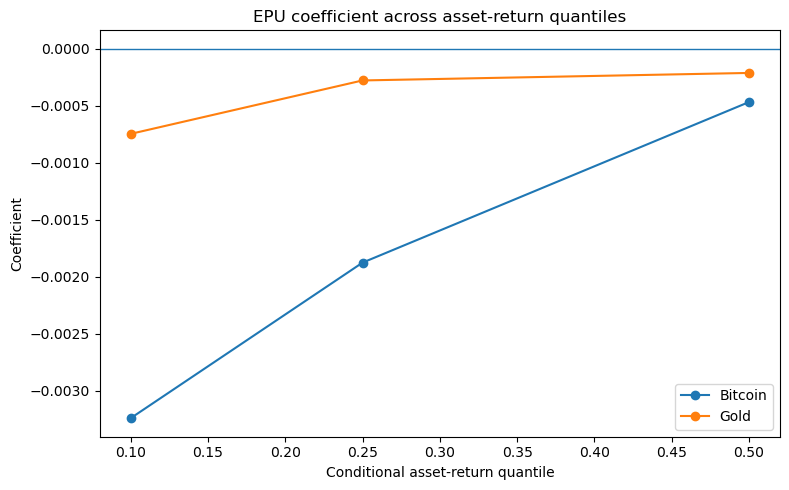

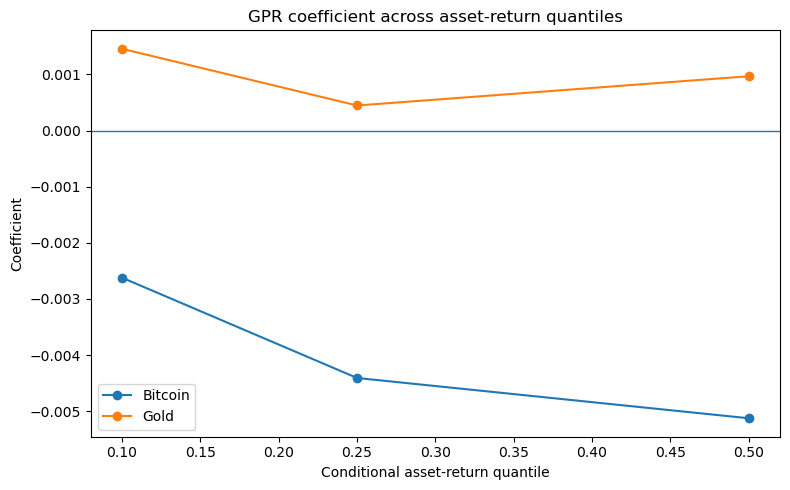

In [10]:
pillar1_quantile_models = {}
pillar1_quantile_model_data = {}
quantile_result_tables = []

for asset_name, dependent_variable in {
    "Bitcoin": "BTC_ret",
    "Gold": "Gold_ret"
}.items():
    models, result_table, model_data = run_quantile_models(
        master,
        y_var=dependent_variable,
        x_vars=PILLAR1_X_VARS,
        quantiles=QUANTILES
    )

    pillar1_quantile_models[asset_name] = models
    pillar1_quantile_model_data[asset_name] = model_data

    result_table["Asset"] = asset_name
    quantile_result_tables.append(result_table)

pillar1_quantile_results = pd.concat(
    quantile_result_tables,
    ignore_index=True
)

pillar1_quantile_report = pillar1_quantile_results[
    pillar1_quantile_results["Variable"].isin(PILLAR1_X_VARS)
][[
    "Asset",
    "Dependent Variable",
    "Quantile",
    "Variable",
    "Coefficient",
    "Robust Std Error",
    "t-statistic",
    "p-value",
    "Observations",
    "Pseudo R-squared",
    "Iterations"
]].copy()

display_report_table(
    pillar1_quantile_report,
    "Pillar 1 quantile-regression coefficients",
    decimals=6
)
#save_table(pillar1_quantile_report, "11_pillar1_quantile_coefficients.csv")

for variable, title in {
    "d_EPU_100": "EPU coefficient across asset-return quantiles",
    "d_GPR_100": "GPR coefficient across asset-return quantiles"
}.items():
    plot_data = pillar1_quantile_report[
        pillar1_quantile_report["Variable"] == variable
    ]

    plt.figure(figsize=(8, 5))

    for asset_name in plot_data["Asset"].unique():
        asset_data = plot_data[
            plot_data["Asset"] == asset_name
        ].sort_values("Quantile")

        plt.plot(
            asset_data["Quantile"],
            asset_data["Coefficient"],
            marker="o",
            label=asset_name
        )

    plt.axhline(0, linewidth=1)
    plt.title(title)
    plt.xlabel("Conditional asset-return quantile")
    plt.ylabel("Coefficient")
    plt.legend()
    plt.tight_layout()
    plt.show()


### Interpretation — quantile regression

For Bitcoin, EPU is negative at all three quantiles and significant only at the 25th quantile. GPR is significantly negative at the 25th quantile and the median, but not at the 10th quantile.

For gold, neither EPU nor GPR is significant at 5% at the reported quantiles. The positive median GPR coefficient is weakly significant at 10%. Lagged VIX is negative and significant at the 10th and 25th quantiles, linking prior market stress to weaker lower-tail gold returns.

These are pointwise results. The next test checks whether coefficients differ significantly between quantiles.


## 1.4 Formal cross-quantile comparison

The moving-block bootstrap evaluates:

$$
H_0:
\beta(q_i)-\beta(q_j)=0
$$

for different quantile pairs while preserving short-run time-series dependence.

The comparisons are:

- q10 vs q25: extreme downside versus moderate downside
- q10 vs q50: extreme downside versus normal conditions
- q25 vs q50: moderate downside versus normal conditions

In [11]:
quantile_difference_tables = []

if RUN_QR_BOOTSTRAP:

    quantile_comparisons = [
        (0.10, 0.25),
        (0.10, 0.50),
        (0.25, 0.50)
    ]

    for asset_number, (asset_name, dependent_variable) in enumerate({
        "Bitcoin": "BTC_ret",
        "Gold": "Gold_ret"
    }.items()):

        print(
            f"Running moving-block quantile bootstrap for {asset_name}..."
        )

        for comparison_number, (q_low, q_reference) in enumerate(
            quantile_comparisons
        ):

            difference_table = block_bootstrap_quantile_difference(
                model_data=pillar1_quantile_model_data[asset_name],
                y_var=dependent_variable,
                x_vars=PILLAR1_X_VARS,
                variables_to_test=("d_EPU_100", "d_GPR_100"),
                q_low=q_low,
                q_reference=q_reference,
                reps=QR_BOOTSTRAP_REPS,
                block_length=QR_BLOCK_LENGTH,
                seed=(
                    RANDOM_SEED
                    + asset_number
                    + comparison_number
                )
            )

            difference_table["Asset"] = asset_name
            difference_table["Comparison"] = (
                f"q{int(q_low*100)} vs q{int(q_reference*100)}"
            )
            difference_table["Requested repetitions"] = (
                QR_BOOTSTRAP_REPS
            )

            quantile_difference_tables.append(
                difference_table
            )


    pillar1_quantile_difference_tests = pd.concat(
        quantile_difference_tables,
        ignore_index=True
    )


    pillar1_quantile_difference_tests = (
        pillar1_quantile_difference_tests[[
            "Asset",
            "Comparison",
            "Variable",
            "Low quantile",
            "Reference quantile",
            "Observed coefficient difference",
            "Bootstrap CI 2.5%",
            "Bootstrap CI 97.5%",
            "Bootstrap p-value",
            "Successful repetitions",
            "Requested repetitions"
        ]]
    )


    display_report_table(
        pillar1_quantile_difference_tests,
        "Block-bootstrap cross-quantile coefficient difference tests",
        decimals=6
    )


# save_table(
#     pillar1_quantile_difference_tests,
#     "12_pillar1_cross_quantile_difference_bootstrap.csv"
# )

else:
    pillar1_quantile_difference_tests = pd.DataFrame()
    print(
        "Quantile bootstrap skipped because RUN_QR_BOOTSTRAP is False."
    )

Running moving-block quantile bootstrap for Bitcoin...
Running moving-block quantile bootstrap for Gold...

Block-bootstrap cross-quantile coefficient difference tests


,Asset,Comparison,Variable,Low quantile,Reference quantile,Observed coefficient difference,Bootstrap CI 2.5%,Bootstrap CI 97.5%,Bootstrap p-value,Successful repetitions,Requested repetitions
0,Bitcoin,q10 vs q25,d_EPU_100,0.10,0.25,-0.001366,-0.003692,0.001955,0.353333,300,300
1,Bitcoin,q10 vs q25,d_GPR_100,0.10,0.25,0.001786,-0.007312,0.007896,0.826667,300,300
2,Bitcoin,q10 vs q50,d_EPU_100,0.10,0.50,-0.002776,-0.004502,0.001650,0.206667,300,300
3,Bitcoin,q10 vs q50,d_GPR_100,0.10,0.50,0.002504,-0.006734,0.010150,0.693333,300,300
4,Bitcoin,q25 vs q50,d_EPU_100,0.25,0.50,-0.001410,-0.002410,0.000559,0.173333,300,300
5,Bitcoin,q25 vs q50,d_GPR_100,0.25,0.50,0.000717,-0.002550,0.005939,0.486667,300,300
6,Gold,q10 vs q25,d_EPU_100,0.10,0.25,-0.000469,-0.001190,0.000514,0.433333,300,300
7,Gold,q10 vs q25,d_GPR_100,0.10,0.25,0.001010,-0.002370,0.003169,0.640000,300,300
8,Gold,q10 vs q50,d_EPU_100,0.10,0.50,-0.000535,-0.001394,0.000639,0.420000,300,300
9,Gold,q10 vs q50,d_GPR_100,0.10,0.50,0.000489,-0.002746,0.003257,0.786667,300,300


### Interpretation — cross-quantile comparison

The moving-block bootstrap finds no significant difference between quantiles in EPU or GPR coefficients for either asset. Every confidence interval includes zero, with p-values from 0.173 to 0.953.

The quantile point estimates vary, but the data do not establish stronger EPU or GPR effects in the lower tail.


## 1.5 Pillar 1 conclusion

EPU changes are not reliably associated with average Bitcoin or gold returns. GPR has a weak negative association with Bitcoin and a positive, significant association with gold. Gold therefore responds more defensively to geopolitical risk.

Quantile estimates differ across return states, but the formal bootstrap does not confirm lower-tail amplification. The mean-model diagnostics are satisfactory, while strong ARCH effects support a separate volatility and correlation analysis in Pillar 2.


# PILLAR 2 — DYNAMIC HEDGE, SAFE-HAVEN, AND PORTFOLIO-RISK CHANNEL

## Steps

A 2% shock is large for gold but may be ordinary for Bitcoin. Raw shocks therefore cannot be compared directly.

GARCH estimates each asset's daily conditional standard deviation, $\sigma_{i,t}$, and creates a standardised shock:

$$
z_{i,t}=\frac{\varepsilon_{i,t}}{\sigma_{i,t}}.
$$

A value of $z_{i,t}=2$ means that the shock is two conditional standard deviations above the asset's expected return.

Then, DCC uses pairs of standardised shocks to estimate:

$$
\rho_{BTC,SP,t},
\qquad
\rho_{Gold,SP,t}.
$$

- Positive correlation: the assets tend to move together.
- Correlation near zero: little systematic co-movement.
- Negative correlation: the alternative asset tends to move against equities.

The uncertainty regimes label which dates are extreme. We then ask:

1. Does correlation become lower during the regime?
2. Is the correlation level inside the regime actually zero or negative?


Finally,

$$
H_t=D_tR_tD_t
$$

combines GARCH volatility with DCC correlation. This conditional covariance matrix is used to calculate portfolio weights and realised risk reduction.


## 2.1 Univariate GARCH-family volatility filters

### Purpose

Estimate each asset's changing conditional volatility and produce standardised residuals for DCC.

The preliminary diagnostics support:

- a constant conditional mean;
- Student-\(t\) innovations;

I will compare performance of GARCH(1,1), EGARCH(1,1), and GJR-GARCH(1,1), then select the most suitable modelfor each asset following this order:

1. convergence and valid parameters;
2. no remaining autocorrelation in standardised residuals;
3. no remaining squared-residual dependence or ARCH effects;
4. no remaining Engle–Ng sign/size bias;
5. lowest BIC among diagnostically adequate models.


In [12]:
# 2.1.1 — INSTALL/IMPORT THE ARCH PACKAGE

# Run the following once if arch is not installed:
# !pip install arch

try:
    from arch import arch_model
except ImportError as exc:
    raise ImportError(
        "The 'arch' package is required. Run: !pip install arch"
    ) from exc


In [13]:
# 2.1.2 — GARCH HELPER FUNCTIONS

GARCH_SCALE = 100.0
GARCH_LB_LAGS = (10, 20)
GARCH_ARCH_LAGS = 10
GARCH_DIAGNOSTIC_ALPHA = 0.05


def garch_persistence(result, specification):
    params = result.params

    alpha = float(params.get("alpha[1]", np.nan))
    beta = float(params.get("beta[1]", np.nan))
    gamma = float(params.get("gamma[1]", 0.0))

    if specification == "GARCH(1,1)-t":
        return alpha + beta, "alpha[1] + beta[1]"

    if specification == "GJR-GARCH(1,1)-t":
        return (
            alpha + beta + 0.5 * gamma,
            "alpha[1] + beta[1] + 0.5*gamma[1]"
        )

    if specification == "EGARCH(1,1)-t":
        return beta, "beta[1] in the log-variance equation"

    return np.nan, "Not defined"


def garch_parameter_validity(result, specification):
    params = result.params

    omega = float(params.get("omega", np.nan))
    alpha = float(params.get("alpha[1]", np.nan))
    beta = float(params.get("beta[1]", np.nan))
    gamma = float(params.get("gamma[1]", 0.0))
    nu = float(params.get("nu", np.nan))

    persistence, _ = garch_persistence(result, specification)

    converged = (
        getattr(result, "convergence_flag", 1) == 0
        and bool(getattr(result.optimization_result, "success", False))
    )

    common_validity = (
        converged
        and np.isfinite(result.loglikelihood)
        and np.isfinite(nu)
        and nu > 2
    )

    if specification == "GARCH(1,1)-t":
        model_specific_validity = (
            omega > 0
            and alpha >= 0
            and beta >= 0
            and persistence < 1
        )

    elif specification == "GJR-GARCH(1,1)-t":
        model_specific_validity = (
            omega > 0
            and alpha >= 0
            and beta >= 0
            and alpha + gamma >= 0
            and persistence < 1
        )

    elif specification == "EGARCH(1,1)-t":
        model_specific_validity = (
            np.isfinite(omega)
            and np.isfinite(alpha)
            and np.isfinite(beta)
            and np.isfinite(gamma)
            and abs(beta) < 1
        )

    else:
        model_specific_validity = False

    return bool(common_validity and model_specific_validity), converged


def engle_ng_joint_test(std_resid):
    # Engle-Ng-style joint sign and size-bias test.
    z = pd.Series(std_resid).dropna().astype(float)

    test_data = pd.DataFrame({
        "z2": z.pow(2),
        "z_lag": z.shift(1)
    }).dropna()

    negative = (test_data["z_lag"] < 0).astype(float)

    X = pd.DataFrame({
        "negative_sign": negative,
        "negative_size": negative * test_data["z_lag"],
        "positive_size": (1 - negative) * test_data["z_lag"]
    })

    X = sm.add_constant(X, has_constant="add")
    result = sm.OLS(test_data["z2"], X).fit()

    restriction = np.zeros((3, len(result.params)))
    parameter_positions = {
        name: position
        for position, name in enumerate(result.params.index)
    }

    for row_number, parameter_name in enumerate([
        "negative_sign",
        "negative_size",
        "positive_size"
    ]):
        restriction[row_number, parameter_positions[parameter_name]] = 1

    f_test = result.f_test(restriction)

    return {
        "Engle-Ng F statistic": float(np.asarray(f_test.fvalue).squeeze()),
        "Engle-Ng joint p-value": float(np.asarray(f_test.pvalue).squeeze())
    }


def standardised_residual_diagnostics(
    std_resid,
    lb_lags=GARCH_LB_LAGS,
    arch_lags=GARCH_ARCH_LAGS
):
    z = pd.Series(std_resid).replace([np.inf, -np.inf], np.nan).dropna()
    z = z.astype(float)

    lb_z = acorr_ljungbox(
        z,
        lags=list(lb_lags),
        return_df=True
    )

    lb_z2 = acorr_ljungbox(
        z.pow(2),
        lags=list(lb_lags),
        return_df=True
    )

    arch_stat, arch_p, arch_f, arch_f_p = het_arch(
        z,
        nlags=arch_lags
    )

    jb_stat, jb_p = jarque_bera(z)
    sign_bias = engle_ng_joint_test(z)

    diagnostics = {
        f"LB z p ({lb_lags[0]})": lb_z.loc[lb_lags[0], "lb_pvalue"],
        f"LB z p ({lb_lags[1]})": lb_z.loc[lb_lags[1], "lb_pvalue"],
        f"LB z2 p ({lb_lags[0]})": lb_z2.loc[lb_lags[0], "lb_pvalue"],
        f"LB z2 p ({lb_lags[1]})": lb_z2.loc[lb_lags[1], "lb_pvalue"],
        f"ARCH-LM p ({arch_lags})": arch_p,
        "Standardised-residual JB statistic": jb_stat,
        "Standardised-residual JB p-value": jb_p
    }

    diagnostics.update(sign_bias)
    return diagnostics


def fit_candidate_garch_models(series, asset_name):
    # Fits GARCH-t, EGARCH-t, and GJR-GARCH-t with a constant mean.
    y = (
        pd.Series(series)
        .dropna()
        .astype(float)
        * GARCH_SCALE
    )

    specifications = {
        "GARCH(1,1)-t": {
            "vol": "GARCH",
            "p": 1,
            "o": 0,
            "q": 1
        },
        "EGARCH(1,1)-t": {
            "vol": "EGARCH",
            "p": 1,
            "o": 1,
            "q": 1
        },
        "GJR-GARCH(1,1)-t": {
            "vol": "GARCH",
            "p": 1,
            "o": 1,
            "q": 1
        }
    }

    fitted_models = {}
    comparison_rows = []
    conditional_volatility = {}
    standardised_residuals = {}

    for specification, model_options in specifications.items():
        model = arch_model(
            y,
            mean="Constant",
            vol=model_options["vol"],
            p=model_options["p"],
            o=model_options["o"],
            q=model_options["q"],
            dist="t",
            rescale=False
        )

        result = model.fit(
            disp="off",
            show_warning=False,
            options={"maxiter": 2000}
        )

        fitted_models[specification] = result

        sigma = pd.Series(
            result.conditional_volatility,
            index=y.index,
            name=f"{asset_name}_{specification}_sigma"
        )

        z = pd.Series(
            result.std_resid,
            index=y.index,
            name=f"{asset_name}_{specification}_z"
        ).replace([np.inf, -np.inf], np.nan)

        conditional_volatility[specification] = sigma
        standardised_residuals[specification] = z

        validity, converged = garch_parameter_validity(
            result,
            specification
        )

        persistence, persistence_definition = garch_persistence(
            result,
            specification
        )

        diagnostics = standardised_residual_diagnostics(z)

        params = result.params
        pvalues = result.pvalues

        row = {
            "Asset": asset_name,
            "Specification": specification,
            "Observations": int(result.nobs),
            "Converged": converged,
            "Parameter-valid": validity,
            "Log likelihood": result.loglikelihood,
            "AIC": result.aic,
            "BIC": result.bic,
            "mu": params.get("mu", np.nan),
            "mu p-value": pvalues.get("mu", np.nan),
            "omega": params.get("omega", np.nan),
            "alpha[1]": params.get("alpha[1]", np.nan),
            "alpha p-value": pvalues.get("alpha[1]", np.nan),
            "gamma[1]": params.get("gamma[1]", np.nan),
            "gamma p-value": pvalues.get("gamma[1]", np.nan),
            "beta[1]": params.get("beta[1]", np.nan),
            "beta p-value": pvalues.get("beta[1]", np.nan),
            "nu": params.get("nu", np.nan),
            "nu p-value": pvalues.get("nu", np.nan),
            "Persistence": persistence,
            "Persistence definition": persistence_definition
        }

        row.update(diagnostics)
        comparison_rows.append(row)

    return (
        fitted_models,
        pd.DataFrame(comparison_rows),
        conditional_volatility,
        standardised_residuals
    )


def add_garch_diagnostic_flags(comparison_table, alpha=GARCH_DIAGNOSTIC_ALPHA):
    table = comparison_table.copy()

    table["Mean diagnostics pass"] = (
        (table["LB z p (10)"] >= alpha)
        & (table["LB z p (20)"] >= alpha)
    )

    table["Variance diagnostics pass"] = (
        (table["LB z2 p (10)"] >= alpha)
        & (table["LB z2 p (20)"] >= alpha)
        & (table["ARCH-LM p (10)"] >= alpha)
    )

    table["Asymmetry diagnostics pass"] = (
        table["Engle-Ng joint p-value"] >= alpha
    )

    table["All core diagnostics pass"] = (
        table["Parameter-valid"]
        & table["Mean diagnostics pass"]
        & table["Variance diagnostics pass"]
        & table["Asymmetry diagnostics pass"]
    )

    diagnostic_failure_columns = [
        "Mean diagnostics pass",
        "Variance diagnostics pass",
        "Asymmetry diagnostics pass"
    ]

    table["Diagnostic failure count"] = (
        len(diagnostic_failure_columns)
        - table[diagnostic_failure_columns].sum(axis=1)
    )

    return table


def select_preferred_garch_margin(asset_table):
    # Selection: validity -> diagnostics -> lowest BIC.
    valid = asset_table[
        asset_table["Parameter-valid"]
    ].copy()

    if valid.empty:
        raise RuntimeError(
            f"No valid GARCH-family model for {asset_table['Asset'].iloc[0]}."
        )

    adequate = valid[
        valid["All core diagnostics pass"]
    ].copy()

    if not adequate.empty:
        chosen = adequate.sort_values(
            ["BIC", "AIC"]
        ).iloc[0].copy()

        reason = (
            "Passed parameter-validity and all core standardised-residual "
            "diagnostics; selected by lowest BIC."
        )
    else:
        chosen = valid.sort_values(
            ["Diagnostic failure count", "BIC", "AIC"]
        ).iloc[0].copy()

        reason = (
            "No candidate passed every diagnostic; selected among valid "
            "models by the fewest diagnostic failures and then the lowest BIC. "
            "Review failed diagnostics before DCC."
        )

    chosen["Selection reason"] = reason
    return chosen


In [14]:
# 2.1.3 — FIT ALL CANDIDATE MARGINS

garch_return_series = {
    "Bitcoin": "BTC_ret",
    "Gold": "Gold_ret",
    "S&P 500": "SP500_ret"
}

garch_fitted_models = {}
garch_conditional_volatility = {}
garch_standardised_residuals = {}
garch_comparison_tables = []

for asset_name, return_variable in garch_return_series.items():
    print(f"Estimating candidate margins for {asset_name}...")

    (
        fitted_models,
        comparison_table,
        conditional_volatility,
        standardised_residuals
    ) = fit_candidate_garch_models(
        master[return_variable],
        asset_name=asset_name
    )

    garch_fitted_models[asset_name] = fitted_models
    garch_conditional_volatility[asset_name] = conditional_volatility
    garch_standardised_residuals[asset_name] = standardised_residuals
    garch_comparison_tables.append(comparison_table)

garch_model_comparison = pd.concat(
    garch_comparison_tables,
    ignore_index=True
)

garch_model_comparison = add_garch_diagnostic_flags(
    garch_model_comparison
)

display_report_table(
    garch_model_comparison,
    "Candidate GARCH-family models and diagnostics",
    decimals=6
)

# save_table(garch_model_comparison, "14_candidate_garch_model_comparison.csv")


Estimating candidate margins for Bitcoin...
Estimating candidate margins for Gold...
Estimating candidate margins for S&P 500...

Candidate GARCH-family models and diagnostics


,Asset,Specification,Observations,Converged,Parameter-valid,Log likelihood,AIC,BIC,mu,mu p-value,...,ARCH-LM p (10),Standardised-residual JB statistic,Standardised-residual JB p-value,Engle-Ng F statistic,Engle-Ng joint p-value,Mean diagnostics pass,Variance diagnostics pass,Asymmetry diagnostics pass,All core diagnostics pass,Diagnostic failure count
0,Bitcoin,"GARCH(1,1)-t",1315,True,True,-3438.836918,6887.673836,6913.581795,0.033646,0.659475,...,0.594016,905.903673,0.0,2.950175,0.031723,True,True,False,False,1
1,Bitcoin,"EGARCH(1,1)-t",1315,True,True,-3435.413861,6882.827722,6913.917274,0.033499,0.656602,...,0.459294,804.272304,0.0,2.551463,0.054189,True,True,True,True,0
2,Bitcoin,"GJR-GARCH(1,1)-t",1315,True,True,-3438.413388,6888.826776,6919.916327,0.029546,0.698601,...,0.709612,814.602750,0.0,2.146913,0.092570,True,True,True,True,0
3,Gold,"GARCH(1,1)-t",1315,True,True,-1845.059197,3700.118394,3726.026354,0.067253,0.006694,...,0.530173,301.125043,0.0,0.637498,0.590907,True,True,True,True,0
4,Gold,"EGARCH(1,1)-t",1315,True,True,-1841.797199,3695.594399,3726.683951,0.074964,0.002162,...,0.168283,177.373867,0.0,0.761120,0.515931,True,True,True,True,0
5,Gold,"GJR-GARCH(1,1)-t",1315,True,True,-1839.750828,3691.501657,3722.591208,0.075051,0.002588,...,0.522761,162.180830,0.0,0.592824,0.619746,True,True,True,True,0
6,S&P 500,"GARCH(1,1)-t",1315,True,True,-1766.515994,3543.031988,3568.939948,0.099530,0.000005,...,0.666481,225.584432,0.0,3.569986,0.013648,True,True,False,False,1
7,S&P 500,"EGARCH(1,1)-t",1315,True,True,-1726.898084,3465.796169,3496.885720,0.063015,0.003602,...,0.855983,215.155569,0.0,0.898848,0.441112,True,True,True,True,0
8,S&P 500,"GJR-GARCH(1,1)-t",1315,True,True,-1739.177603,3490.355207,3521.444758,0.067917,0.002422,...,0.454867,207.193297,0.0,2.961872,0.031226,True,True,False,False,1


### Model-selection rule

A model is eligible for selection only after it passes the residual diagnostics. Jarque–Bera rejection is reported but this is normal as financial returns can remain extremely heavy-tailed even under Student-$t$ innovations.


In [15]:
selected_garch_rows = []

for asset_name in garch_return_series:
    asset_table = garch_model_comparison[
        garch_model_comparison["Asset"] == asset_name
    ].copy()

    selected_garch_rows.append(
        select_preferred_garch_margin(asset_table)
    )

selected_garch_margins = pd.DataFrame(selected_garch_rows)

selected_garch_margins = selected_garch_margins[[
    "Asset",
    "Specification",
    "Converged",
    "Parameter-valid",
    "All core diagnostics pass",
    "Diagnostic failure count",
    "AIC",
    "BIC",
    "Persistence",
    "Persistence definition",
    "gamma[1]",
    "gamma p-value",
    "LB z p (10)",
    "LB z p (20)",
    "LB z2 p (10)",
    "LB z2 p (20)",
    "ARCH-LM p (10)",
    "Engle-Ng joint p-value"
]].reset_index(drop=True)

display_report_table(
    selected_garch_margins,
    "Selected GARCH-family margin for each asset",
    decimals=6
)

#save_table(selected_garch_margins, "15_selected_garch_margins.csv")



Selected GARCH-family margin for each asset


,Asset,Specification,Converged,Parameter-valid,All core diagnostics pass,Diagnostic failure count,AIC,BIC,Persistence,Persistence definition,gamma[1],gamma p-value,LB z p (10),LB z p (20),LB z2 p (10),LB z2 p (20),ARCH-LM p (10),Engle-Ng joint p-value
0,Bitcoin,"EGARCH(1,1)-t",True,True,True,0,6882.827722,6913.917274,0.987702,beta[1] in the log-variance equation,-0.015633,0.439043,0.627546,0.708765,0.434858,0.621649,0.459294,0.054189
1,Gold,"GJR-GARCH(1,1)-t",True,True,True,0,3691.501657,3722.591208,0.982061,alpha[1] + beta[1] + 0.5*gamma[1],-0.067086,0.005792,0.741791,0.873286,0.581631,0.855540,0.522761,0.619746
2,S&P 500,"EGARCH(1,1)-t",True,True,True,0,3465.796169,3496.885720,0.972843,beta[1] in the log-variance equation,-0.190925,0.000000,0.726975,0.416380,0.857199,0.966994,0.855983,0.441112


### Interpretation — selected GARCH-family margins

All nine candidates converge and satisfy their parameter restrictions. The final model for each asset is chosen from the candidates that also pass the residual diagnostics.

- **Bitcoin:** EGARCH(1,1)-t is selected. Persistence is high \(0.9877\). The asymmetry coefficient is not significant, but the model removes the remaining sign and size bias at the 5% level. Its Engle–Ng p-value of 0.054 is a narrow pass.
- **Gold:** GJR-GARCH(1,1)-t is selected. Persistence is \(0.9821\). The negative and significant asymmetry coefficient means that, in this specification, negative shocks raise volatility less than equal-sized positive shocks.
- **S&P 500:** EGARCH(1,1)-t is selected. Persistence is \(0.9728\). The asymmetry coefficient is negative and significant, consistent with the usual equity leverage effect.

Jarque–Bera still rejects normality for all selected standardised residuals. Some tail risk therefore remains, but the mean, variance, ARCH, and Engle–Ng diagnostics are satisfactory.


In [16]:
# 2.1.5 — STORE SELECTED DAILY VOLATILITY AND STANDARDISED RESIDUALS

selected_conditional_volatility = pd.DataFrame(index=master.index)
selected_standardised_residuals = pd.DataFrame(index=master.index)

for _, row in selected_garch_margins.iterrows():
    asset_name = row["Asset"]
    specification = row["Specification"]

    selected_conditional_volatility[asset_name] = (
        garch_conditional_volatility[asset_name][specification]
        / GARCH_SCALE
    )

    selected_standardised_residuals[asset_name] = (
        garch_standardised_residuals[asset_name][specification]
    )

selected_conditional_volatility = (
    selected_conditional_volatility.dropna(how="all")
)

selected_standardised_residuals = (
    selected_standardised_residuals.dropna(how="all")
)

display_report_table(
    selected_conditional_volatility.describe().T.reset_index().rename(
        columns={"index": "Asset"}
    ),
    "Selected daily conditional-volatility series summary",
    decimals=6
)

display_report_table(
    selected_standardised_residuals.describe().T.reset_index().rename(
        columns={"index": "Asset"}
    ),
    "Selected standardised-residual series summary",
    decimals=6
)

if SAVE_OUTPUTS:
    selected_conditional_volatility.to_csv(
        OUTPUT_DIR / "16_selected_daily_conditional_volatility.csv"
    )
    selected_standardised_residuals.to_csv(
        OUTPUT_DIR / "17_selected_standardised_residuals.csv"
    )



Selected daily conditional-volatility series summary


,Asset,count,mean,std,min,25%,50%,75%,max
0,Bitcoin,1315.0,0.037113,0.009475,0.021182,0.030748,0.035628,0.041856,0.072926
1,Gold,1315.0,0.010392,0.003229,0.006567,0.008646,0.009584,0.010832,0.031597
2,S&P 500,1315.0,0.009814,0.003957,0.003623,0.006956,0.008802,0.011660,0.028738



Selected standardised-residual series summary


,Asset,count,mean,std,min,25%,50%,75%,max
0,Bitcoin,1315.0,0.005408,0.979922,-5.832518,-0.507047,-0.003021,0.537171,5.413624
1,Gold,1315.0,-0.011236,0.997026,-5.545102,-0.552982,-0.008890,0.572450,3.669601
2,S&P 500,1315.0,-0.037819,1.002954,-4.998980,-0.615773,0.016450,0.634795,3.498277


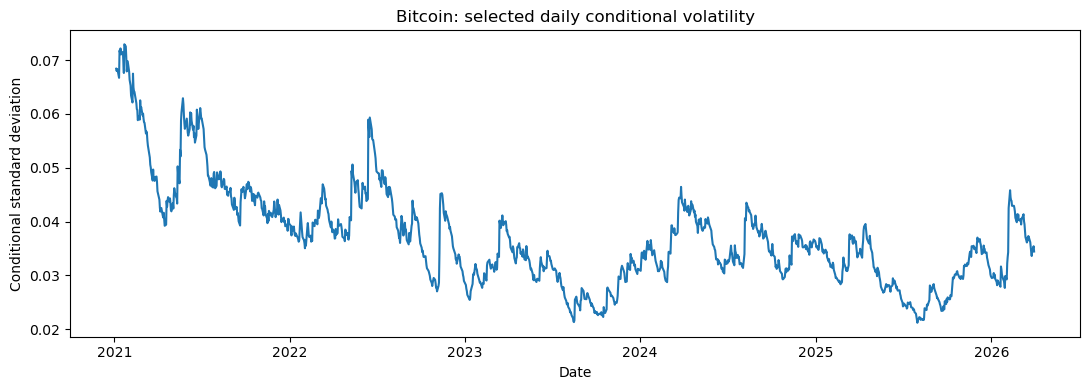

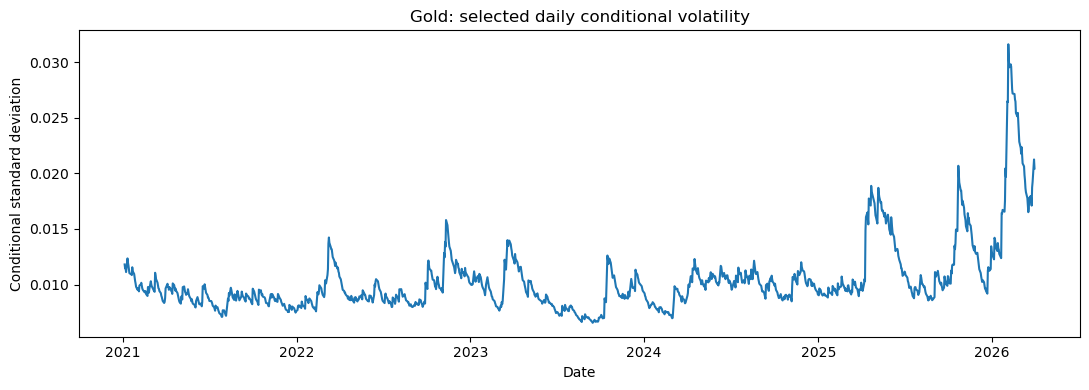

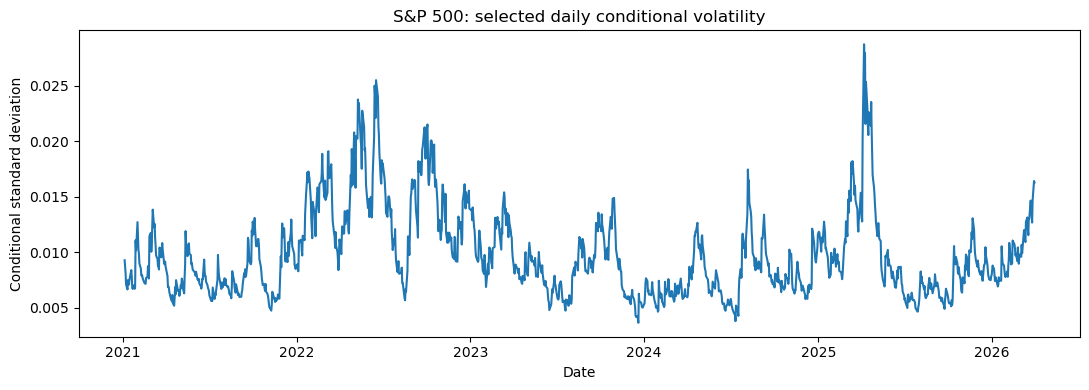

In [17]:
# 2.1.6 — PLOT SELECTED DAILY CONDITIONAL VOLATILITY

for asset_name in selected_conditional_volatility.columns:
    plt.figure(figsize=(11, 4))
    plt.plot(
        selected_conditional_volatility.index,
        selected_conditional_volatility[asset_name]
    )
    plt.title(
        f"{asset_name}: selected daily conditional volatility"
    )
    plt.xlabel("Date")
    plt.ylabel("Conditional standard deviation")
    plt.tight_layout()
    plt.show()


### GARCH conclusion and DCC readiness

The selected filters leave no significant autocorrelation, squared-residual dependence, ARCH effects, or Engle–Ng bias at the 5% level. All persistence measures are below one, so volatility is highly persistent but mean-reverting.

The standardised residuals are therefore suitable for DCC. Bitcoin's Engle–Ng p-value of 0.054 is close to the 5% threshold and should be treated as a narrow pass.


## 2.2 Extreme-condition definitions

### Purpose

Label the dates on which uncertainty or market stress is unusually high.

Primary regimes:

- HighEPU: top 20% of EPU levels;
- HighGPR: top 20% of GPR levels.

Supporting regimes:

- HighVIX: top 20% of VIX levels;
- SP500_Downside: bottom 10% of S&P 500 returns.

Top-10% EPU and GPR will be defined here but are retained for threshold sensitivity later in robustness section.


In [18]:
# 2.2.1 — CONSTRUCT AND SUMMARISE REGIMES

PRIMARY_REGIMES = ["HighEPU", "HighGPR"]
SUPPORTING_REGIMES = ["HighVIX", "SP500_Downside"]
ALL_DCC_REGIMES = PRIMARY_REGIMES + SUPPORTING_REGIMES

# Recalculate on the final common sample so every threshold uses the same observations.
master["HighEPU"] = (
    master["EPU_level"]
    >= master["EPU_level"].quantile(0.80)
).astype(int)

master["HighGPR"] = (
    master["GPR_level"]
    >= master["GPR_level"].quantile(0.80)
).astype(int)

master["HighVIX"] = (
    master["VIX_level"]
    >= master["VIX_level"].quantile(0.80)
).astype(int)

master["SP500_Downside"] = (
    master["SP500_ret"]
    <= master["SP500_ret"].quantile(0.10)
).astype(int)

# Stricter uncertainty thresholds for sensitivity analysis.
master["HighEPU90"] = (
    master["EPU_level"]
    >= master["EPU_level"].quantile(0.90)
).astype(int)

master["HighGPR90"] = (
    master["GPR_level"]
    >= master["GPR_level"].quantile(0.90)
).astype(int)

regime_definition_rows = [
    {
        "Regime": "HighEPU",
        "Role": "Primary",
        "Source variable": "EPU level",
        "Tail rule": "Top 20%",
        "Threshold": master["EPU_level"].quantile(0.80),
        "Observations": int(master["HighEPU"].sum()),
        "Sample share": master["HighEPU"].mean()
    },
    {
        "Regime": "HighGPR",
        "Role": "Primary",
        "Source variable": "GPR level",
        "Tail rule": "Top 20%",
        "Threshold": master["GPR_level"].quantile(0.80),
        "Observations": int(master["HighGPR"].sum()),
        "Sample share": master["HighGPR"].mean()
    },
    {
        "Regime": "HighVIX",
        "Role": "Supporting",
        "Source variable": "VIX level",
        "Tail rule": "Top 20%",
        "Threshold": master["VIX_level"].quantile(0.80),
        "Observations": int(master["HighVIX"].sum()),
        "Sample share": master["HighVIX"].mean()
    },
    {
        "Regime": "SP500_Downside",
        "Role": "Supporting",
        "Source variable": "S&P 500 return",
        "Tail rule": "Bottom 10%",
        "Threshold": master["SP500_ret"].quantile(0.10),
        "Observations": int(master["SP500_Downside"].sum()),
        "Sample share": master["SP500_Downside"].mean()
    },
    {
        "Regime": "HighEPU90",
        "Role": "Sensitivity",
        "Source variable": "EPU level",
        "Tail rule": "Top 10%",
        "Threshold": master["EPU_level"].quantile(0.90),
        "Observations": int(master["HighEPU90"].sum()),
        "Sample share": master["HighEPU90"].mean()
    },
    {
        "Regime": "HighGPR90",
        "Role": "Sensitivity",
        "Source variable": "GPR level",
        "Tail rule": "Top 10%",
        "Threshold": master["GPR_level"].quantile(0.90),
        "Observations": int(master["HighGPR90"].sum()),
        "Sample share": master["HighGPR90"].mean()
    }
]

regime_definition_table = pd.DataFrame(regime_definition_rows)

display_report_table(
    regime_definition_table,
    "Extreme-condition definitions",
    decimals=6
)

regime_overlap_table = pd.crosstab(
    master["HighEPU"],
    master["HighGPR"],
    rownames=["HighEPU"],
    colnames=["HighGPR"]
)

print("\nOverlap between the two principal uncertainty regimes")
display(regime_overlap_table)

# save_table(regime_definition_table, "18_regime_definitions.csv")



Extreme-condition definitions


,Regime,Role,Source variable,Tail rule,Threshold,Observations,Sample share
0,HighEPU,Primary,EPU level,Top 20%,273.868000,263,0.20000
1,HighGPR,Primary,GPR level,Top 20%,183.378000,263,0.20000
2,HighVIX,Supporting,VIX level,Top 20%,23.240000,264,0.20076
3,SP500_Downside,Supporting,S&P 500 return,Bottom 10%,-0.011854,132,0.10038
4,HighEPU90,Sensitivity,EPU level,Top 10%,376.588000,132,0.10038
5,HighGPR90,Sensitivity,GPR level,Top 10%,218.786000,132,0.10038



Overlap between the two principal uncertainty regimes


HighGPR,0,1
HighEPU,,
0,880,172
1,172,91


### Interpretation — regime construction

HighEPU and HighGPR each contain 263 days. They overlap on 91 days, while each also has 172 unique observations. This provides enough separate variation to study the two uncertainty sources.

The main thresholds are 273.87 for EPU and 183.38 for GPR. Top-10% regimes contain 132 observations each and are used only as sensitivity checks.


## 2.3 Dynamic conditional correlation

For each asset–equity pair, the selected univariate GARCH-family models provide conditional standard deviations and standardised shocks. The DCC recursion is

$$
Q_t
=
(1-a-b)\bar Q
+a z_{t-1}z_{t-1}'
+bQ_{t-1},
\qquad
a\geq0,\ b\geq0,\ a+b<1,
$$

and the conditional-correlation matrix is

$$
R_t
=
\operatorname{diag}(Q_t)^{-1/2}
Q_t
\operatorname{diag}(Q_t)^{-1/2}.
$$

The complete conditional covariance matrix is then

$$
H_t=D_tR_tD_t,
$$

where $D_t$ contains the selected conditional standard deviations. DCC produces one conditional correlation for every trading day, not one correlation for the entire sample.


In [19]:
# 2.3.1 — DCC SETTINGS AND HELPER FUNCTIONS

from scipy.optimize import minimize
from scipy.stats import chi2, norm

DCC_START_VALUES = [
    (0.02, 0.95),
    (0.05, 0.90),
    (0.01, 0.97),
    (0.10, 0.80)
]

DCC_HAC_LAGS = 5
DCC_BOOTSTRAP_REPS = 1000
DCC_BLOCK_LENGTH = 10
DCC_RANDOM_SEED = 20260725
RUN_DCC_BOOTSTRAP = True

DCC_PAIRS = {
    "BTC_SP500": ("Bitcoin", "S&P 500"),
    "Gold_SP500": ("Gold", "S&P 500")
}


def dcc_ab_to_theta(a, b):
    remainder = 1.0 - a - b
    if a <= 0 or b <= 0 or remainder <= 0:
        raise ValueError("DCC start values must satisfy a>0, b>0 and a+b<1.")
    return np.array([
        np.log(a / remainder),
        np.log(b / remainder)
    ])


def dcc_theta_to_ab(theta):
    # Stable three-category softmax: categories are remainder, a and b.
    u, v = np.asarray(theta, dtype=float)
    maximum = max(0.0, u, v)

    e0 = np.exp(-maximum)
    e1 = np.exp(u - maximum)
    e2 = np.exp(v - maximum)
    denominator = e0 + e1 + e2

    a = e1 / denominator
    b = e2 / denominator
    return float(a), float(b)


def dcc_filter(z_values, a, b, q_bar=None):
    z_values = np.asarray(z_values, dtype=float)

    if z_values.ndim != 2 or z_values.shape[1] != 2:
        raise ValueError("This implementation expects a bivariate residual matrix.")

    if q_bar is None:
        q_bar = np.corrcoef(z_values.T)

    q_bar = np.asarray(q_bar, dtype=float)
    q_t = q_bar.copy()

    n_obs = z_values.shape[0]
    correlations = np.empty(n_obs)
    r_matrices = np.empty((n_obs, 2, 2))
    whitened = np.empty_like(z_values)
    log_likelihood = 0.0
    minimum_eigenvalue = np.inf

    for t in range(n_obs):
        if t > 0:
            previous_outer_product = np.outer(
                z_values[t - 1],
                z_values[t - 1]
            )

            q_t = (
                (1.0 - a - b) * q_bar
                + a * previous_outer_product
                + b * q_t
            )

        diagonal = np.sqrt(np.clip(np.diag(q_t), 1e-12, None))
        r_t = q_t / np.outer(diagonal, diagonal)
        r_t = (r_t + r_t.T) / 2.0
        np.fill_diagonal(r_t, 1.0)

        eigenvalues = np.linalg.eigvalsh(r_t)
        minimum_eigenvalue = min(
            minimum_eigenvalue,
            float(eigenvalues.min())
        )

        sign, log_determinant = np.linalg.slogdet(r_t)

        if sign <= 0 or not np.isfinite(log_determinant):
            raise FloatingPointError(
                "DCC recursion produced a non-positive-definite correlation matrix."
            )

        quadratic = z_values[t] @ np.linalg.solve(r_t, z_values[t])
        independent_quadratic = z_values[t] @ z_values[t]

        log_likelihood += -0.5 * (
            log_determinant
            + quadratic
            - independent_quadratic
        )

        correlations[t] = r_t[0, 1]
        r_matrices[t] = r_t

        cholesky = np.linalg.cholesky(r_t)
        whitened[t] = np.linalg.solve(cholesky, z_values[t])

    return {
        "log_likelihood": float(log_likelihood),
        "correlations": correlations,
        "r_matrices": r_matrices,
        "whitened": whitened,
        "minimum_eigenvalue": float(minimum_eigenvalue)
    }


def dcc_negative_log_likelihood(theta, z_values, q_bar):
    try:
        a, b = dcc_theta_to_ab(theta)
        result = dcc_filter(z_values, a, b, q_bar=q_bar)

        if not np.isfinite(result["log_likelihood"]):
            return 1e12

        return -result["log_likelihood"]
    except Exception:
        return 1e12


def ccc_correlation_log_likelihood(z_values, constant_correlation):
    r_t = np.array([
        [1.0, constant_correlation],
        [constant_correlation, 1.0]
    ])

    sign, log_determinant = np.linalg.slogdet(r_t)

    if sign <= 0:
        return np.nan

    inverse_r = np.linalg.inv(r_t)
    log_likelihood = 0.0

    for z_t in np.asarray(z_values):
        quadratic = z_t @ inverse_r @ z_t
        independent_quadratic = z_t @ z_t

        log_likelihood += -0.5 * (
            log_determinant
            + quadratic
            - independent_quadratic
        )

    return float(log_likelihood)


def numerical_hessian(function, point, step=1e-4):
    point = np.asarray(point, dtype=float)
    dimension = len(point)
    hessian = np.zeros((dimension, dimension))
    f0 = function(point)

    for i in range(dimension):
        ei = np.zeros(dimension)
        ei[i] = step

        hessian[i, i] = (
            function(point + ei)
            - 2.0 * f0
            + function(point - ei)
        ) / (step ** 2)

        for j in range(i + 1, dimension):
            ej = np.zeros(dimension)
            ej[j] = step

            cross = (
                function(point + ei + ej)
                - function(point + ei - ej)
                - function(point - ei + ej)
                + function(point - ei - ej)
            ) / (4.0 * step ** 2)

            hessian[i, j] = cross
            hessian[j, i] = cross

    return hessian


def dcc_parameter_standard_errors(theta_hat, objective_function):
    try:
        hessian = numerical_hessian(
            objective_function,
            theta_hat,
            step=1e-4
        )
        covariance_theta = np.linalg.inv(hessian)

        a, b = dcc_theta_to_ab(theta_hat)
        jacobian = np.array([
            [a * (1.0 - a), -a * b],
            [-a * b, b * (1.0 - b)]
        ])

        covariance_ab = (
            jacobian
            @ covariance_theta
            @ jacobian.T
        )

        standard_errors = np.sqrt(
            np.clip(np.diag(covariance_ab), 0.0, None)
        )

        if not np.all(np.isfinite(standard_errors)):
            return np.nan, np.nan

        return float(standard_errors[0]), float(standard_errors[1])
    except Exception:
        return np.nan, np.nan


def fit_dcc_pair(residual_frame, pair_name):
    pair_data = (
        residual_frame
        .replace([np.inf, -np.inf], np.nan)
        .dropna()
        .astype(float)
        .copy()
    )

    # Small recentering/rescaling removes numerical deviations from mean zero
    # and unit variance while preserving the GARCH-filtered shock information.
    pair_data = (
        pair_data - pair_data.mean()
    ) / pair_data.std(ddof=0)

    z_values = pair_data.to_numpy()
    q_bar = np.corrcoef(z_values.T)

    optimisation_records = []

    for a_start, b_start in DCC_START_VALUES:
        theta_start = dcc_ab_to_theta(a_start, b_start)

        optimisation = minimize(
            dcc_negative_log_likelihood,
            x0=theta_start,
            args=(z_values, q_bar),
            method="L-BFGS-B",
            bounds=[(-12, 12), (-12, 12)],
            options={
                "maxiter": 3000,
                "ftol": 1e-12,
                "gtol": 1e-8
            }
        )

        a_estimate, b_estimate = dcc_theta_to_ab(
            optimisation.x
        )

        optimisation_records.append({
            "Start a": a_start,
            "Start b": b_start,
            "Success": bool(optimisation.success),
            "Objective": float(optimisation.fun),
            "Estimated a": a_estimate,
            "Estimated b": b_estimate,
            "Message": str(optimisation.message),
            "Result object": optimisation
        })

    successful = [
        record
        for record in optimisation_records
        if record["Success"] and np.isfinite(record["Objective"])
    ]

    candidate_records = (
        successful
        if successful
        else [
            record
            for record in optimisation_records
            if np.isfinite(record["Objective"])
        ]
    )

    if not candidate_records:
        raise RuntimeError(f"All DCC optimisations failed for {pair_name}.")

    best_record = min(
        candidate_records,
        key=lambda record: record["Objective"]
    )

    best_result = best_record["Result object"]
    a_estimate, b_estimate = dcc_theta_to_ab(best_result.x)

    filtered = dcc_filter(
        z_values,
        a_estimate,
        b_estimate,
        q_bar=q_bar
    )

    objective_function = lambda theta: dcc_negative_log_likelihood(
        theta,
        z_values,
        q_bar
    )

    se_a, se_b = dcc_parameter_standard_errors(
        best_result.x,
        objective_function
    )

    p_a = (
        2.0 * norm.sf(abs(a_estimate / se_a))
        if np.isfinite(se_a) and se_a > 0
        else np.nan
    )

    p_b = (
        2.0 * norm.sf(abs(b_estimate / se_b))
        if np.isfinite(se_b) and se_b > 0
        else np.nan
    )

    constant_correlation = float(q_bar[0, 1])
    ccc_log_likelihood = ccc_correlation_log_likelihood(
        z_values,
        constant_correlation
    )

    likelihood_ratio = max(
        0.0,
        2.0 * (
            filtered["log_likelihood"]
            - ccc_log_likelihood
        )
    )

    likelihood_ratio_p = chi2.sf(
        likelihood_ratio,
        df=2
    )

    correlation_series = pd.Series(
        filtered["correlations"],
        index=pair_data.index,
        name=pair_name
    )

    whitened_frame = pd.DataFrame(
        filtered["whitened"],
        index=pair_data.index,
        columns=[
            f"{pair_data.columns[0]}_whitened",
            f"{pair_data.columns[1]}_whitened"
        ]
    )

    whitened_cross_product = (
        whitened_frame.iloc[:, 0]
        * whitened_frame.iloc[:, 1]
    )

    lb_cross = acorr_ljungbox(
        whitened_cross_product,
        lags=[10, 20],
        return_df=True
    )

    finite_objectives = [
        record["Objective"]
        for record in optimisation_records
        if np.isfinite(record["Objective"])
    ]

    summary = {
        "Pair": pair_name,
        "Observations": len(pair_data),
        "Converged": bool(best_result.success),
        "DCC a": a_estimate,
        "DCC a Std Error": se_a,
        "DCC a p-value": p_a,
        "DCC b": b_estimate,
        "DCC b Std Error": se_b,
        "DCC b p-value": p_b,
        "DCC a + b": a_estimate + b_estimate,
        "DCC log likelihood": filtered["log_likelihood"],
        "CCC log likelihood": ccc_log_likelihood,
        "Approx. DCC-versus-CCC LR": likelihood_ratio,
        "Approx. LR p-value": likelihood_ratio_p,
        "Average correlation": correlation_series.mean(),
        "Median correlation": correlation_series.median(),
        "Minimum correlation": correlation_series.min(),
        "Maximum correlation": correlation_series.max(),
        "Share negative": (correlation_series < 0).mean(),
        "Minimum R eigenvalue": filtered["minimum_eigenvalue"],
        "Whitened residual correlation":
            whitened_frame.corr().iloc[0, 1],
        "LB whitened cross-product p (10)":
            lb_cross.loc[10, "lb_pvalue"],
        "LB whitened cross-product p (20)":
            lb_cross.loc[20, "lb_pvalue"],
        "Successful starts": sum(
            record["Success"]
            for record in optimisation_records
        ),
        "Objective range across starts": (
            max(finite_objectives) - min(finite_objectives)
            if finite_objectives
            else np.nan
        )
    }

    clean_optimisation_records = pd.DataFrame([
        {
            key: value
            for key, value in record.items()
            if key != "Result object"
        }
        for record in optimisation_records
    ])

    return (
        summary,
        correlation_series,
        whitened_frame,
        clean_optimisation_records
    )


def shade_binary_regime(axis, indicator):
    indicator = pd.Series(indicator).fillna(0).astype(int)
    active = indicator[indicator == 1]

    if active.empty:
        return

    active_dates = active.index
    start_date = active_dates[0]
    previous_date = active_dates[0]

    for current_date in active_dates[1:]:
        if (current_date - previous_date).days > 4:
            axis.axvspan(
                start_date,
                previous_date,
                alpha=0.12
            )
            start_date = current_date

        previous_date = current_date

    axis.axvspan(
        start_date,
        previous_date,
        alpha=0.12
    )


In [20]:
# 2.3.2 — ESTIMATE SELECTED-MARGIN DCC MODELS

selected_dcc_summaries = []
selected_dcc_correlations = {}
selected_dcc_whitened_residuals = {}
selected_dcc_optimisation_checks = {}

for pair_name, (first_asset, second_asset) in DCC_PAIRS.items():
    print(f"Estimating selected-margin DCC for {pair_name}...")

    residual_pair = selected_standardised_residuals[
        [first_asset, second_asset]
    ].dropna()

    (
        pair_summary,
        correlation_series,
        whitened_frame,
        optimisation_checks
    ) = fit_dcc_pair(
        residual_pair,
        pair_name=pair_name
    )

    selected_dcc_summaries.append(pair_summary)
    selected_dcc_correlations[pair_name] = correlation_series
    selected_dcc_whitened_residuals[pair_name] = whitened_frame
    selected_dcc_optimisation_checks[pair_name] = optimisation_checks

selected_dcc_summary = pd.DataFrame(selected_dcc_summaries)

selected_dcc_correlation_frame = pd.DataFrame(
    selected_dcc_correlations
)

display_report_table(
    selected_dcc_summary,
    "Selected-margin DCC estimates and diagnostics",
    decimals=6
)

for pair_name, optimisation_table in (
    selected_dcc_optimisation_checks.items()
):
    display_report_table(
        optimisation_table,
        f"{pair_name}: DCC starting-value stability",
        decimals=8
    )

save_table(
    selected_dcc_summary,
    "19_selected_margin_dcc_summary.csv"
)

Estimating selected-margin DCC for BTC_SP500...
Estimating selected-margin DCC for Gold_SP500...

Selected-margin DCC estimates and diagnostics


,Pair,Observations,Converged,DCC a,DCC a Std Error,DCC a p-value,DCC b,DCC b Std Error,DCC b p-value,DCC a + b,...,Median correlation,Minimum correlation,Maximum correlation,Share negative,Minimum R eigenvalue,Whitened residual correlation,LB whitened cross-product p (10),LB whitened cross-product p (20),Successful starts,Objective range across starts
0,BTC_SP500,1315,True,0.020674,0.007899,0.008865,0.968202,0.013730,0.0,0.988876,...,0.357860,0.019877,0.586877,0.000000,0.413123,0.004572,0.309072,0.699026,4,0.000000
1,Gold_SP500,1315,True,0.026889,0.007869,0.000633,0.951145,0.013923,0.0,0.978034,...,0.170264,-0.228998,0.430454,0.136882,0.569546,0.000567,0.718606,0.899148,4,10.524288



BTC_SP500: DCC starting-value stability


,Start a,Start b,Success,Objective,Estimated a,Estimated b,Message
0,0.02,0.95,True,-102.235856,0.020674,0.968202,CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*...
1,0.05,0.90,True,-102.235856,0.020674,0.968202,CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*...
2,0.01,0.97,True,-102.235856,0.020675,0.968202,CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*...
3,0.10,0.80,True,-102.235856,0.020674,0.968202,CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*...



Gold_SP500: DCC starting-value stability


,Start a,Start b,Success,Objective,Estimated a,Estimated b,Message
0,0.02,0.95,True,-27.734211,0.026889,0.951145,CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*...
1,0.05,0.90,True,-27.734211,0.026889,0.951145,CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*...
2,0.01,0.97,True,-27.734211,0.026889,0.951145,CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*...
3,0.10,0.80,True,-17.209923,0.000000,0.999994,CONVERGENCE: NORM OF PROJECTED GRADIENT <= PGTOL


,Pair,Observations,Converged,DCC a,DCC a Std Error,DCC a p-value,DCC b,DCC b Std Error,DCC b p-value,DCC a + b,...,Median correlation,Minimum correlation,Maximum correlation,Share negative,Minimum R eigenvalue,Whitened residual correlation,LB whitened cross-product p (10),LB whitened cross-product p (20),Successful starts,Objective range across starts
0,BTC_SP500,1315,True,0.020674,0.007899,0.008865,0.968202,0.013730,0.0,0.988876,...,0.357860,0.019877,0.586877,0.000000,0.413123,0.004572,0.309072,0.699026,4,2.188898e-10
1,Gold_SP500,1315,True,0.026889,0.007869,0.000633,0.951145,0.013923,0.0,0.978034,...,0.170264,-0.228998,0.430454,0.136882,0.569546,0.000567,0.718606,0.899148,4,1.052429e+01


### Interpretation — selected-margin DCC estimates

Both DCC models converge, satisfy \(a+b<1\), and pass the correlation-matrix and whitened cross-product checks.

Bitcoin–S&P 500 has \(a=0.0207\), \(b=0.9682\), and persistence of 0.9889. Its mean DCC is 0.352 and is positive on every day. Bitcoin is therefore an equity-linked diversifier, not an average hedge.

Gold–S&P 500 has \(a=0.0269\), \(b=0.9511\), and persistence of 0.9780. Its mean DCC is much lower at 0.158, and correlation is negative on 13.7% of days. The full-sample mean remains significantly positive, so gold offers stronger diversification but is not an average hedge under the strict definition.

All Bitcoin starts reach the same solution. For gold, three starts reach the preferred interior solution and one reaches an inferior boundary solution. Robustness section later will check gold's global-optimisation.


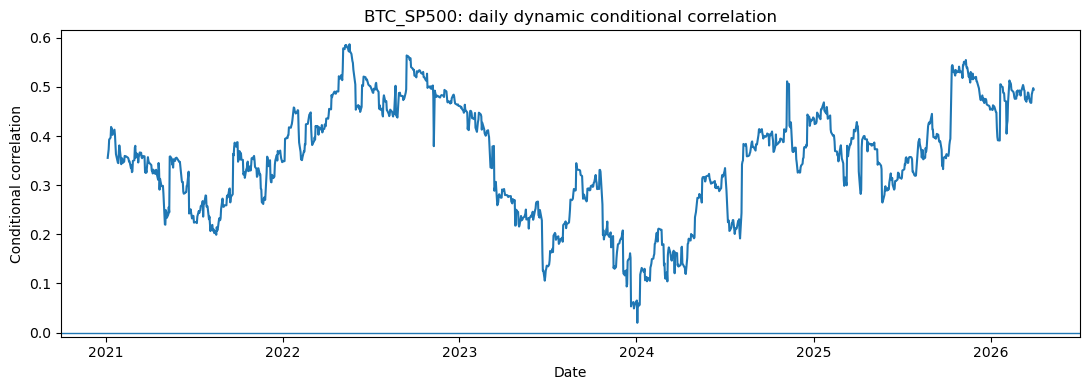

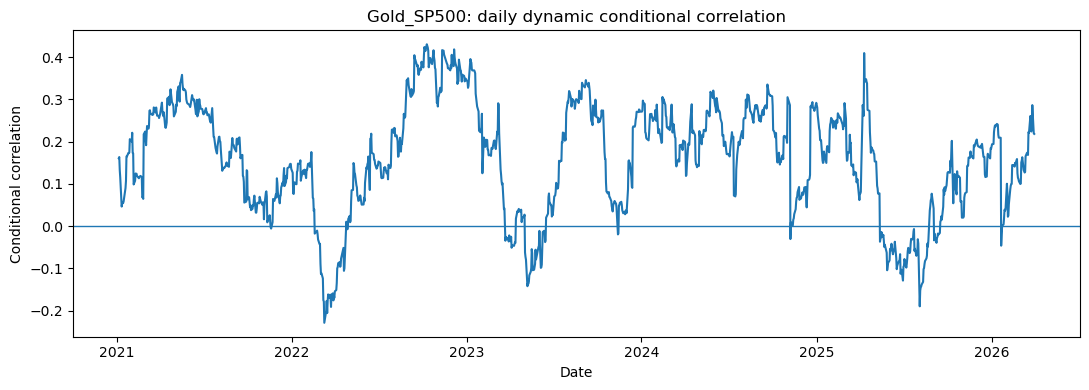

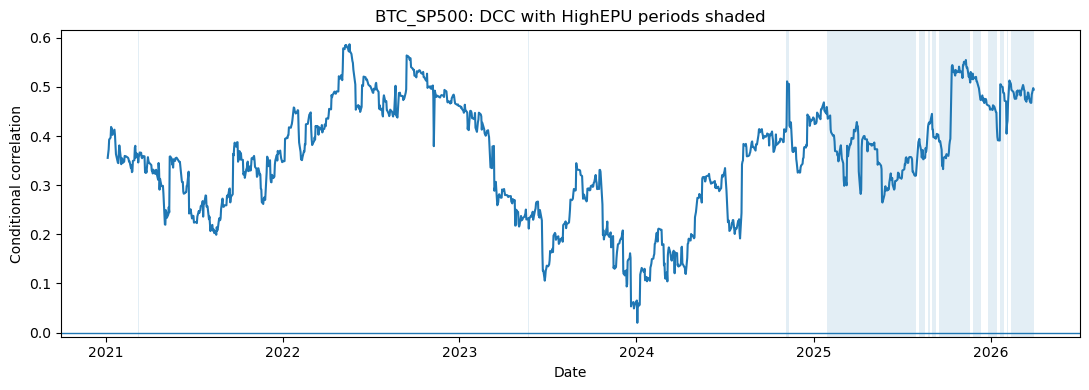

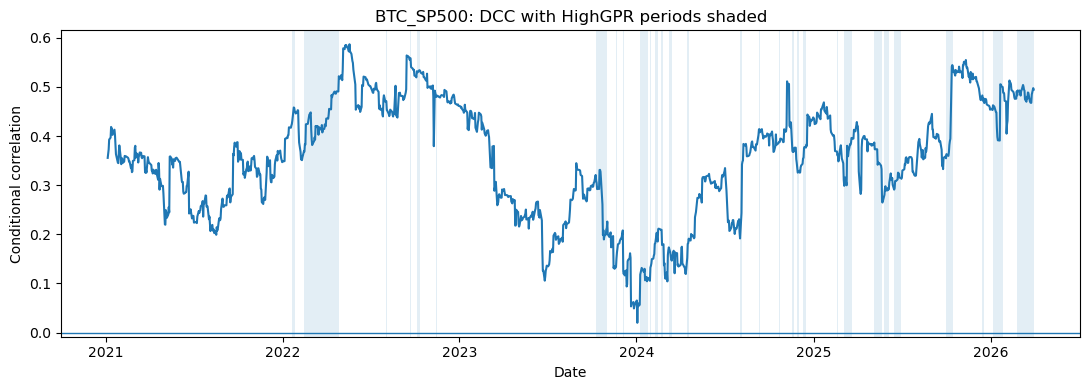

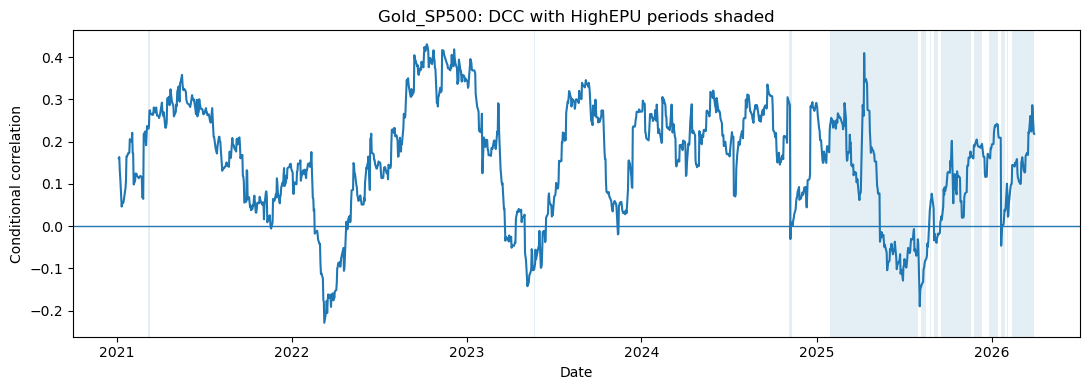

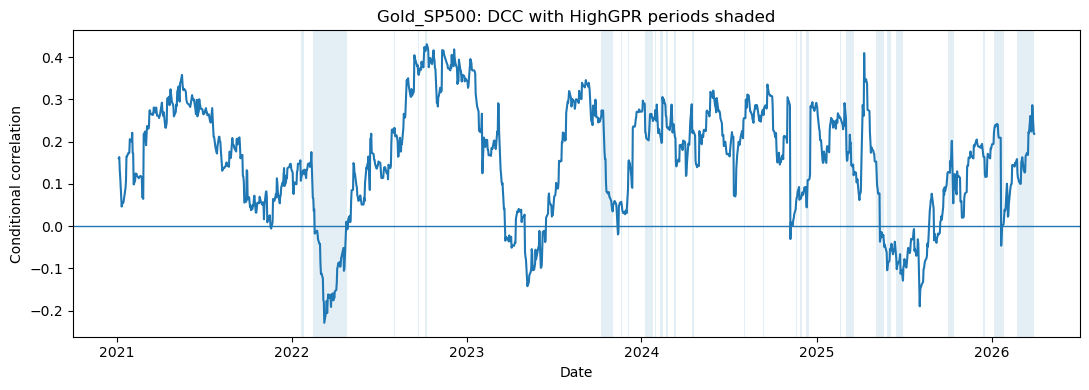

In [21]:
# 2.3.3 — PLOT THE DAILY DCC SERIES

for pair_name in selected_dcc_correlation_frame.columns:
    plt.figure(figsize=(11, 4))
    plt.plot(
        selected_dcc_correlation_frame.index,
        selected_dcc_correlation_frame[pair_name]
    )
    plt.axhline(0.0, linewidth=1)
    plt.title(f"{pair_name}: daily dynamic conditional correlation")
    plt.xlabel("Date")
    plt.ylabel("Conditional correlation")
    plt.tight_layout()
    # plt.savefig(f"{pair_name}_daily_DCC.png",dpi=300, bbox_inches="tight")
    plt.show()

# Primary-regime visualisations are separated to avoid confusing overlapping shading.
for pair_name in selected_dcc_correlation_frame.columns:
    for regime in PRIMARY_REGIMES:
        common_index = (
            selected_dcc_correlation_frame.index
            .intersection(master.index)
        )

        plt.figure(figsize=(11, 4))
        axis = plt.gca()

        axis.plot(
            common_index,
            selected_dcc_correlation_frame.loc[common_index, pair_name]
        )
        axis.axhline(0.0, linewidth=1)

        shade_binary_regime(
            axis,
            master.loc[common_index, regime]
        )

        axis.set_title(
            f"{pair_name}: DCC with {regime} periods shaded"
        )
        axis.set_xlabel("Date")
        axis.set_ylabel("Conditional correlation")
        plt.tight_layout()
        plt.show()


## 2.4 DCC regime inference

The DCC series is analysed in two complementary ways.

1. **Block-bootstrap level analysis:** estimates average correlation inside and outside each regime, confidence intervals, the regime-minus-non-regime difference, and the share of regime days with negative correlation.
2. **AR(1)-HAC regime regression:**

$$
\rho_t
=
\delta_0
+\delta_1\rho_{t-1}
+\delta_2Regime_t
+u_t.
$$

The HAC coefficient $\delta_2$ tests whether correlation changes during the regime after accounting for correlation persistence. (AR handles the fact that DCC correlation today is related to DCC correlation yesterday. So this tests whether that correlation is genuinely different during uncertainty regimes, or was impacted by persistence from previous value.)

In [22]:
# 2.4.1 — BLOCK-BOOTSTRAP FUNCTIONS

def circular_block_indices(n, block_length, rng):
    block_length = min(max(int(block_length), 1), n)
    block_count = int(np.ceil(n / block_length))
    starts = rng.integers(0, n, size=block_count)

    indices = np.concatenate([
        (start + np.arange(block_length)) % n
        for start in starts
    ])

    return indices[:n]


def percentile_interval(values, lower=0.025, upper=0.975):
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]

    if len(values) == 0:
        return np.nan, np.nan

    return (
        float(np.quantile(values, lower)),
        float(np.quantile(values, upper))
    )


def classify_average_hedge(mean_correlation, ci_low, ci_high):
    if np.isfinite(ci_high) and ci_high < 0:
        return "Strong hedge"
    if (
        np.isfinite(ci_low)
        and np.isfinite(ci_high)
        and ci_low <= 0 <= ci_high
    ):
        return "Weak-hedge compatible / inconclusive"
    if np.isfinite(ci_low) and ci_low > 0:
        return "Diversifier, not a hedge"
    return "Inconclusive"


def classify_regime_safe_haven(mean_correlation, ci_low, ci_high):
    if np.isfinite(ci_high) and ci_high < 0:
        return "Strong safe-haven evidence"
    if (
        np.isfinite(ci_low)
        and np.isfinite(ci_high)
        and ci_low <= 0 <= ci_high
    ):
        return "Weak-safe-haven compatible / inconclusive"
    if np.isfinite(ci_low) and ci_low > 0:
        return "No safe-haven evidence"
    return "Inconclusive"


def bootstrap_full_sample_correlation(
    correlation_series,
    reps=DCC_BOOTSTRAP_REPS,
    block_length=DCC_BLOCK_LENGTH,
    seed=DCC_RANDOM_SEED
):
    rho = pd.Series(correlation_series).dropna().astype(float)
    values = rho.to_numpy()
    n = len(values)
    rng = np.random.default_rng(seed)

    bootstrap_means = []

    for _ in range(reps):
        indices = circular_block_indices(
            n,
            block_length,
            rng
        )
        bootstrap_means.append(
            values[indices].mean()
        )

    ci_low, ci_high = percentile_interval(
        bootstrap_means
    )

    return {
        "Observations": n,
        "Mean DCC": values.mean(),
        "Median DCC": np.median(values),
        "Minimum DCC": values.min(),
        "Maximum DCC": values.max(),
        "Share negative": np.mean(values < 0),
        "Mean CI 2.5%": ci_low,
        "Mean CI 97.5%": ci_high,
        "Average relationship classification":
            classify_average_hedge(
                values.mean(),
                ci_low,
                ci_high
            )
    }


def bootstrap_regime_correlation(
    correlation_series,
    regime_series,
    reps=DCC_BOOTSTRAP_REPS,
    block_length=DCC_BLOCK_LENGTH,
    seed=DCC_RANDOM_SEED
):
    data = pd.concat(
        [
            pd.Series(correlation_series, name="rho"),
            pd.Series(regime_series, name="regime")
        ],
        axis=1
    ).dropna()

    data["regime"] = data["regime"].astype(int)
    n = len(data)
    rng = np.random.default_rng(seed)

    in_regime = data.loc[
        data["regime"] == 1,
        "rho"
    ]
    outside_regime = data.loc[
        data["regime"] == 0,
        "rho"
    ]

    bootstrap_in_means = []
    bootstrap_out_means = []
    bootstrap_differences = []
    bootstrap_negative_shares = []

    values = data[["rho", "regime"]].to_numpy()

    for _ in range(reps):
        indices = circular_block_indices(
            n,
            block_length,
            rng
        )
        sampled = values[indices]

        sampled_rho = sampled[:, 0]
        sampled_regime = sampled[:, 1].astype(int)

        sampled_in = sampled_rho[sampled_regime == 1]
        sampled_out = sampled_rho[sampled_regime == 0]

        if len(sampled_in) == 0 or len(sampled_out) == 0:
            continue

        in_mean = sampled_in.mean()
        out_mean = sampled_out.mean()

        bootstrap_in_means.append(in_mean)
        bootstrap_out_means.append(out_mean)
        bootstrap_differences.append(in_mean - out_mean)
        bootstrap_negative_shares.append(
            np.mean(sampled_in < 0)
        )

    in_ci_low, in_ci_high = percentile_interval(
        bootstrap_in_means
    )
    out_ci_low, out_ci_high = percentile_interval(
        bootstrap_out_means
    )
    difference_ci_low, difference_ci_high = percentile_interval(
        bootstrap_differences
    )
    negative_ci_low, negative_ci_high = percentile_interval(
        bootstrap_negative_shares
    )

    return {
        "Obs regime": len(in_regime),
        "Obs non-regime": len(outside_regime),
        "Mean DCC in regime": in_regime.mean(),
        "Regime mean CI 2.5%": in_ci_low,
        "Regime mean CI 97.5%": in_ci_high,
        "Mean DCC outside regime": outside_regime.mean(),
        "Non-regime mean CI 2.5%": out_ci_low,
        "Non-regime mean CI 97.5%": out_ci_high,
        "Regime minus non-regime":
            in_regime.mean() - outside_regime.mean(),
        "Difference CI 2.5%": difference_ci_low,
        "Difference CI 97.5%": difference_ci_high,
        "Share negative in regime":
            np.mean(in_regime < 0),
        "Negative-share CI 2.5%": negative_ci_low,
        "Negative-share CI 97.5%": negative_ci_high,
        "Safe-haven classification":
            classify_regime_safe_haven(
                in_regime.mean(),
                in_ci_low,
                in_ci_high
            ),
        "Successful bootstrap repetitions":
            len(bootstrap_in_means)
    }


In [23]:
# 2.4.2 — FULL-SAMPLE AND REGIME DCC BOOTSTRAP RESULTS

dcc_full_sample_rows = []
dcc_regime_rows = []

for pair_number, pair_name in enumerate(
    selected_dcc_correlation_frame.columns
):
    correlation_series = (
        selected_dcc_correlation_frame[pair_name]
    )

    if RUN_DCC_BOOTSTRAP:
        full_summary = bootstrap_full_sample_correlation(
            correlation_series,
            reps=DCC_BOOTSTRAP_REPS,
            block_length=DCC_BLOCK_LENGTH,
            seed=DCC_RANDOM_SEED + pair_number
        )
    else:
        full_summary = bootstrap_full_sample_correlation(
            correlation_series,
            reps=100,
            block_length=DCC_BLOCK_LENGTH,
            seed=DCC_RANDOM_SEED + pair_number
        )

    full_summary["Pair"] = pair_name
    dcc_full_sample_rows.append(full_summary)

    for regime_number, regime in enumerate(ALL_DCC_REGIMES):
        common_index = (
            correlation_series.index
            .intersection(master.index)
        )

        regime_summary = bootstrap_regime_correlation(
            correlation_series.loc[common_index],
            master.loc[common_index, regime],
            reps=(
                DCC_BOOTSTRAP_REPS
                if RUN_DCC_BOOTSTRAP
                else 100
            ),
            block_length=DCC_BLOCK_LENGTH,
            seed=(
                DCC_RANDOM_SEED
                + 100 * pair_number
                + regime_number
            )
        )

        regime_summary["Pair"] = pair_name
        regime_summary["Regime"] = regime
        regime_summary["Role"] = (
            "Primary"
            if regime in PRIMARY_REGIMES
            else "Supporting"
        )

        dcc_regime_rows.append(regime_summary)

dcc_full_sample_bootstrap = pd.DataFrame(
    dcc_full_sample_rows
)

dcc_regime_bootstrap = pd.DataFrame(
    dcc_regime_rows
)

full_sample_column_order = [
    "Pair",
    "Observations",
    "Mean DCC",
    "Mean CI 2.5%",
    "Mean CI 97.5%",
    "Median DCC",
    "Minimum DCC",
    "Maximum DCC",
    "Share negative"
]

dcc_full_sample_bootstrap = (
    dcc_full_sample_bootstrap[
        full_sample_column_order
    ]
)

regime_column_order = [
    "Pair",
    "Regime",
    "Role",
    "Obs regime",
    "Obs non-regime",
    "Mean DCC in regime",
    "Regime mean CI 2.5%",
    "Regime mean CI 97.5%",
    "Mean DCC outside regime",
    "Regime minus non-regime",
    "Difference CI 2.5%",
    "Difference CI 97.5%",
    "Share negative in regime",
    "Safe-haven classification",
    "Successful bootstrap repetitions"
]

dcc_regime_bootstrap = dcc_regime_bootstrap[
    regime_column_order
]

display_report_table(
    dcc_full_sample_bootstrap,
    "Full-sample DCC levels with moving-block confidence intervals",
    decimals=6
)

display_report_table(
    dcc_regime_bootstrap,
    "DCC levels and changes across uncertainty and stress regimes",
    decimals=6
)

#save_table(dcc_full_sample_bootstrap, "21_dcc_full_sample_bootstrap.csv")

#save_table(dcc_regime_bootstrap, "22_dcc_regime_bootstrap.csv")



Full-sample DCC levels with moving-block confidence intervals


,Pair,Observations,Mean DCC,Mean CI 2.5%,Mean CI 97.5%,Median DCC,Minimum DCC,Maximum DCC,Share negative
0,BTC_SP500,1315,0.352448,0.333273,0.369510,0.357860,0.019877,0.586877,0.000000
1,Gold_SP500,1315,0.157519,0.135046,0.178551,0.170264,-0.228998,0.430454,0.136882



DCC levels and changes across uncertainty and stress regimes


,Pair,Regime,Role,Obs regime,Obs non-regime,Mean DCC in regime,Regime mean CI 2.5%,Regime mean CI 97.5%,Mean DCC outside regime,Regime minus non-regime,Difference CI 2.5%,Difference CI 97.5%,Share negative in regime,Safe-haven classification,Successful bootstrap repetitions
0,BTC_SP500,HighEPU,Primary,263,1052,0.398640,0.375252,0.420833,0.340900,0.057740,0.027655,0.086305,0.000000,No safe-haven evidence,1000
1,BTC_SP500,HighGPR,Primary,263,1052,0.368041,0.336602,0.395842,0.348549,0.019491,-0.005354,0.044182,0.000000,No safe-haven evidence,1000
2,BTC_SP500,HighVIX,Supporting,264,1051,0.449390,0.423781,0.472928,0.328097,0.121293,0.088323,0.152207,0.000000,No safe-haven evidence,1000
3,BTC_SP500,SP500_Downside,Supporting,132,1183,0.385620,0.359116,0.411328,0.348746,0.036874,0.014421,0.059247,0.000000,No safe-haven evidence,1000
4,Gold_SP500,HighEPU,Primary,263,1052,0.106079,0.069860,0.143525,0.170379,-0.064300,-0.104490,-0.022461,0.243346,No safe-haven evidence,1000
5,Gold_SP500,HighGPR,Primary,263,1052,0.102518,0.059837,0.147725,0.171269,-0.068752,-0.113010,-0.024964,0.273764,No safe-haven evidence,1000
6,Gold_SP500,HighVIX,Supporting,264,1051,0.172934,0.122264,0.219895,0.153647,0.019287,-0.034344,0.069556,0.106061,No safe-haven evidence,1000
7,Gold_SP500,SP500_Downside,Supporting,132,1183,0.170247,0.133649,0.203804,0.156099,0.014148,-0.014005,0.040153,0.106061,No safe-haven evidence,1000


In [24]:
# AR(1)-HAC REGIME-SHIFT REGRESSIONS

def run_dcc_regime_shift_regression(
    correlation_series,
    regime_series,
    pair_name,
    regime_name,
    hac_lags=DCC_HAC_LAGS
):
    data = pd.concat(
        [
            pd.Series(correlation_series, name="rho"),
            pd.Series(regime_series, name="regime")
        ],
        axis=1
    ).dropna()

    data["rho_lag1"] = data["rho"].shift(1)
    data = data.dropna()

    y = data["rho"]
    X = sm.add_constant(
        data[["rho_lag1", "regime"]],
        has_constant="add"
    )

    result = sm.OLS(y, X).fit(
        cov_type="HAC",
        cov_kwds={"maxlags": hac_lags}
    )

    constant = result.params["const"]
    persistence = result.params["rho_lag1"]
    regime_coefficient = result.params["regime"]

    denominator = 1.0 - persistence
    long_run_effect = (
        regime_coefficient / denominator
        if abs(denominator) > 1e-6
        else np.nan
    )

    try:
        covariance = result.cov_params()
        gradient = np.array([
            0.0,
            regime_coefficient / (denominator ** 2),
            1.0 / denominator
        ])

        covariance_ordered = covariance.loc[
            ["const", "rho_lag1", "regime"],
            ["const", "rho_lag1", "regime"]
        ].to_numpy()

        long_run_variance = (
            gradient
            @ covariance_ordered
            @ gradient
        )
        long_run_se = np.sqrt(
            max(float(long_run_variance), 0.0)
        )
        long_run_ci_low = (
            long_run_effect - 1.96 * long_run_se
        )
        long_run_ci_high = (
            long_run_effect + 1.96 * long_run_se
        )
    except Exception:
        long_run_se = np.nan
        long_run_ci_low = np.nan
        long_run_ci_high = np.nan

    coefficient_ci = result.conf_int().loc["regime"]

    return {
        "Pair": pair_name,
        "Regime": regime_name,
        "Observations": int(result.nobs),
        "Lagged DCC coefficient": persistence,
        "Lagged DCC p-value": result.pvalues["rho_lag1"],
        "Regime coefficient": regime_coefficient,
        "HAC Std Error": result.bse["regime"],
        "Regime p-value": result.pvalues["regime"],
        "Regime CI 2.5%": coefficient_ci.iloc[0],
        "Regime CI 97.5%": coefficient_ci.iloc[1],
        "Implied long-run change": long_run_effect,
        "Long-run Std Error": long_run_se,
        "Long-run CI 2.5%": long_run_ci_low,
        "Long-run CI 97.5%": long_run_ci_high,
        "R-squared": result.rsquared
    }


def run_joint_uncertainty_regression(
    correlation_series,
    regime_frame,
    pair_name,
    hac_lags=DCC_HAC_LAGS
):
    data = pd.concat(
        [
            pd.Series(correlation_series, name="rho"),
            regime_frame[PRIMARY_REGIMES]
        ],
        axis=1
    ).dropna()

    data["rho_lag1"] = data["rho"].shift(1)
    data = data.dropna()

    y = data["rho"]
    X = sm.add_constant(
        data[["rho_lag1", *PRIMARY_REGIMES]],
        has_constant="add"
    )

    result = sm.OLS(y, X).fit(
        cov_type="HAC",
        cov_kwds={"maxlags": hac_lags}
    )

    rows = []

    for regime in PRIMARY_REGIMES:
        confidence_interval = result.conf_int().loc[regime]

        rows.append({
            "Pair": pair_name,
            "Regime": regime,
            "Observations": int(result.nobs),
            "Lagged DCC coefficient":
                result.params["rho_lag1"],
            "Joint-model regime coefficient":
                result.params[regime],
            "HAC Std Error":
                result.bse[regime],
            "Regime p-value":
                result.pvalues[regime],
            "Regime CI 2.5%":
                confidence_interval.iloc[0],
            "Regime CI 97.5%":
                confidence_interval.iloc[1],
            "R-squared": result.rsquared
        })

    return rows


dcc_regime_regression_rows = []
dcc_joint_uncertainty_rows = []

for pair_name in selected_dcc_correlation_frame.columns:
    rho = selected_dcc_correlation_frame[pair_name]
    common_index = rho.index.intersection(master.index)

    for regime in ALL_DCC_REGIMES:
        dcc_regime_regression_rows.append(
            run_dcc_regime_shift_regression(
                rho.loc[common_index],
                master.loc[common_index, regime],
                pair_name=pair_name,
                regime_name=regime
            )
        )

    dcc_joint_uncertainty_rows.extend(
        run_joint_uncertainty_regression(
            rho.loc[common_index],
            master.loc[common_index],
            pair_name=pair_name
        )
    )

dcc_regime_hac_results = pd.DataFrame(
    dcc_regime_regression_rows
)

dcc_joint_uncertainty_results = pd.DataFrame(
    dcc_joint_uncertainty_rows
)

display_report_table(
    dcc_regime_hac_results,
    "AR(1)-HAC tests of DCC regime shifts",
    decimals=6
)

display_report_table(
    dcc_joint_uncertainty_results,
    "Joint HighEPU–HighGPR DCC regressions",
    decimals=6
)

#save_table(dcc_regime_hac_results, "23_dcc_regime_hac_regressions.csv")

#save_table(dcc_joint_uncertainty_results, "24_dcc_joint_uncertainty_regressions.csv")



AR(1)-HAC tests of DCC regime shifts


,Pair,Regime,Observations,Lagged DCC coefficient,Lagged DCC p-value,Regime coefficient,HAC Std Error,Regime p-value,Regime CI 2.5%,Regime CI 97.5%,Implied long-run change,Long-run Std Error,Long-run CI 2.5%,Long-run CI 97.5%,R-squared
0,BTC_SP500,HighEPU,1314,0.988450,0.0,0.000206,0.001437,0.886045,-0.002610,0.003021,0.017824,0.122530,-0.222335,0.257983,0.976169
1,BTC_SP500,HighGPR,1314,0.988201,0.0,0.001791,0.001203,0.136484,-0.000566,0.004149,0.151807,0.115723,-0.075011,0.378625,0.976208
2,BTC_SP500,HighVIX,1314,0.984026,0.0,0.003074,0.001575,0.050926,-0.000012,0.006160,0.192427,0.083771,0.028235,0.356619,0.976264
3,BTC_SP500,SP500_Downside,1314,0.988903,0.0,-0.001142,0.001607,0.477519,-0.004292,0.002009,-0.102880,0.151672,-0.400157,0.194397,0.976178
4,Gold_SP500,HighEPU,1314,0.974667,0.0,-0.004541,0.002506,0.069972,-0.009453,0.000371,-0.179254,0.086252,-0.348309,-0.010200,0.954961
5,Gold_SP500,HighGPR,1314,0.974641,0.0,-0.004250,0.001843,0.021130,-0.007863,-0.000637,-0.167600,0.075355,-0.315295,-0.019905,0.954938
6,Gold_SP500,HighVIX,1314,0.977015,0.0,0.001123,0.002345,0.631931,-0.003472,0.005719,0.048865,0.099663,-0.146475,0.244205,0.954791
7,Gold_SP500,SP500_Downside,1314,0.977055,0.0,0.002456,0.002335,0.292975,-0.002121,0.007032,0.107023,0.102733,-0.094334,0.308380,0.954811



Joint HighEPU–HighGPR DCC regressions


,Pair,Regime,Observations,Lagged DCC coefficient,Joint-model regime coefficient,HAC Std Error,Regime p-value,Regime CI 2.5%,Regime CI 97.5%,R-squared
0,BTC_SP500,HighEPU,1314,0.988279,-0.000114,0.001445,0.936913,-0.002947,0.002718,0.976208
1,BTC_SP500,HighGPR,1314,0.988279,0.001811,0.001212,0.135331,-0.000566,0.004187,0.976208
2,Gold_SP500,HighEPU,1314,0.972774,-0.003992,0.002564,0.119404,-0.009017,0.001032,0.955075
3,Gold_SP500,HighGPR,1314,0.972774,-0.003646,0.001961,0.062955,-0.007488,0.000197,0.955075


### Interpretation — correlations under uncertainty and stress

**Bitcoin.** Correlation remains positive in every regime. It rises significantly during HighEPU, from 0.341 outside the regime to 0.399 inside, and rises more strongly during HighVIX, from 0.328 to 0.449. It is also higher on S&P 500 downside days. The HighGPR difference is not significant. After controlling for DCC persistence with AR(1)-HAC, neither HighEPU nor HighGPR has a significant independent effect. Bitcoin therefore provides no hedge or safe-haven evidence.

**Gold.** Correlation falls significantly during HighEPU, from 0.170 to 0.106, and during HighGPR, from 0.171 to 0.103. Both regime means remain significantly positive, so gold becomes a better diversifier rather than a strict safe haven. The AR(1)-HAC regime coefficient is negative and significant for HighGPR \(p=0.021\) and weaker for HighEPU \(p=0.070\). This supports a defensive shift in gold's equity relationship during high geopolitical risk after accounting for correlation persistence, but it does not establish strict safe-haven status because the average regime correlation remains positive. Gold does not show a lower correlation during HighVIX or S&P 500 downside days.

In the joint HighEPU–HighGPR model, neither regime coefficient reaches the 5% level. The two regimes overlap and the DCC series is highly persistent, so the separate models remain the clearer primary comparison.


## 2.5 Robustness checks

Four checks are used:

1. a symmetric GARCH-DCC benchmark;
2. top-10% EPU and GPR thresholds;
3. a global optimisation check for the main gold DCC;
4. an S&P 500 ex-Magnificent Seven benchmark.


In [25]:
# 2.5.1 — SYMMETRIC GARCH-DCC BENCHMARK

benchmark_standardised_residuals = pd.DataFrame(
    index=master.index
)

for asset_name in ["Bitcoin", "Gold", "S&P 500"]:
    benchmark_standardised_residuals[asset_name] = (
        garch_standardised_residuals[
            asset_name
        ]["GARCH(1,1)-t"]
    )

benchmark_dcc_summaries = []
benchmark_dcc_correlations = {}

for pair_name, (first_asset, second_asset) in DCC_PAIRS.items():
    (
        summary,
        correlation_series,
        whitened_frame,
        optimisation_checks
    ) = fit_dcc_pair(
        benchmark_standardised_residuals[
            [first_asset, second_asset]
        ],
        pair_name=pair_name
    )

    summary["DCC design"] = "Symmetric GARCH margins"
    benchmark_dcc_summaries.append(summary)
    benchmark_dcc_correlations[pair_name] = (
        correlation_series
    )

benchmark_dcc_summary = pd.DataFrame(
    benchmark_dcc_summaries
)

benchmark_dcc_correlation_frame = pd.DataFrame(
    benchmark_dcc_correlations
)

selected_benchmark_rows = []

for pair_name in DCC_PAIRS:
    for design_name, correlation_frame in {
        "Selected asset-specific margins":
            selected_dcc_correlation_frame,
        "Symmetric GARCH margins":
            benchmark_dcc_correlation_frame
    }.items():
        rho = correlation_frame[pair_name]
        common_index = rho.index.intersection(master.index)

        row = {
            "Pair": pair_name,
            "DCC design": design_name,
            "Average DCC": rho.mean(),
            "Minimum DCC": rho.min(),
            "Maximum DCC": rho.max(),
            "Share negative": (rho < 0).mean()
        }

        for regime in PRIMARY_REGIMES:
            row[f"{regime} mean"] = (
                rho.loc[
                    master.loc[common_index, regime] == 1
                ].mean()
            )

        selected_benchmark_rows.append(row)

dcc_margin_robustness = pd.DataFrame(
    selected_benchmark_rows
)

display_report_table(
    benchmark_dcc_summary,
    "Symmetric GARCH-DCC benchmark estimates",
    decimals=6
)

display_report_table(
    dcc_margin_robustness,
    "Selected-margin versus symmetric-margin DCC comparison",
    decimals=6
)

#save_table(benchmark_dcc_summary, "25_benchmark_garch_dcc_summary.csv")

#save_table(dcc_margin_robustness, "26_dcc_margin_robustness.csv")



Symmetric GARCH-DCC benchmark estimates


,Pair,Observations,Converged,DCC a,DCC a Std Error,DCC a p-value,DCC b,DCC b Std Error,DCC b p-value,DCC a + b,...,Minimum correlation,Maximum correlation,Share negative,Minimum R eigenvalue,Whitened residual correlation,LB whitened cross-product p (10),LB whitened cross-product p (20),Successful starts,Objective range across starts,DCC design
0,BTC_SP500,1315,True,0.015501,0.006433,0.015973,0.973754,0.012239,0.0,0.989254,...,0.123506,0.554275,0.000000,0.445725,0.005876,0.192325,0.597431,4,9.276301,Symmetric GARCH margins
1,Gold_SP500,1315,True,0.030304,0.008280,0.000252,0.946143,0.015036,0.0,0.976447,...,-0.298790,0.480175,0.148289,0.519825,0.003785,0.529826,0.821241,4,0.000000,Symmetric GARCH margins



Selected-margin versus symmetric-margin DCC comparison


,Pair,DCC design,Average DCC,Minimum DCC,Maximum DCC,Share negative,HighEPU mean,HighGPR mean
0,BTC_SP500,Selected asset-specific margins,0.352448,0.019877,0.586877,0.000000,0.398640,0.368041
1,BTC_SP500,Symmetric GARCH margins,0.366643,0.123506,0.554275,0.000000,0.408868,0.384302
2,Gold_SP500,Selected asset-specific margins,0.157519,-0.228998,0.430454,0.136882,0.106079,0.102518
3,Gold_SP500,Symmetric GARCH margins,0.154848,-0.298790,0.480175,0.148289,0.108716,0.095156


### Interpretation — GARCH benmark

The symmetric GARCH-DCC benchmark gives the same broad ranking: Bitcoin remains positively correlated with equities, while gold has a much lower correlation and occasional negative values. However, standard GARCH fails the Engle–Ng test for Bitcoin and the S&P 500. It is therefore a sensitivity benchmark, not a preferred alternative to the selected asymmetric margins.

In [26]:
# 2.5.2 — TOP-10% EPU/GPR THRESHOLD SENSITIVITY

strict_regime_mapping = {
    "HighEPU90": "HighEPU",
    "HighGPR90": "HighGPR"
}

dcc_threshold_sensitivity_rows = []

for pair_number, pair_name in enumerate(
    selected_dcc_correlation_frame.columns
):
    rho = selected_dcc_correlation_frame[pair_name]
    common_index = rho.index.intersection(master.index)

    for strict_regime, corresponding_main_regime in (
        strict_regime_mapping.items()
    ):
        strict_summary = bootstrap_regime_correlation(
            rho.loc[common_index],
            master.loc[common_index, strict_regime],
            reps=(
                DCC_BOOTSTRAP_REPS
                if RUN_DCC_BOOTSTRAP
                else 100
            ),
            block_length=DCC_BLOCK_LENGTH,
            seed=(
                DCC_RANDOM_SEED
                + 500
                + 10 * pair_number
            )
        )

        main_row = dcc_regime_bootstrap[
            (dcc_regime_bootstrap["Pair"] == pair_name)
            & (
                dcc_regime_bootstrap["Regime"]
                == corresponding_main_regime
            )
        ].iloc[0]

        dcc_threshold_sensitivity_rows.append({
            "Pair": pair_name,
            "Uncertainty source": corresponding_main_regime,
            "Top-20% regime mean":
                main_row["Mean DCC in regime"],
            "Top-20% classification":
                main_row["Safe-haven classification"],
            "Top-10% regime mean":
                strict_summary["Mean DCC in regime"],
            "Top-10% CI 2.5%":
                strict_summary["Regime mean CI 2.5%"],
            "Top-10% CI 97.5%":
                strict_summary["Regime mean CI 97.5%"],
            "Top-10% classification":
                strict_summary["Safe-haven classification"],
            "Top-10% regime minus non-regime":
                strict_summary["Regime minus non-regime"]
        })

dcc_threshold_sensitivity = pd.DataFrame(
    dcc_threshold_sensitivity_rows
)

display_report_table(
    dcc_threshold_sensitivity,
    "DCC sensitivity to top-20% versus top-10% uncertainty thresholds",
    decimals=6
)

#save_table(dcc_threshold_sensitivity, "27_dcc_threshold_sensitivity.csv")



DCC sensitivity to top-20% versus top-10% uncertainty thresholds


,Pair,Uncertainty source,Top-20% regime mean,Top-20% classification,Top-10% regime mean,Top-10% CI 2.5%,Top-10% CI 97.5%,Top-10% classification,Top-10% regime minus non-regime
0,BTC_SP500,HighEPU,0.398640,No safe-haven evidence,0.393329,0.369316,0.421181,No safe-haven evidence,0.045443
1,BTC_SP500,HighGPR,0.368041,No safe-haven evidence,0.389165,0.356610,0.420140,No safe-haven evidence,0.040815
2,Gold_SP500,HighEPU,0.106079,No safe-haven evidence,0.107202,0.060473,0.145992,No safe-haven evidence,-0.055931
3,Gold_SP500,HighGPR,0.102518,No safe-haven evidence,0.057033,-0.010600,0.125252,Weak-safe-haven compatible / inconclusive,-0.111699


In [27]:
# AR(1)-HAC robustness test for TOP-10% uncertainty regimes

import statsmodels.api as sm


def ar1_hac_regime_test(
    dcc_series,
    regime_dummy,
    hac_lags=10
):
    """
    Test whether a regime changes DCC after controlling
    for DCC persistence.

    Model:
        DCC_t = alpha + rho*DCC_(t-1)
                + beta*Regime_t + error
    """

    df = pd.DataFrame({
        "DCC": dcc_series,
        "Regime": regime_dummy
    }).dropna()

    df["DCC_lag1"] = df["DCC"].shift(1)

    df = df.dropna()

    X = sm.add_constant(
        df[
            [
                "DCC_lag1",
                "Regime"
            ]
        ]
    )

    model = sm.OLS(
        df["DCC"],
        X
    ).fit(
        cov_type="HAC",
        cov_kwds={
            "maxlags": hac_lags
        }
    )

    regime_ci = model.conf_int().loc["Regime"]

    return {
        "Regime coefficient": model.params["Regime"],
        "HAC standard error": model.bse["Regime"],
        "p-value": model.pvalues["Regime"],
        "Regime CI 2.5%": regime_ci[0],
        "Regime CI 97.5%": regime_ci[1],
        "Observations": len(df)
    }



ar1_hac_10pct_rows = []


for pair_name in selected_dcc_correlation_frame.columns:

    rho = selected_dcc_correlation_frame[pair_name]

    common_index = (
        rho.index
        .intersection(master.index)
    )

    for regime_name in [
        "HighEPU90",
        "HighGPR90"
    ]:

        result = ar1_hac_regime_test(
            dcc_series=rho.loc[common_index],
            regime_dummy=(
                master.loc[
                    common_index,
                    regime_name
                ]
            )
        )

        ar1_hac_10pct_rows.append({

            "Pair": pair_name,

            "Regime": regime_name,

            "Regime coefficient":
                result["Regime coefficient"],

            "HAC standard error":
                result["HAC standard error"],

            "p-value":
                result["p-value"],
             "Regime CI 2.5%":
                result["Regime CI 2.5%"],

            "Regime CI 97.5%":
                result["Regime CI 97.5%"],

            "Observations":
                result["Observations"]

        })


ar1_hac_10pct_results = pd.DataFrame(
    ar1_hac_10pct_rows
)


display_report_table(
    ar1_hac_10pct_results,
    "AR(1)-HAC robustness test for top-10% uncertainty regimes",
    decimals=6
)


# save_table(
#     ar1_hac_10pct_results,
#     "28_ar1_hac_top10_regime_results.csv"
# )


AR(1)-HAC robustness test for top-10% uncertainty regimes


,Pair,Regime,Regime coefficient,HAC standard error,p-value,Regime CI 2.5%,Regime CI 97.5%,Observations
0,BTC_SP500,HighEPU90,0.002752,0.001954,0.159065,-0.001078,0.006583,1314
1,BTC_SP500,HighGPR90,0.001588,0.001522,0.296586,-0.001394,0.004571,1314
2,Gold_SP500,HighEPU90,-0.006235,0.003495,0.074394,-0.013085,0.000614,1314
3,Gold_SP500,HighGPR90,-0.007184,0.002869,0.012279,-0.012806,-0.001561,1314


### Interpretation — stricter top-10% uncertainty regimes

Bitcoin remains positively correlated with equities under both top-10% uncertainty definitions. 

During the top-10% HighGPR regime, gold's mean DCC falls to 0.057 and its 95% confidence interval includes zero. This is consistent with weak safe-haven behaviour under the conventional definition. The AR(1)-HAC result also shows a significant negative shift in correlation during these periods (p=0.012), strengthening the evidence that gold becomes more defensive when geopolitical risk is extreme. However, the correlation is not significantly negative, so the evidence does not support a strong safe-haven classification.

In [28]:
# 2.5.3 — GLOBAL OPTIMISATION CHECK FOR GOLD DCC

from scipy.optimize import differential_evolution

gold_global_data = (
    selected_standardised_residuals[
        ["Gold", "S&P 500"]
    ]
    .replace([np.inf, -np.inf], np.nan)
    .dropna()
    .astype(float)
)

gold_global_data = (
    gold_global_data - gold_global_data.mean()
) / gold_global_data.std(ddof=0)

gold_global_z = gold_global_data.to_numpy()
gold_global_qbar = np.corrcoef(gold_global_z.T)

gold_global_result = differential_evolution(
    func=lambda theta: dcc_negative_log_likelihood(
        theta,
        gold_global_z,
        gold_global_qbar
    ),
    bounds=[(-10, 10), (-10, 10)],
    seed=DCC_RANDOM_SEED,
    tol=1e-9,
    polish=True,
    workers=1,
    updating="immediate"
)

gold_global_a, gold_global_b = dcc_theta_to_ab(
    gold_global_result.x
)

selected_gold_loglik = selected_dcc_summary.loc[
    selected_dcc_summary["Pair"] == "Gold_SP500",
    "DCC log likelihood"
].iloc[0]

selected_gold_objective = -selected_gold_loglik
objective_difference = (
    gold_global_result.fun
    - selected_gold_objective
)

gold_dcc_global_check = pd.DataFrame([{
    "Global optimisation success":
        gold_global_result.success,
    "Selected local objective":
        selected_gold_objective,
    "Global-search objective":
        gold_global_result.fun,
    "Global minus selected objective":
        objective_difference,
    "Global DCC a":
        gold_global_a,
    "Global DCC b":
        gold_global_b,
    "Global a + b":
        gold_global_a + gold_global_b,
    "Verification":
        (
            "Confirmed"
            if abs(objective_difference) < 1e-4
            else "Review required"
        )
}])

display_report_table(
    gold_dcc_global_check,
    "Gold DCC global-optimisation verification",
    decimals=8
)

# save_table(gold_dcc_global_check, "33_gold_dcc_global_optimisation_check.csv")



Gold DCC global-optimisation verification


,Global optimisation success,Selected local objective,Global-search objective,Global minus selected objective,Global DCC a,Global DCC b,Global a + b,Verification
0,True,-27.734211,-27.734211,0.0,0.026889,0.951145,0.978034,Confirmed


The global search matches the selected gold DCC objective and parameters exactly, confirming the preferred interior solution.


### 2.5.4 S&P 500 ex-Magnificent Seven robustness

This check asks whether the main DCC results depend on the Magnificent Seven mega-cap group in S&P 500. The official ex-Magnificent Seven price index is converted to daily log returns, filtered with the same GARCH selection procedure, and compared with conventional S&P 500 DCC estimates on identical dates.


In [29]:
# 2.5.4.1 — LOAD AND VALIDATE THE OFFICIAL SP500 EX-MAGNIFICENT SEVEN SERIES

import re


def load_sp500_ex7_index(file_path):
    path = Path(file_path)

    if not path.exists():
        raise FileNotFoundError(
            "SP500 ex-Magnificent Seven CSV was not found. "
            "Update SP500_EX7_FILE in STEP 0.1."
        )

    raw = pd.read_csv(path)
    raw.columns = raw.columns.astype(str).str.strip()

    if raw.shape[1] != 2:
        raise ValueError(
            "The SP500 ex-Magnificent Seven file should contain exactly "
            "two columns: Date and SP500Ex7."
        )

    normalised_columns = {
        re.sub(r"[^a-z0-9]", "", column.lower()): column
        for column in raw.columns
    }

    if "date" not in normalised_columns:
        raise ValueError("The CSV must contain a Date column.")

    date_column = normalised_columns["date"]

    if "sp500ex7" in normalised_columns:
        value_column = normalised_columns["sp500ex7"]
    else:
        value_column = [
            column for column in raw.columns
            if column != date_column
        ][0]
        print(
            f"WARNING: using '{value_column}' as the SP500Ex7 level column."
        )

    parsed_dates = pd.to_datetime(
        raw[date_column],
        errors="coerce"
    )

    # Retry day-first parsing only when the initial parse performs poorly.
    if parsed_dates.notna().mean() < 0.90:
        parsed_dates = pd.to_datetime(
            raw[date_column],
            errors="coerce",
            dayfirst=True
        )

    numeric_levels = pd.to_numeric(
        raw[value_column]
        .astype(str)
        .str.replace(",", "", regex=False)
        .str.replace("%", "", regex=False)
        .str.strip(),
        errors="coerce"
    )

    ex7 = pd.DataFrame({
        "Date": parsed_dates,
        "SP500Ex7_level": numeric_levels
    })

    ex7 = (
        ex7
        .dropna(subset=["Date", "SP500Ex7_level"])
        .drop_duplicates(subset="Date", keep="last")
        .set_index("Date")
        .sort_index()
        .loc[START_DATE:END_DATE]
    )

    if ex7.empty:
        raise ValueError("No valid SP500Ex7 observations remain after parsing.")

    if (ex7["SP500Ex7_level"] <= 0).any():
        raise ValueError("SP500Ex7 index levels must be strictly positive.")

    ex7["SP500Ex7_ret"] = np.log(
        ex7["SP500Ex7_level"]
        / ex7["SP500Ex7_level"].shift(1)
    )

    return ex7.dropna(subset=["SP500Ex7_ret"])


sp500_ex7 = load_sp500_ex7_index(SP500_EX7_FILE)

sp500_ex7_coverage = pd.DataFrame([{
    "Series": "S&P 500 ex-Magnificent Seven",
    "Start date": sp500_ex7.index.min(),
    "End date": sp500_ex7.index.max(),
    "Return observations": len(sp500_ex7),
    "Main-sample dates covered": len(
        master.index.intersection(sp500_ex7.index)
    ),
    "Main-sample coverage share": (
        len(master.index.intersection(sp500_ex7.index))
        / len(master)
    )
}])

display_report_table(
    sp500_ex7_coverage,
    "S&P 500 ex-Magnificent Seven data coverage",
    decimals=6
)

if sp500_ex7_coverage.loc[0, "Main-sample coverage share"] < 0.95:
    print(
        "WARNING: ex-Magnificent Seven coverage is below 95% of the main "
        "sample. The conventional S&P 500 comparison will be re-estimated "
        "on exactly matched dates."
    )

ex7_master = (
    master
    .join(sp500_ex7, how="inner")
    .dropna(subset=["SP500Ex7_ret"])
    .copy()
)

ex7_descriptive = descriptive_statistics(
    ex7_master,
    ["SP500Ex7_ret"]
)

ex7_preliminary = pd.DataFrame([
    preliminary_return_test(
        ex7_master["SP500Ex7_ret"],
        asset_name="S&P 500 ex-Magnificent Seven",
        lb_lags=(10, 20),
        arch_lags=10
    )
])

display_report_table(
    ex7_descriptive,
    "S&P 500 ex-Magnificent Seven return: descriptive and stationarity tests",
    decimals=6
)

display_report_table(
    ex7_preliminary,
    "S&P 500 ex-Magnificent Seven return: preliminary diagnostics",
    decimals=6
)



S&P 500 ex-Magnificent Seven data coverage


,Series,Start date,End date,Return observations,Main-sample dates covered,Main-sample coverage share
0,S&P 500 ex-Magnificent Seven,2021-01-04,2026-04-01,1317,1315,1.0



S&P 500 ex-Magnificent Seven return: descriptive and stationarity tests


,Variable,Observations,Mean,Std Dev,Minimum,Maximum,Skewness,Kurtosis,Jarque-Bera statistic,Jarque-Bera p-value,ADF statistic,ADF p-value,KPSS statistic,KPSS p-value
0,SP500Ex7_ret,1315,0.000337,0.009383,-0.063038,0.07331,-0.117348,8.570617,1703.300826,0.0,-22.236599,0.0,0.054089,0.1



S&P 500 ex-Magnificent Seven return: preliminary diagnostics


,Asset,LB return p (10),LB return p (20),LB squared p (10),LB squared p (20),ARCH-LM statistic (10),ARCH-LM p-value (10)
0,S&P 500 ex-Magnificent Seven,0.768384,0.361731,0.0,0.0,220.283946,0.0


The S&P 500 ex-Magnificent Seven return series has a lower mean return and lower volatility than the conventional S&P 500 over the matched sample. It remains non-normal and heavy-tailed, while both ADF and KPSS support stationarity.

There is no significant autocorrelation in the return series, but the squared-return and ARCH tests show strong volatility clustering.


In [30]:
# 2.5.4.2 — SELECT THE SP500 EX-MAGNIFICENT SEVEN GARCH MARGIN

(
    ex7_garch_fitted_models,
    ex7_garch_model_comparison,
    ex7_garch_conditional_volatility,
    ex7_garch_standardised_residuals
) = fit_candidate_garch_models(
    ex7_master["SP500Ex7_ret"],
    asset_name="S&P 500 ex-Magnificent Seven"
)

ex7_garch_model_comparison = add_garch_diagnostic_flags(
    ex7_garch_model_comparison
)

ex7_selected_garch_margin = pd.DataFrame([
    select_preferred_garch_margin(
        ex7_garch_model_comparison.copy()
    )
])

ex7_selected_columns = [
    "Asset",
    "Specification",
    "Converged",
    "Parameter-valid",
    "All core diagnostics pass",
    "Diagnostic failure count",
    "AIC",
    "BIC",
    "Persistence",
    "Persistence definition",
    "gamma[1]",
    "gamma p-value",
    "LB z p (10)",
    "LB z p (20)",
    "LB z2 p (10)",
    "LB z2 p (20)",
    "ARCH-LM p (10)",
    "Engle-Ng joint p-value",
    "Selection reason"
]

ex7_selected_garch_margin = ex7_selected_garch_margin[
    ex7_selected_columns
].reset_index(drop=True)

display_report_table(
    ex7_garch_model_comparison,
    "S&P 500 ex-Magnificent Seven GARCH candidates",
    decimals=6
)

display_report_table(
    ex7_selected_garch_margin,
    "Selected S&P 500 ex-Magnificent Seven GARCH margin",
    decimals=6
)

if not bool(
    ex7_selected_garch_margin.loc[
        0,
        "All core diagnostics pass"
    ]
):
    raise RuntimeError(
        "No ex-Magnificent Seven GARCH candidate passes every core "
        "diagnostic. Review or expand the marginal volatility models "
        "before estimating DCC."
    )

ex7_selected_specification = ex7_selected_garch_margin.loc[
    0,
    "Specification"
]

ex7_selected_sigma = (
    ex7_garch_conditional_volatility[
        ex7_selected_specification
    ] / GARCH_SCALE
).rename("S&P 500 ex-Magnificent Seven")

ex7_selected_z = (
    ex7_garch_standardised_residuals[
        ex7_selected_specification
    ]
).rename("S&P 500 ex-Magnificent Seven")



S&P 500 ex-Magnificent Seven GARCH candidates


,Asset,Specification,Observations,Converged,Parameter-valid,Log likelihood,AIC,BIC,mu,mu p-value,...,ARCH-LM p (10),Standardised-residual JB statistic,Standardised-residual JB p-value,Engle-Ng F statistic,Engle-Ng joint p-value,Mean diagnostics pass,Variance diagnostics pass,Asymmetry diagnostics pass,All core diagnostics pass,Diagnostic failure count
0,S&P 500 ex-Magnificent Seven,"GARCH(1,1)-t",1315,True,True,-1628.243691,3266.487383,3292.395342,0.066816,0.001050,...,0.113968,138.847125,0.0,4.363771,0.004569,True,True,False,False,1
1,S&P 500 ex-Magnificent Seven,"EGARCH(1,1)-t",1315,True,True,-1600.120354,3212.240709,3243.330261,0.034361,0.094434,...,0.036515,142.913386,0.0,3.854791,0.009231,True,False,False,False,2
2,S&P 500 ex-Magnificent Seven,"GJR-GARCH(1,1)-t",1315,True,True,-1607.102071,3226.204143,3257.293694,0.040548,0.048868,...,0.286275,118.370664,0.0,1.734562,0.158038,True,True,True,True,0



Selected S&P 500 ex-Magnificent Seven GARCH margin


,Asset,Specification,Converged,Parameter-valid,All core diagnostics pass,Diagnostic failure count,AIC,BIC,Persistence,Persistence definition,gamma[1],gamma p-value,LB z p (10),LB z p (20),LB z2 p (10),LB z2 p (20),ARCH-LM p (10),Engle-Ng joint p-value,Selection reason
0,S&P 500 ex-Magnificent Seven,"GJR-GARCH(1,1)-t",True,True,True,0,3226.204143,3257.293694,0.963308,alpha[1] + beta[1] + 0.5*gamma[1],0.187792,0.001526,0.874176,0.73829,0.292342,0.618626,0.286275,0.158038,Passed parameter-validity and all core standar...


In [31]:
# 2.5.4.3 — ESTIMATE EX-MAGNIFICENT SEVEN AND MATCHED-SP500 DCC MODELS

ex7_dcc_pair_map = {
    "BTC_SP500Ex7": "Bitcoin",
    "Gold_SP500Ex7": "Gold"
}

matched_sp500_pair_map = {
    "BTC_SP500Ex7": "BTC_SP500_matched",
    "Gold_SP500Ex7": "Gold_SP500_matched"
}

ex7_dcc_summaries = []
ex7_dcc_correlations = {}
matched_sp500_dcc_summaries = []
matched_sp500_dcc_correlations = {}
ex7_dcc_optimisation_checks = {}
matched_sp500_optimisation_checks = {}

for ex7_pair_name, alternative_asset in ex7_dcc_pair_map.items():
    original_pair_name = matched_sp500_pair_map[ex7_pair_name]

    matched_residuals = pd.concat(
        [
            selected_standardised_residuals[
                alternative_asset
            ].rename(alternative_asset),
            selected_standardised_residuals[
                "S&P 500"
            ].rename("S&P 500"),
            ex7_selected_z
        ],
        axis=1
    ).replace([np.inf, -np.inf], np.nan).dropna()

    (
        ex7_summary,
        ex7_correlation,
        ex7_whitened,
        ex7_optimisation
    ) = fit_dcc_pair(
        matched_residuals[
            [alternative_asset, "S&P 500 ex-Magnificent Seven"]
        ],
        pair_name=ex7_pair_name
    )

    (
        original_summary,
        original_correlation,
        original_whitened,
        original_optimisation
    ) = fit_dcc_pair(
        matched_residuals[
            [alternative_asset, "S&P 500"]
        ],
        pair_name=original_pair_name
    )

    ex7_summary["Benchmark"] = "S&P 500 ex-Magnificent Seven"
    original_summary["Benchmark"] = "Conventional S&P 500 — matched sample"

    ex7_dcc_summaries.append(ex7_summary)
    matched_sp500_dcc_summaries.append(original_summary)

    ex7_dcc_correlations[ex7_pair_name] = ex7_correlation
    matched_sp500_dcc_correlations[original_pair_name] = original_correlation

    ex7_dcc_optimisation_checks[ex7_pair_name] = ex7_optimisation
    matched_sp500_optimisation_checks[original_pair_name] = original_optimisation

ex7_dcc_summary = pd.DataFrame(ex7_dcc_summaries)
matched_sp500_dcc_summary = pd.DataFrame(
    matched_sp500_dcc_summaries
)

ex7_dcc_correlation_frame = pd.DataFrame(
    ex7_dcc_correlations
)

matched_sp500_dcc_correlation_frame = pd.DataFrame(
    matched_sp500_dcc_correlations
)

display_report_table(
    pd.concat(
        [matched_sp500_dcc_summary, ex7_dcc_summary],
        ignore_index=True
    ),
    "Matched-sample conventional and ex-Magnificent Seven DCC estimates",
    decimals=6
)

for pair_name, optimisation_table in ex7_dcc_optimisation_checks.items():
    display_report_table(
        optimisation_table,
        f"{pair_name}: DCC starting-value stability",
        decimals=8
    )



Matched-sample conventional and ex-Magnificent Seven DCC estimates


,Pair,Observations,Converged,DCC a,DCC a Std Error,DCC a p-value,DCC b,DCC b Std Error,DCC b p-value,DCC a + b,...,Minimum correlation,Maximum correlation,Share negative,Minimum R eigenvalue,Whitened residual correlation,LB whitened cross-product p (10),LB whitened cross-product p (20),Successful starts,Objective range across starts,Benchmark
0,BTC_SP500_matched,1315,True,0.020674,0.007899,0.008865,0.968202,0.013730,0.0,0.988876,...,0.019877,0.586877,0.000000,0.413123,0.004572,0.309072,0.699026,4,0.000000,Conventional S&P 500 — matched sample
1,Gold_SP500_matched,1315,True,0.026889,0.007869,0.000633,0.951145,0.013923,0.0,0.978034,...,-0.228998,0.430454,0.136882,0.569546,0.000567,0.718606,0.899148,4,10.524288,Conventional S&P 500 — matched sample
2,BTC_SP500Ex7,1315,True,0.022346,0.008655,0.009824,0.959020,0.017090,0.0,0.981366,...,0.042179,0.538468,0.000000,0.461532,0.006149,0.104260,0.512952,4,8.981928,S&P 500 ex-Magnificent Seven
3,Gold_SP500Ex7,1315,True,0.033116,0.009169,0.000304,0.938061,0.018156,0.0,0.971177,...,-0.278659,0.492612,0.107985,0.507388,0.003054,0.888534,0.927771,4,0.000000,S&P 500 ex-Magnificent Seven



BTC_SP500Ex7: DCC starting-value stability


,Start a,Start b,Success,Objective,Estimated a,Estimated b,Message
0,0.02,0.95,True,-87.449041,0.022346,0.959020,CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*...
1,0.05,0.90,True,-87.449041,0.022346,0.959020,CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*...
2,0.01,0.97,True,-87.449041,0.022346,0.959020,CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*...
3,0.10,0.80,True,-78.467113,0.000000,0.999994,CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*...



Gold_SP500Ex7: DCC starting-value stability


,Start a,Start b,Success,Objective,Estimated a,Estimated b,Message
0,0.02,0.95,True,-36.901062,0.033116,0.938061,CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*...
1,0.05,0.90,True,-36.901062,0.033116,0.938061,CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*...
2,0.01,0.97,True,-36.901062,0.033116,0.938061,CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*...
3,0.10,0.80,True,-36.901062,0.033116,0.938061,CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*...


In [32]:
# 2.5.4.4 — EX-MAGNIFICENT SEVEN DCC LEVELS AND PAIRED DIFFERENCE TESTS

EX7_ROBUSTNESS_REGIMES = PRIMARY_REGIMES


def classify_ex7_difference(ci_low, ci_high):
    if np.isfinite(ci_high) and ci_high < 0:
        return (
            "Ex-Mag7 correlation significantly lower; "
            "consistent with the seven companies strengthening co-movement"
        )
    if np.isfinite(ci_low) and ci_low > 0:
        return (
            "Ex-Mag7 correlation significantly higher; "
            "not consistent with co-movement being concentrated in the seven companies"
        )
    return "No statistically reliable benchmark difference"


def bootstrap_paired_dcc_difference(
    ex7_correlation,
    conventional_correlation,
    regime_indicator=None,
    reps=DCC_BOOTSTRAP_REPS,
    block_length=DCC_BLOCK_LENGTH,
    seed=DCC_RANDOM_SEED
):
    components = [
        pd.Series(ex7_correlation, name="rho_ex7"),
        pd.Series(
            conventional_correlation,
            name="rho_sp500"
        )
    ]

    if regime_indicator is not None:
        components.append(
            pd.Series(regime_indicator, name="regime")
        )

    data = pd.concat(components, axis=1).dropna()

    if regime_indicator is None:
        selected = data
    else:
        data["regime"] = data["regime"].astype(int)
        selected = data[data["regime"] == 1]

    if selected.empty:
        raise ValueError("No observations are available for the requested comparison.")

    point_difference = (
        selected["rho_ex7"]
        - selected["rho_sp500"]
    ).mean()

    rng = np.random.default_rng(seed)
    values = data.to_numpy()
    bootstrap_differences = []

    for _ in range(reps):
        indices = circular_block_indices(
            len(data),
            block_length,
            rng
        )
        sampled = values[indices]

        if regime_indicator is None:
            sampled_ex7 = sampled[:, 0]
            sampled_sp500 = sampled[:, 1]
        else:
            sampled_regime = sampled[:, 2].astype(int)
            mask = sampled_regime == 1

            if mask.sum() == 0:
                continue

            sampled_ex7 = sampled[mask, 0]
            sampled_sp500 = sampled[mask, 1]

        bootstrap_differences.append(
            np.mean(sampled_ex7 - sampled_sp500)
        )

    ci_low, ci_high = percentile_interval(
        bootstrap_differences
    )

    return {
        "Observations": len(selected),
        "Conventional S&P 500 mean DCC":
            selected["rho_sp500"].mean(),
        "S&P 500 ex-Mag7 mean DCC":
            selected["rho_ex7"].mean(),
        "Ex-Mag7 minus conventional DCC":
            point_difference,
        "Difference CI 2.5%": ci_low,
        "Difference CI 97.5%": ci_high,
        "Share of days ex-Mag7 DCC is lower":
            np.mean(
                selected["rho_ex7"]
                < selected["rho_sp500"]
            ),
        "Conclusion": classify_ex7_difference(
            ci_low,
            ci_high
        ),
        "Successful bootstrap repetitions":
            len(bootstrap_differences)
    }


ex7_full_sample_rows = []
ex7_regime_rows = []
ex7_paired_comparison_rows = []

for pair_number, (ex7_pair_name, alternative_asset) in enumerate(
    ex7_dcc_pair_map.items()
):
    original_pair_name = matched_sp500_pair_map[ex7_pair_name]
    rho_ex7 = ex7_dcc_correlation_frame[ex7_pair_name]
    rho_original = matched_sp500_dcc_correlation_frame[
        original_pair_name
    ]

    full_result = bootstrap_full_sample_correlation(
        rho_ex7,
        reps=(DCC_BOOTSTRAP_REPS if RUN_DCC_BOOTSTRAP else 100),
        block_length=DCC_BLOCK_LENGTH,
        seed=DCC_RANDOM_SEED + 3000 + pair_number
    )
    full_result["Pair"] = ex7_pair_name
    ex7_full_sample_rows.append(full_result)

    paired_full = bootstrap_paired_dcc_difference(
        rho_ex7,
        rho_original,
        regime_indicator=None,
        reps=(DCC_BOOTSTRAP_REPS if RUN_DCC_BOOTSTRAP else 100),
        block_length=DCC_BLOCK_LENGTH,
        seed=DCC_RANDOM_SEED + 3100 + pair_number
    )
    paired_full["Asset"] = alternative_asset
    paired_full["Sample"] = "Full sample"
    ex7_paired_comparison_rows.append(paired_full)

    common_index = (
        rho_ex7.index
        .intersection(rho_original.index)
        .intersection(master.index)
    )

    for regime_number, regime in enumerate(
        EX7_ROBUSTNESS_REGIMES
    ):
        regime_result = bootstrap_regime_correlation(
            rho_ex7.loc[common_index],
            master.loc[common_index, regime],
            reps=(DCC_BOOTSTRAP_REPS if RUN_DCC_BOOTSTRAP else 100),
            block_length=DCC_BLOCK_LENGTH,
            seed=(
                DCC_RANDOM_SEED
                + 3200
                + 100 * pair_number
                + regime_number
            )
        )
        regime_result["Pair"] = ex7_pair_name
        regime_result["Regime"] = regime
        ex7_regime_rows.append(regime_result)

        paired_regime = bootstrap_paired_dcc_difference(
            rho_ex7.loc[common_index],
            rho_original.loc[common_index],
            regime_indicator=master.loc[common_index, regime],
            reps=(DCC_BOOTSTRAP_REPS if RUN_DCC_BOOTSTRAP else 100),
            block_length=DCC_BLOCK_LENGTH,
            seed=(
                DCC_RANDOM_SEED
                + 3300
                + 100 * pair_number
                + regime_number
            )
        )
        paired_regime["Asset"] = alternative_asset
        paired_regime["Sample"] = regime
        ex7_paired_comparison_rows.append(paired_regime)

ex7_dcc_full_sample_bootstrap = pd.DataFrame(
    ex7_full_sample_rows
)

ex7_dcc_regime_bootstrap = pd.DataFrame(
    ex7_regime_rows
)

sp500ex7_paired_dcc_comparison = pd.DataFrame(
    ex7_paired_comparison_rows
)[[
    "Asset",
    "Sample",
    "Observations",
    "Conventional S&P 500 mean DCC",
    "S&P 500 ex-Mag7 mean DCC",
    "Ex-Mag7 minus conventional DCC",
    "Difference CI 2.5%",
    "Difference CI 97.5%",
    "Share of days ex-Mag7 DCC is lower",
    "Successful bootstrap repetitions"
]]

display_report_table(
    ex7_dcc_full_sample_bootstrap,
    "S&P 500 ex-Magnificent Seven: full-sample DCC evidence",
    decimals=6
)

display_report_table(
    ex7_dcc_regime_bootstrap,
    "S&P 500 ex-Magnificent Seven: HighEPU and HighGPR DCC evidence",
    decimals=6
)

display_report_table(
    sp500ex7_paired_dcc_comparison,
    "Paired DCC comparison: ex-Magnificent Seven minus conventional S&P 500",
    decimals=6
)



S&P 500 ex-Magnificent Seven: full-sample DCC evidence


,Observations,Mean DCC,Median DCC,Minimum DCC,Maximum DCC,Share negative,Mean CI 2.5%,Mean CI 97.5%,Average relationship classification,Pair
0,1315,0.332277,0.345847,0.042179,0.538468,0.000000,0.315429,0.348883,"Diversifier, not a hedge",BTC_SP500Ex7
1,1315,0.184596,0.209289,-0.278659,0.492612,0.107985,0.161361,0.206421,"Diversifier, not a hedge",Gold_SP500Ex7



S&P 500 ex-Magnificent Seven: HighEPU and HighGPR DCC evidence


,Obs regime,Obs non-regime,Mean DCC in regime,Regime mean CI 2.5%,Regime mean CI 97.5%,Mean DCC outside regime,Non-regime mean CI 2.5%,Non-regime mean CI 97.5%,Regime minus non-regime,Difference CI 2.5%,Difference CI 97.5%,Share negative in regime,Negative-share CI 2.5%,Negative-share CI 97.5%,Safe-haven classification,Successful bootstrap repetitions,Pair,Regime
0,263,1052,0.353989,0.324562,0.383338,0.326849,0.309934,0.343842,0.027140,-0.003044,0.057259,0.000000,0.000000,0.000000,No safe-haven evidence,1000,BTC_SP500Ex7,HighEPU
1,263,1052,0.339642,0.315714,0.362428,0.330435,0.312038,0.346682,0.009207,-0.011678,0.030465,0.000000,0.000000,0.000000,No safe-haven evidence,1000,BTC_SP500Ex7,HighGPR
2,263,1052,0.138809,0.101810,0.172663,0.196043,0.168229,0.220565,-0.057234,-0.096220,-0.019796,0.152091,0.076155,0.248910,No safe-haven evidence,1000,Gold_SP500Ex7,HighEPU
3,263,1052,0.129657,0.081127,0.177140,0.198331,0.176337,0.219423,-0.068674,-0.116888,-0.022264,0.254753,0.133884,0.386773,No safe-haven evidence,1000,Gold_SP500Ex7,HighGPR



Paired DCC comparison: ex-Magnificent Seven minus conventional S&P 500


,Asset,Sample,Observations,Conventional S&P 500 mean DCC,S&P 500 ex-Mag7 mean DCC,Ex-Mag7 minus conventional DCC,Difference CI 2.5%,Difference CI 97.5%,Share of days ex-Mag7 DCC is lower,Successful bootstrap repetitions
0,Bitcoin,Full sample,1315,0.352448,0.332277,-0.020171,-0.026795,-0.013641,0.691255,1000
1,Bitcoin,HighEPU,263,0.398640,0.353989,-0.044651,-0.052988,-0.033776,0.885932,1000
2,Bitcoin,HighGPR,263,0.368041,0.339642,-0.028399,-0.038178,-0.017169,0.752852,1000
3,Gold,Full sample,1315,0.157519,0.184596,0.027077,0.020576,0.034099,0.239544,1000
4,Gold,HighEPU,263,0.106079,0.138809,0.032730,0.019845,0.043589,0.182510,1000
5,Gold,HighGPR,263,0.102518,0.129657,0.027139,0.014856,0.038370,0.212928,1000


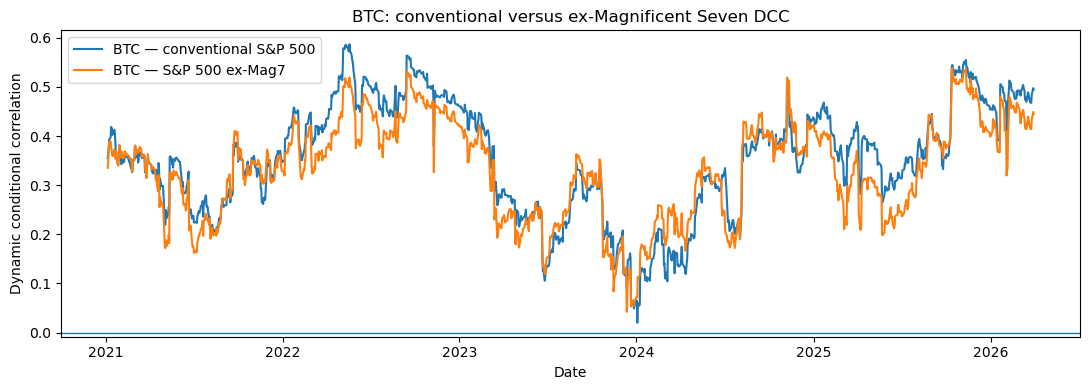

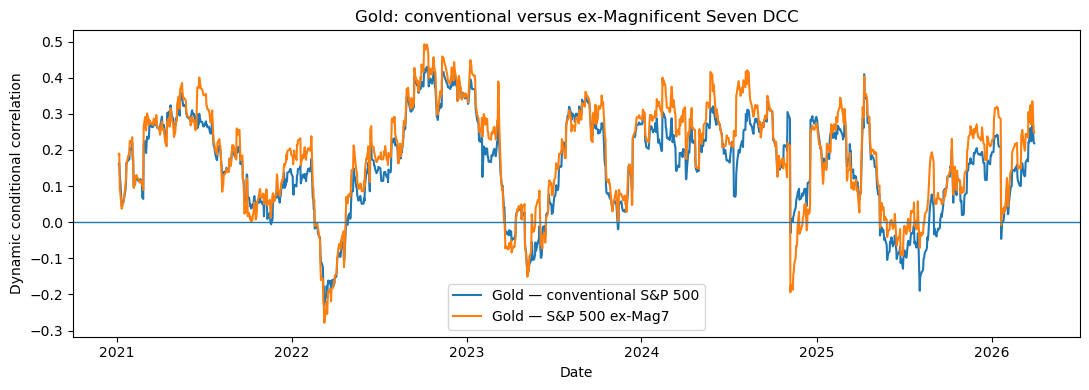

In [33]:
# 2.5.4.5 — PLOT CONVENTIONAL AND EX-MAGNIFICENT SEVEN DCC

sp500ex7_daily_dcc_comparison = pd.DataFrame({
    "BTC — conventional S&P 500":
        matched_sp500_dcc_correlation_frame[
            "BTC_SP500_matched"
        ],
    "BTC — S&P 500 ex-Mag7":
        ex7_dcc_correlation_frame[
            "BTC_SP500Ex7"
        ],
    "Gold — conventional S&P 500":
        matched_sp500_dcc_correlation_frame[
            "Gold_SP500_matched"
        ],
    "Gold — S&P 500 ex-Mag7":
        ex7_dcc_correlation_frame[
            "Gold_SP500Ex7"
        ]
}).dropna()

for asset in ["BTC", "Gold"]:
    columns = [
        f"{asset} — conventional S&P 500",
        f"{asset} — S&P 500 ex-Mag7"
    ]

    plt.figure(figsize=(11, 4))

    for column in columns:
        plt.plot(
            sp500ex7_daily_dcc_comparison.index,
            sp500ex7_daily_dcc_comparison[column],
            label=column
        )

    plt.axhline(0.0, linewidth=1)
    plt.title(
        f"{asset}: conventional versus ex-Magnificent Seven DCC"
    )
    plt.xlabel("Date")
    plt.ylabel("Dynamic conditional correlation")
    plt.legend()
    plt.tight_layout()
    plt.show()


#### Interpretation — S&P 500 ex-Magnificent Seven results

The ex-Magnificent Seven series covers the full sample. Its returns show no significant mean autocorrelation, but they have strong ARCH effects. GJR-GARCH(1,1)-t is selected, with persistence of 0.963 and a positive, significant asymmetry coefficient.

For Bitcoin, removing the seven companies lowers mean DCC from 0.352 to 0.332. The paired difference is -0.020, with a 95% confidence interval of [-0.027, -0.014]. The reduction is larger during HighEPU (-0.045) and HighGPR (-0.028). This is consistent with the seven companies strengthening Bitcoin's measured equity co-movement. Bitcoin's ex-Mag7 correlation still remains clearly positive, so its hedge classification does not change.

For gold, removing the seven companies raises mean DCC from 0.158 to 0.185. The increase is significant in the full sample and in both uncertainty regimes, suggesting that the Magnificent Seven slightly reduce, rather than inflate, gold's correlation with the conventional S&P 500. More importantly, gold's ex-Mag7 correlation still declines during HighEPU and HighGPR, so the defensive pattern is not driven by the index's mega-cap concentration.


### Robustness conclusion

The main findings survive the model and threshold checks. Bitcoin remains positively correlated with equities, while gold remains the stronger diversifier and becomes more defensive during high uncertainty. The top-10% GPR results provide the strongest safe-haven-compatible evidence for gold, although they remain inconclusive under the strict correlation-level definition.

The ex-Magnificent Seven test adds an important qualification. Mega-cap concentration strengthens Bitcoin's measured link with the S&P 500, especially during HighEPU. Gold is actually more correlated with the ex-Mag7 benchmark, so its lower correlation with the conventional index is not driven by those seven firms.


## 2.6 Portfolio-risk evaluation

### Purpose

Combine the selected GARCH volatilities and DCC correlations to determine whether Bitcoin or gold reduces S&P 500 portfolio risk.

Let

$$
h_{AA,t}=\sigma_{A,t}^{2},\qquad
h_{SS,t}=\sigma_{S,t}^{2},\qquad
h_{AS,t}=\rho_{AS,t}\sigma_{A,t}\sigma_{S,t}.
$$

The model-implied alternative-asset weight that minimises conditional portfolio variance is

$$
w_{A,t}^{*}
=
\frac{h_{SS,t}-h_{AS,t}}
{h_{AA,t}+h_{SS,t}-2h_{AS,t}}.
$$

The dynamic allocation is long-only and constrains the alternative-asset target to 0–30%:

$$
0\leq w_{A,t}\leq0.30,
\qquad
w_{S,t}=1-w_{A,t}.
$$

The fixed 90/10 portfolio is used as a direct test of whether adding a modest Bitcoin or gold position improves an S&P 500 portfolio.

### Timing and weekly implementation

The model calculates a target weight for every trading day. The implemented strategy trades only on the first trading day of each week:

1. use the target calculated on the previous trading day;
2. rebalance to that target at the start of the new week;
3. hold both assets without trading during the remainder of the week;
4. allow actual weights to drift as asset prices change;
5. rebalance again at the start of the next week;
6. deduct transaction costs only when a rebalance trade occurs.

The 30% limit applies to the rebalance target. Actual portfolio weights can move slightly above or below that level between rebalances as relative asset prices change.

Portfolio performance is therefore based on daily realised holdings and returns. Summary tables report the daily model targets and the implemented portfolio weights.

Using the previous trading day's target prevents the current day's realised return from directly setting that same day's allocation. However, the GARCH-DCC parameters are estimated over the full sample, so this is an in-sample economic evaluation rather than a fully out-of-sample trading backtest.


In [34]:
# 2.6.1 — PORTFOLIO FUNCTIONS AND SETTINGS

TRADING_DAYS_PER_YEAR = 252
FIXED_ALTERNATIVE_WEIGHT = 0.10
MIN_ALTERNATIVE_WEIGHT = 0.00
MAX_ALTERNATIVE_WEIGHT = 0.30

TRANSACTION_COST_BPS = 10
TRANSACTION_COST_RATE = TRANSACTION_COST_BPS / 10000.0

PORTFOLIO_PAIR_DETAILS = {
    "BTC_SP500": {
        "Alternative asset": "Bitcoin",
        "Alternative return": "BTC_ret"
    },
    "Gold_SP500": {
        "Alternative asset": "Gold",
        "Alternative return": "Gold_ret"
    }
}


def calculate_maximum_drawdown(simple_returns):
    simple_returns = pd.Series(simple_returns).dropna().astype(float)
    wealth = (1.0 + simple_returns).cumprod()
    running_peak = wealth.cummax()
    drawdown = wealth / running_peak - 1.0
    return float(drawdown.min())


def annualised_compound_return(simple_returns):
    simple_returns = pd.Series(simple_returns).dropna().astype(float)
    if len(simple_returns) == 0:
        return np.nan
    total_growth = (1.0 + simple_returns).prod()
    if total_growth <= 0:
        return np.nan
    return float(total_growth ** (TRADING_DAYS_PER_YEAR / len(simple_returns)) - 1.0)


def downside_deviation(simple_returns, annualise=True):
    simple_returns = pd.Series(simple_returns).dropna().astype(float)
    downside = np.minimum(simple_returns, 0.0)
    value = np.sqrt(np.mean(downside ** 2))
    if annualise:
        value *= np.sqrt(TRADING_DAYS_PER_YEAR)
    return float(value)


def expected_shortfall(simple_returns, probability=0.05):
    simple_returns = pd.Series(simple_returns).dropna().astype(float)
    if len(simple_returns) == 0:
        return np.nan
    threshold = simple_returns.quantile(probability)
    tail = simple_returns[simple_returns <= threshold]
    return float(tail.mean())


def hedging_effectiveness(portfolio_returns, benchmark_returns):
    aligned = pd.concat(
        [pd.Series(portfolio_returns, name="portfolio"),
         pd.Series(benchmark_returns, name="benchmark")],
        axis=1
    ).dropna()
    benchmark_variance = aligned["benchmark"].var(ddof=1)
    if benchmark_variance <= 0:
        return np.nan
    return float(1.0 - aligned["portfolio"].var(ddof=1) / benchmark_variance)


def portfolio_performance_row(returns, benchmark_returns, pair_name, strategy_name, sample_name):
    aligned = pd.concat(
        [pd.Series(returns, name="portfolio"),
         pd.Series(benchmark_returns, name="benchmark")],
        axis=1
    ).dropna()
    portfolio_returns = aligned["portfolio"]
    benchmark = aligned["benchmark"]
    annualised_volatility = portfolio_returns.std(ddof=1) * np.sqrt(TRADING_DAYS_PER_YEAR)
    annualised_return = annualised_compound_return(portfolio_returns)
    sharpe_ratio = annualised_return / annualised_volatility if annualised_volatility > 0 else np.nan
    return {
        "Pair": pair_name,
        "Sample": sample_name,
        "Strategy": strategy_name,
        "Observations": len(portfolio_returns),
        "Annualised return": annualised_return,
        "Annualised volatility": annualised_volatility,
        "Sharpe ratio (rf=0)": sharpe_ratio,
        "Downside deviation": downside_deviation(portfolio_returns, annualise=True),
        "VaR 5%": portfolio_returns.quantile(0.05),
        "Expected shortfall 5%": expected_shortfall(portfolio_returns, probability=0.05),
        "Maximum drawdown": calculate_maximum_drawdown(portfolio_returns) if sample_name == "Full sample" else np.nan,
        "Hedging effectiveness": hedging_effectiveness(portfolio_returns, benchmark)
    }


def simulate_weekly_long_only_portfolio(
    target_weight_signal,
    alternative_returns,
    sp500_returns,
    transaction_cost_rate=TRANSACTION_COST_RATE
):
    # Exact weekly holdings simulation using the previous trading day's signal.
    simulation = pd.concat(
        [pd.Series(target_weight_signal, name="daily_target_signal"),
         pd.Series(alternative_returns, name="alternative_return"),
         pd.Series(sp500_returns, name="sp500_return")],
        axis=1
    ).replace([np.inf, -np.inf], np.nan).dropna().sort_index()

    simulation["signal_date"] = pd.Series(simulation.index, index=simulation.index).shift(1)
    simulation["decision_target"] = (
        simulation["daily_target_signal"].shift(1)
        .clip(lower=MIN_ALTERNATIVE_WEIGHT, upper=MAX_ALTERNATIVE_WEIGHT)
    )
    simulation = simulation.dropna(subset=["decision_target", "signal_date"]).copy()

    week_id = simulation.index.to_period("W-FRI")
    simulation["rebalance"] = np.r_[True, week_id[1:] != week_id[:-1]]

    rebalance_target_weight = []
    implemented_start_weight = []
    implemented_end_weight = []
    two_sided_turnover = []
    transaction_cost_fraction = []
    portfolio_gross_return = []
    portfolio_net_return = []
    portfolio_gross_wealth = []
    portfolio_net_wealth = []

    previous_end_weight = None
    gross_wealth = 1.0
    net_wealth = 1.0

    for _, row in simulation.iterrows():
        if previous_end_weight is None:
            pretrade_weight = float(row["decision_target"])
        else:
            pretrade_weight = float(previous_end_weight)

        if bool(row["rebalance"]):
            target_weight = float(row["decision_target"])
            start_weight = target_weight
            if previous_end_weight is None:
                turnover = 0.0
            else:
                turnover = (
                    abs(target_weight - pretrade_weight)
                    + abs((1.0 - target_weight) - (1.0 - pretrade_weight))
                )
            reported_target = target_weight
        else:
            start_weight = pretrade_weight
            turnover = 0.0
            reported_target = np.nan

        cost_fraction = transaction_cost_rate * turnover
        alternative_return = float(row["alternative_return"])
        sp500_return = float(row["sp500_return"])
        gross_return = start_weight * alternative_return + (1.0 - start_weight) * sp500_return
        net_return = (1.0 - cost_fraction) * (1.0 + gross_return) - 1.0

        gross_value = 1.0 + gross_return
        if gross_value <= 0:
            raise ValueError("Portfolio value became non-positive.")

        end_weight = start_weight * (1.0 + alternative_return) / gross_value
        end_weight = float(np.clip(end_weight, 0.0, 1.0))

        gross_wealth *= 1.0 + gross_return
        net_wealth *= 1.0 + net_return

        rebalance_target_weight.append(reported_target)
        implemented_start_weight.append(start_weight)
        implemented_end_weight.append(end_weight)
        two_sided_turnover.append(turnover)
        transaction_cost_fraction.append(cost_fraction)
        portfolio_gross_return.append(gross_return)
        portfolio_net_return.append(net_return)
        portfolio_gross_wealth.append(gross_wealth)
        portfolio_net_wealth.append(net_wealth)
        previous_end_weight = end_weight

    simulation["rebalance_target_weight"] = rebalance_target_weight
    simulation["implemented_start_weight"] = implemented_start_weight
    simulation["implemented_end_weight"] = implemented_end_weight
    simulation["two_sided_turnover"] = two_sided_turnover
    simulation["transaction_cost_fraction"] = transaction_cost_fraction
    simulation["portfolio_gross_return"] = portfolio_gross_return
    simulation["portfolio_net_return"] = portfolio_net_return
    simulation["portfolio_gross_wealth"] = portfolio_gross_wealth
    simulation["portfolio_net_wealth"] = portfolio_net_wealth

    rebalance_rows = simulation.loc[simulation["rebalance"]]
    assert (rebalance_rows["signal_date"] < rebalance_rows.index).all()
    assert rebalance_rows["rebalance_target_weight"].dropna().between(MIN_ALTERNATIVE_WEIGHT, MAX_ALTERNATIVE_WEIGHT).all()
    assert simulation["implemented_start_weight"].between(0.0, 1.0).all()
    assert simulation["implemented_end_weight"].between(0.0, 1.0).all()
    return simulation


def build_pair_portfolio_data(pair_name):
    details = PORTFOLIO_PAIR_DETAILS[pair_name]
    alternative_asset = details["Alternative asset"]
    alternative_return_name = details["Alternative return"]

    data = pd.concat(
        [selected_conditional_volatility[alternative_asset].rename("sigma_alternative"),
         selected_conditional_volatility["S&P 500"].rename("sigma_sp500"),
         selected_dcc_correlation_frame[pair_name].rename("rho"),
         master[alternative_return_name].rename("alternative_log_return"),
         master["SP500_ret"].rename("sp500_log_return"),
         master[ALL_DCC_REGIMES]],
        axis=1
    ).dropna()

    data["alternative_variance"] = data["sigma_alternative"] ** 2
    data["sp500_variance"] = data["sigma_sp500"] ** 2
    data["conditional_covariance"] = data["rho"] * data["sigma_alternative"] * data["sigma_sp500"]
    denominator = data["alternative_variance"] + data["sp500_variance"] - 2.0 * data["conditional_covariance"]
    data["unconstrained_alternative_weight"] = (
        data["sp500_variance"] - data["conditional_covariance"]
    ) / denominator.replace(0.0, np.nan)
    data["daily_long_only_target_weight"] = data["unconstrained_alternative_weight"].clip(lower=MIN_ALTERNATIVE_WEIGHT, upper=MAX_ALTERNATIVE_WEIGHT)

    data["alternative_simple_return"] = np.exp(data["alternative_log_return"]) - 1.0
    data["sp500_simple_return"] = np.exp(data["sp500_log_return"]) - 1.0

    dynamic = simulate_weekly_long_only_portfolio(
        data["daily_long_only_target_weight"],
        data["alternative_simple_return"],
        data["sp500_simple_return"]
    )
    fixed_signal = pd.Series(FIXED_ALTERNATIVE_WEIGHT, index=data.index)
    fixed = simulate_weekly_long_only_portfolio(
        fixed_signal,
        data["alternative_simple_return"],
        data["sp500_simple_return"]
    )

    common_index = dynamic.index.intersection(fixed.index)
    data = data.loc[common_index].copy()
    dynamic = dynamic.loc[common_index]
    fixed = fixed.loc[common_index]

    data["SP500"] = data["sp500_simple_return"]
    data["Fixed_90_10_gross"] = fixed["portfolio_gross_return"]
    data["Fixed_90_10_net"] = fixed["portfolio_net_return"]
    data["Dynamic_MV_gross"] = dynamic["portfolio_gross_return"]
    data["Dynamic_MV_net"] = dynamic["portfolio_net_return"]

    columns_to_copy = [
        "signal_date", "decision_target", "rebalance", "rebalance_target_weight",
        "implemented_start_weight", "implemented_end_weight", "two_sided_turnover",
        "transaction_cost_fraction", "portfolio_gross_wealth", "portfolio_net_wealth"
    ]
    for column in columns_to_copy:
        data[f"dynamic_{column}"] = dynamic[column]
        data[f"fixed_{column}"] = fixed[column]
    return data


def bootstrap_hedging_effectiveness(portfolio_returns, benchmark_returns, reps=1000, block_length=10, seed=20260725):
    aligned = pd.concat(
        [pd.Series(portfolio_returns, name="portfolio"),
         pd.Series(benchmark_returns, name="benchmark")],
        axis=1
    ).dropna()
    values = aligned.to_numpy()
    n = len(values)
    rng = np.random.default_rng(seed)
    bootstrap_he = []
    for _ in range(reps):
        indices = circular_block_indices(n, block_length, rng)
        sampled = values[indices]
        benchmark_variance = np.var(sampled[:, 1], ddof=1)
        if benchmark_variance <= 0:
            continue
        bootstrap_he.append(1.0 - np.var(sampled[:, 0], ddof=1) / benchmark_variance)
    ci_low, ci_high = percentile_interval(bootstrap_he)
    return {
        "HE estimate": hedging_effectiveness(aligned["portfolio"], aligned["benchmark"]),
        "HE CI 2.5%": ci_low,
        "HE CI 97.5%": ci_high,
        "Successful repetitions": len(bootstrap_he)
    }



def bootstrap_regime_hedging_effectiveness(
    portfolio_returns,
    benchmark_returns,
    regime_indicator,
    reps=1000,
    block_length=10,
    seed=20260725
):
    # Resample blocks from the complete time series, then evaluate HE only
    # on regime observations inside each bootstrap sample. This preserves
    # both time dependence and the regime/non-regime sequence.
    aligned = pd.concat(
        [
            pd.Series(portfolio_returns, name="portfolio"),
            pd.Series(benchmark_returns, name="benchmark"),
            pd.Series(regime_indicator, name="regime")
        ],
        axis=1
    ).dropna()

    aligned["regime"] = aligned["regime"].astype(int)
    original_regime = aligned[aligned["regime"] == 1]

    original_he = hedging_effectiveness(
        original_regime["portfolio"],
        original_regime["benchmark"]
    )

    values = aligned[["portfolio", "benchmark", "regime"]].to_numpy()
    n = len(values)
    rng = np.random.default_rng(seed)
    bootstrap_he = []

    for _ in range(reps):
        indices = circular_block_indices(n, block_length, rng)
        sampled = values[indices]
        sampled_regime = sampled[sampled[:, 2] == 1]

        if len(sampled_regime) < 20:
            continue

        benchmark_variance = np.var(sampled_regime[:, 1], ddof=1)
        if benchmark_variance <= 0:
            continue

        bootstrap_he.append(
            1.0
            - np.var(sampled_regime[:, 0], ddof=1)
            / benchmark_variance
        )

    ci_low, ci_high = percentile_interval(bootstrap_he)

    return {
        "HE estimate": original_he,
        "HE CI 2.5%": ci_low,
        "HE CI 97.5%": ci_high,
        "Successful repetitions": len(bootstrap_he),
        "Original regime observations": len(original_regime)
    }


def classify_hedging_effectiveness(estimate, ci_low, ci_high):
    if ci_low > 0:
        return "Significant variance reduction"
    if ci_high < 0:
        return "Significant variance increase"
    return "No statistically reliable change"


In [35]:
# 2.6.2 — BUILD PORTFOLIOS AND COMPUTE PERFORMANCE

portfolio_pair_data = {}
portfolio_performance_rows = []
portfolio_weight_rows = []
portfolio_timing_rows = []
portfolio_he_bootstrap_rows = []

strategy_columns = {
    "SP500": "100% S&P 500",
    "Fixed_90_10_gross": "Fixed 90/10 weekly — gross",
    "Fixed_90_10_net": f"Fixed 90/10 weekly — net ({TRANSACTION_COST_BPS} bps)",
    "Dynamic_MV_gross": "Dynamic minimum variance (0–30%) — gross",
    "Dynamic_MV_net": f"Dynamic minimum variance (0–30%) — net ({TRANSACTION_COST_BPS} bps)"
}

for pair_number, pair_name in enumerate(PORTFOLIO_PAIR_DETAILS):
    pair_data = build_pair_portfolio_data(pair_name)
    portfolio_pair_data[pair_name] = pair_data

    for column_name, strategy_name in strategy_columns.items():
        portfolio_performance_rows.append(
            portfolio_performance_row(
                pair_data[column_name], pair_data["SP500"], pair_name,
                strategy_name, "Full sample"
            )
        )

    for regime in ALL_DCC_REGIMES:
        regime_data = pair_data[pair_data[regime] == 1]
        for column_name, strategy_name in strategy_columns.items():
            portfolio_performance_rows.append(
                portfolio_performance_row(
                    regime_data[column_name], regime_data["SP500"], pair_name,
                    strategy_name, regime
                )
            )

    samples = {"Full sample": pair_data}
    samples.update({regime: pair_data[pair_data[regime] == 1] for regime in ALL_DCC_REGIMES})

    for sample_name, sample_data in samples.items():
        rebalances = sample_data[sample_data["dynamic_rebalance"]]
        portfolio_weight_rows.append({
            "Pair": pair_name,
            "Sample": sample_name,
            "Mean daily model target": sample_data["daily_long_only_target_weight"].mean(),
            "Median daily model target": sample_data["daily_long_only_target_weight"].median(),
            "Mean implemented start weight": sample_data["dynamic_implemented_start_weight"].mean(),
            "Median implemented start weight": sample_data["dynamic_implemented_start_weight"].median(),
            "Minimum implemented start weight": sample_data["dynamic_implemented_start_weight"].min(),
            "Maximum implemented start weight": sample_data["dynamic_implemented_start_weight"].max(),
            "Share daily targets at 0%": np.isclose(sample_data["daily_long_only_target_weight"], MIN_ALTERNATIVE_WEIGHT).mean(),
            "Share daily targets at upper cap": np.isclose(sample_data["daily_long_only_target_weight"], MAX_ALTERNATIVE_WEIGHT).mean(),
            "Rebalance observations": int(sample_data["dynamic_rebalance"].sum()),
            "Mean turnover on rebalance days": rebalances["dynamic_two_sided_turnover"].mean()
        })

    rebalance_rows = pair_data[pair_data["dynamic_rebalance"]]
    portfolio_timing_rows.append({
        "Pair": pair_name,
        "First portfolio return date": pair_data.index.min(),
        "Last portfolio return date": pair_data.index.max(),
        "Weekly rebalances": int(pair_data["dynamic_rebalance"].sum()),
        "All signals precede rebalance date": bool((rebalance_rows["dynamic_signal_date"] < rebalance_rows.index).all()),
        "Minimum implemented weight": pair_data["dynamic_implemented_start_weight"].min(),
        "Maximum implemented weight": pair_data["dynamic_implemented_start_weight"].max(),
        "Total two-sided turnover": pair_data["dynamic_two_sided_turnover"].sum(),
        "Total transaction-cost fraction": pair_data["dynamic_transaction_cost_fraction"].sum()
    })

    for strategy_number, strategy_column in enumerate(["Fixed_90_10_net", "Dynamic_MV_net"]):
        result = bootstrap_hedging_effectiveness(
            pair_data[strategy_column], pair_data["SP500"], reps=1000,
            block_length=10,
            seed=DCC_RANDOM_SEED + 1000 + 10 * pair_number + strategy_number
        )
        result["Pair"] = pair_name
        result["Strategy"] = strategy_columns[strategy_column]
        result["Conclusion"] = classify_hedging_effectiveness(
            result["HE estimate"], result["HE CI 2.5%"], result["HE CI 97.5%"]
        )
        portfolio_he_bootstrap_rows.append(result)

portfolio_performance_table = pd.DataFrame(portfolio_performance_rows)
portfolio_weight_summary = pd.DataFrame(portfolio_weight_rows)
portfolio_timing_audit = pd.DataFrame(portfolio_timing_rows)
portfolio_he_bootstrap = pd.DataFrame(portfolio_he_bootstrap_rows)

display_report_table(portfolio_weight_summary, "Daily targets and implemented weekly portfolio weights", decimals=6)
display_report_table(portfolio_timing_audit, "Portfolio timing and constraint audit", decimals=6)
display_report_table(portfolio_he_bootstrap, "Full-sample hedging-effectiveness confidence intervals", decimals=6)

if SAVE_OUTPUTS:
    save_table(portfolio_performance_table, "28_portfolio_performance_revised.csv")
    save_table(portfolio_weight_summary, "29_portfolio_weight_summary_revised.csv")
    save_table(portfolio_timing_audit, "30_portfolio_timing_audit.csv")
    save_table(portfolio_he_bootstrap, "31_portfolio_he_bootstrap_revised.csv")
    for pair_name, pair_data in portfolio_pair_data.items():
        pair_data.to_csv(OUTPUT_DIR / f"32_{pair_name}_daily_portfolio_data_revised.csv")


Daily targets and implemented weekly portfolio weights


,Pair,Sample,Mean daily model target,Median daily model target,Mean implemented start weight,Median implemented start weight,Minimum implemented start weight,Maximum implemented start weight,Share daily targets at 0%,Share daily targets at upper cap,Rebalance observations,Mean turnover on rebalance days
0,BTC_SP500,Full sample,0.009630,0.000000,0.010330,0.000000,0.000000,0.186345,0.737443,0.002283,274,0.016209
1,BTC_SP500,HighEPU,0.014548,0.000000,0.015966,0.000000,0.000000,0.186345,0.768061,0.011407,65,0.024438
2,BTC_SP500,HighGPR,0.013250,0.000000,0.015342,0.000000,0.000000,0.175762,0.661597,0.003802,59,0.019046
3,BTC_SP500,HighVIX,0.016215,0.000000,0.015843,0.000000,0.000000,0.186345,0.737643,0.011407,59,0.026993
4,BTC_SP500,SP500_Downside,0.016054,0.000000,0.015464,0.000000,0.000000,0.182283,0.727273,0.007576,21,0.013966
5,Gold_SP500,Full sample,0.277822,0.300000,0.280045,0.298946,0.054010,0.316840,0.000000,0.729833,274,0.040384
6,Gold_SP500,HighEPU,0.254727,0.299042,0.257925,0.291810,0.054011,0.315160,0.000000,0.486692,65,0.053767
7,Gold_SP500,HighGPR,0.273876,0.300000,0.275812,0.298636,0.054011,0.316840,0.000000,0.673004,59,0.046100
8,Gold_SP500,HighVIX,0.295482,0.300000,0.291830,0.300000,0.115349,0.316840,0.000000,0.923954,59,0.025352
9,Gold_SP500,SP500_Downside,0.285327,0.300000,0.285222,0.299486,0.054059,0.310817,0.000000,0.848485,21,0.014540



Portfolio timing and constraint audit


,Pair,First portfolio return date,Last portfolio return date,Weekly rebalances,All signals precede rebalance date,Minimum implemented weight,Maximum implemented weight,Total two-sided turnover,Total transaction-cost fraction
0,BTC_SP500,2021-01-06,2026-03-31,274,True,0.00000,0.186345,4.441399,0.004441
1,Gold_SP500,2021-01-06,2026-03-31,274,True,0.05401,0.316840,11.065176,0.011065



Full-sample hedging-effectiveness confidence intervals


,HE estimate,HE CI 2.5%,HE CI 97.5%,Successful repetitions,Pair,Strategy,Conclusion
0,-0.161571,-0.229348,-0.102734,1000,BTC_SP500,Fixed 90/10 weekly — net (10 bps),Significant variance increase
1,-0.010990,-0.027605,0.002269,1000,BTC_SP500,Dynamic minimum variance (0–30%) — net (10 bps),No statistically reliable change
2,0.154453,0.141108,0.169473,1000,Gold_SP500,Fixed 90/10 weekly — net (10 bps),Significant variance reduction
3,0.360068,0.317354,0.397457,1000,Gold_SP500,Dynamic minimum variance (0–30%) — net (10 bps),Significant variance reduction


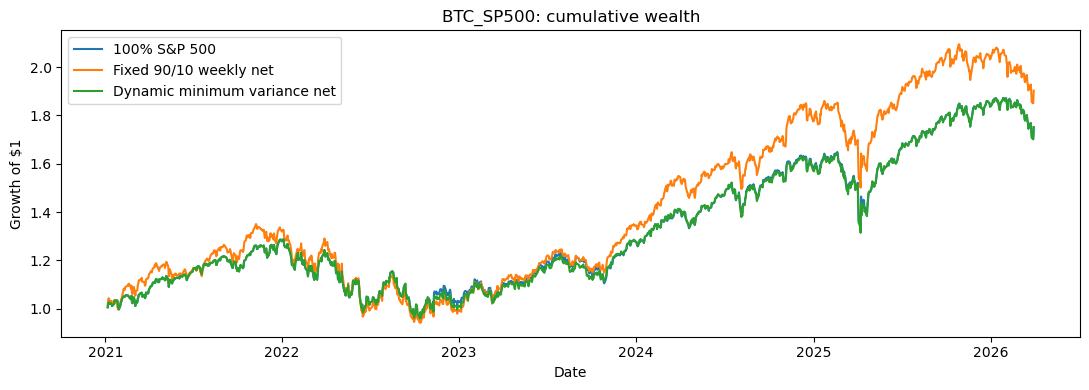

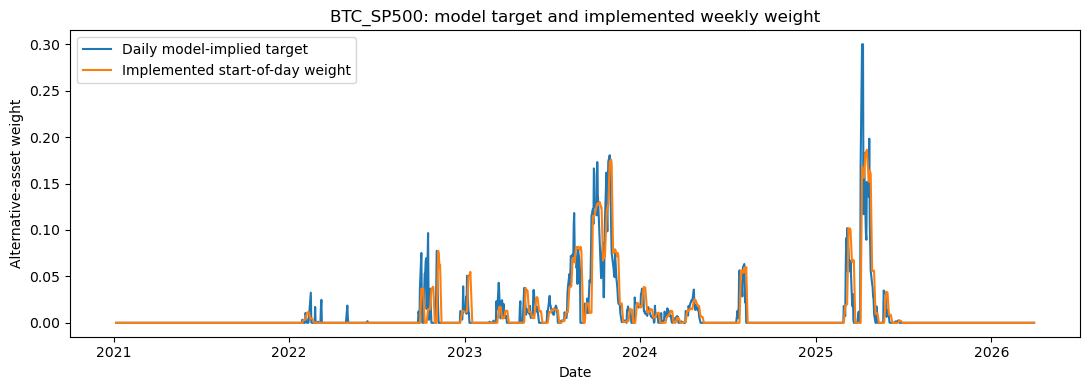

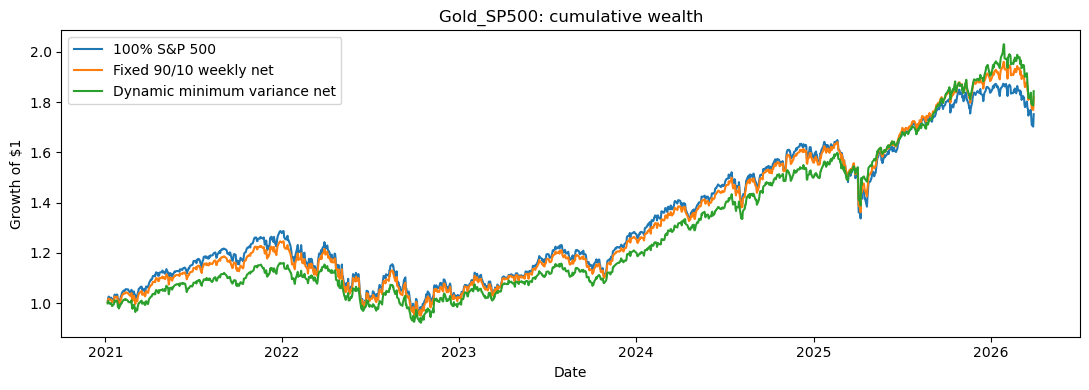

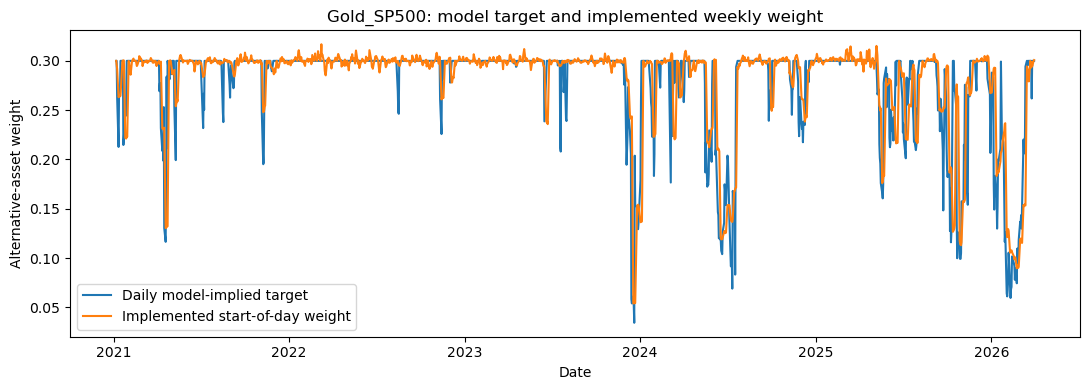

In [36]:
# 2.6.3 — PORTFOLIO WEALTH AND WEIGHT PLOTS

for pair_name, pair_data in portfolio_pair_data.items():
    wealth = pd.DataFrame({
        "100% S&P 500": (1.0 + pair_data["SP500"]).cumprod(),
        "Fixed 90/10 weekly net": (1.0 + pair_data["Fixed_90_10_net"]).cumprod(),
        "Dynamic minimum variance net": pair_data["dynamic_portfolio_net_wealth"]
    })

    plt.figure(figsize=(11, 4))
    for column in wealth.columns:
        plt.plot(wealth.index, wealth[column], label=column)
    plt.title(f"{pair_name}: cumulative wealth")
    plt.xlabel("Date")
    plt.ylabel("Growth of $1")
    plt.legend()
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(11, 4))
    plt.plot(pair_data.index, pair_data["daily_long_only_target_weight"], label="Daily model-implied target")
    plt.plot(pair_data.index, pair_data["dynamic_implemented_start_weight"], label="Implemented start-of-day weight")
    plt.title(f"{pair_name}: model target and implemented weekly weight")
    plt.xlabel("Date")
    plt.ylabel("Alternative-asset weight")
    plt.legend()
    plt.tight_layout()
    plt.show()


### 2.6.4 Analysis-ready portfolio summaries

Full-sample performance includes annualised return, volatility, Sharpe ratio, maximum drawdown, and hedging effectiveness. Regime observations are non-contiguous days, so regime analysis focuses on daily volatility, downside deviation, VaR, expected shortfall, and variance reduction.


In [37]:
# 2.6.4 — CREATE ANALYSIS-READY PORTFOLIO TABLES

full_sample_portfolio_report = (
    portfolio_performance_table[portfolio_performance_table["Sample"] == "Full sample"]
    [["Pair", "Strategy", "Annualised return", "Annualised volatility", "Sharpe ratio (rf=0)",
      "Downside deviation", "VaR 5%", "Expected shortfall 5%", "Maximum drawdown",
      "Hedging effectiveness"]]
    .reset_index(drop=True)
)

regime_risk_rows = []
for pair_name, pair_data in portfolio_pair_data.items():
    for regime in ALL_DCC_REGIMES:
        regime_data = pair_data[pair_data[regime] == 1]
        for strategy_column, strategy_name in strategy_columns.items():
            returns = regime_data[strategy_column].dropna()
            regime_risk_rows.append({
                "Pair": pair_name,
                "Regime": regime,
                "Strategy": strategy_name,
                "Observations": len(returns),
                "Mean daily return": returns.mean(),
                "Daily volatility": returns.std(ddof=1),
                "Daily downside deviation": downside_deviation(returns, annualise=False),
                "VaR 5%": returns.quantile(0.05),
                "Expected shortfall 5%": expected_shortfall(returns, probability=0.05),
                "Hedging effectiveness": hedging_effectiveness(returns, regime_data["SP500"])
            })
regime_portfolio_risk_report = pd.DataFrame(regime_risk_rows)

display_report_table(full_sample_portfolio_report, "Full-sample portfolio performance", decimals=6)
display_report_table(regime_portfolio_risk_report, "Risk performance within regime days", decimals=6)

if SAVE_OUTPUTS:
    save_table(full_sample_portfolio_report, "33_full_sample_portfolio_report_revised.csv")
    save_table(regime_portfolio_risk_report, "34_regime_portfolio_risk_report_revised.csv")



Full-sample portfolio performance


,Pair,Strategy,Annualised return,Annualised volatility,Sharpe ratio (rf=0),Downside deviation,VaR 5%,Expected shortfall 5%,Maximum drawdown,Hedging effectiveness
0,BTC_SP500,100% S&P 500,0.113508,0.168535,0.673495,0.117141,-0.016463,-0.024425,-0.254251,0.000000
1,BTC_SP500,Fixed 90/10 weekly — gross,0.131930,0.181644,0.726310,0.127148,-0.017663,-0.026598,-0.302475,-0.161605
2,BTC_SP500,Fixed 90/10 weekly — net (10 bps),0.131341,0.181641,0.723082,0.127163,-0.017663,-0.026601,-0.302800,-0.161571
3,BTC_SP500,Dynamic minimum variance (0–30%) — gross,0.114322,0.169460,0.674628,0.117767,-0.016487,-0.024622,-0.254115,-0.011005
4,BTC_SP500,Dynamic minimum variance (0–30%) — net (10 bps),0.113374,0.169459,0.669034,0.117794,-0.016487,-0.024625,-0.254256,-0.010990
5,Gold_SP500,100% S&P 500,0.113508,0.168535,0.673495,0.117141,-0.016463,-0.024425,-0.254251,0.000000
6,Gold_SP500,Fixed 90/10 weekly — gross,0.122070,0.154975,0.787675,0.107200,-0.015399,-0.022351,-0.236571,0.154448
7,Gold_SP500,Fixed 90/10 weekly — net (10 bps),0.121837,0.154974,0.786174,0.107206,-0.015399,-0.022352,-0.236728,0.154453
8,Gold_SP500,Dynamic minimum variance (0–30%) — gross,0.126789,0.134864,0.940123,0.093007,-0.013719,-0.019548,-0.204864,0.359659
9,Gold_SP500,Dynamic minimum variance (0–30%) — net (10 bps),0.124400,0.134821,0.922705,0.093040,-0.013719,-0.019551,-0.205245,0.360068



Risk performance within regime days


,Pair,Regime,Strategy,Observations,Mean daily return,Daily volatility,Daily downside deviation,VaR 5%,Expected shortfall 5%,Hedging effectiveness
0,BTC_SP500,HighEPU,100% S&P 500,263,0.000025,0.011995,0.008286,-0.016705,-0.026413,0.000000
1,BTC_SP500,HighEPU,Fixed 90/10 weekly — gross,263,0.000060,0.012353,0.008502,-0.018085,-0.027143,-0.060646
2,BTC_SP500,HighEPU,Fixed 90/10 weekly — net (10 bps),263,0.000058,0.012353,0.008503,-0.018091,-0.027147,-0.060618
3,BTC_SP500,HighEPU,Dynamic minimum variance (0–30%) — gross,263,0.000053,0.012034,0.008300,-0.016705,-0.026194,-0.006677
4,BTC_SP500,HighEPU,Dynamic minimum variance (0–30%) — net (10 bps),263,0.000047,0.012036,0.008305,-0.016705,-0.026208,-0.006978
5,BTC_SP500,HighGPR,100% S&P 500,263,0.000051,0.012058,0.007574,-0.017221,-0.022244,0.000000
6,BTC_SP500,HighGPR,Fixed 90/10 weekly — gross,263,0.000200,0.012628,0.008230,-0.018463,-0.025865,-0.096890
7,BTC_SP500,HighGPR,Fixed 90/10 weekly — net (10 bps),263,0.000198,0.012628,0.008231,-0.018463,-0.025868,-0.096859
8,BTC_SP500,HighGPR,Dynamic minimum variance (0–30%) — gross,263,0.000057,0.012124,0.007728,-0.017221,-0.023291,-0.011056
9,BTC_SP500,HighGPR,Dynamic minimum variance (0–30%) — net (10 bps),263,0.000052,0.012125,0.007733,-0.017221,-0.023304,-0.011154


### 2.6.5 Regime-specific hedging-effectiveness inference

Moving-block bootstrap intervals determine whether a portfolio significantly reduces variance, significantly increases variance, or produces no statistically reliable change inside each regime. Blocks are resampled from the complete dated series and the statistic is then calculated on regime observations within each bootstrap sample. This preserves both short-run dependence and the original regime sequence.


In [38]:
# 2.6.5 — REGIME-SPECIFIC HEDGING-EFFECTIVENESS INTERVALS

regime_he_rows = []

for pair_number, pair_name in enumerate(PORTFOLIO_PAIR_DETAILS):
    pair_data = portfolio_pair_data[pair_name]

    for regime_number, regime in enumerate(ALL_DCC_REGIMES):
        for strategy_number, strategy_column in enumerate([
            "Fixed_90_10_net",
            "Dynamic_MV_net"
        ]):
            result = bootstrap_regime_hedging_effectiveness(
                portfolio_returns=pair_data[strategy_column],
                benchmark_returns=pair_data["SP500"],
                regime_indicator=pair_data[regime],
                reps=1000,
                block_length=10,
                seed=(
                    DCC_RANDOM_SEED
                    + 2000
                    + 100 * pair_number
                    + 10 * regime_number
                    + strategy_number
                )
            )

            regime_he_rows.append({
                "Pair": pair_name,
                "Regime": regime,
                "Strategy": strategy_columns[strategy_column],
                "Regime observations": result["Original regime observations"],
                "HE estimate": result["HE estimate"],
                "HE CI 2.5%": result["HE CI 2.5%"],
                "HE CI 97.5%": result["HE CI 97.5%"],
                "Conclusion": classify_hedging_effectiveness(
                    result["HE estimate"],
                    result["HE CI 2.5%"],
                    result["HE CI 97.5%"]
                ),
                "Successful repetitions": result["Successful repetitions"]
            })

regime_portfolio_he_bootstrap = pd.DataFrame(regime_he_rows)

display_report_table(
    regime_portfolio_he_bootstrap,
    "Regime-specific hedging-effectiveness confidence intervals",
    decimals=6
)

if SAVE_OUTPUTS:
    save_table(
        regime_portfolio_he_bootstrap,
        "35_regime_portfolio_he_bootstrap_revised.csv"
    )



Regime-specific hedging-effectiveness confidence intervals


,Pair,Regime,Strategy,Regime observations,HE estimate,HE CI 2.5%,HE CI 97.5%,Conclusion,Successful repetitions
0,BTC_SP500,HighEPU,Fixed 90/10 weekly — net (10 bps),263,-0.060618,-0.262522,0.018961,No statistically reliable change,1000
1,BTC_SP500,HighEPU,Dynamic minimum variance (0–30%) — net (10 bps),263,-0.006978,-0.052946,0.020755,No statistically reliable change,1000
2,BTC_SP500,HighGPR,Fixed 90/10 weekly — net (10 bps),263,-0.096859,-0.197890,-0.023409,Significant variance increase,1000
3,BTC_SP500,HighGPR,Dynamic minimum variance (0–30%) — net (10 bps),263,-0.011154,-0.060157,0.021627,No statistically reliable change,1000
4,BTC_SP500,HighVIX,Fixed 90/10 weekly — net (10 bps),263,-0.116692,-0.220282,-0.040304,Significant variance increase,1000
5,BTC_SP500,HighVIX,Dynamic minimum variance (0–30%) — net (10 bps),263,-0.019009,-0.048501,0.002014,No statistically reliable change,1000
6,BTC_SP500,SP500_Downside,Fixed 90/10 weekly — net (10 bps),132,-0.431424,-1.098253,-0.038518,Significant variance increase,1000
7,BTC_SP500,SP500_Downside,Dynamic minimum variance (0–30%) — net (10 bps),132,-0.064448,-0.185792,-0.011642,Significant variance increase,1000
8,Gold_SP500,HighEPU,Fixed 90/10 weekly — net (10 bps),263,0.159928,0.122839,0.216530,Significant variance reduction,1000
9,Gold_SP500,HighEPU,Dynamic minimum variance (0–30%) — net (10 bps),263,0.342280,0.173779,0.427491,Significant variance reduction,1000


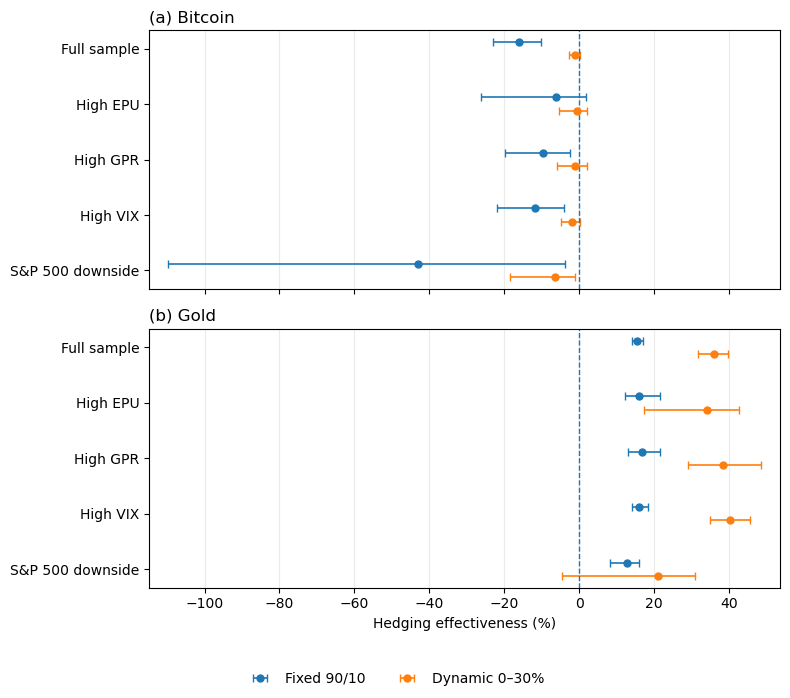

In [39]:
# 2.6.5b — FIGURE: HEDGING EFFECTIVENESS WITH 95% BOOTSTRAP CIs

# ------------------------------------------------------------
# Prepare full-sample and regime-specific HE results
# ------------------------------------------------------------

fixed_strategy = strategy_columns["Fixed_90_10_net"]
dynamic_strategy = strategy_columns["Dynamic_MV_net"]

# Full-sample bootstrap results
full_plot = portfolio_he_bootstrap.copy()
full_plot["Regime"] = "Full sample"

# Regime-specific bootstrap results
regime_plot = regime_portfolio_he_bootstrap.copy()

# Combine
he_plot_data = pd.concat(
    [
        full_plot[
            [
                "Pair",
                "Regime",
                "Strategy",
                "HE estimate",
                "HE CI 2.5%",
                "HE CI 97.5%"
            ]
        ],
        regime_plot[
            [
                "Pair",
                "Regime",
                "Strategy",
                "HE estimate",
                "HE CI 2.5%",
                "HE CI 97.5%"
            ]
        ]
    ],
    ignore_index=True
)

# Keep only the two net strategies used in the report
he_plot_data = he_plot_data[
    he_plot_data["Strategy"].isin(
        [fixed_strategy, dynamic_strategy]
    )
].copy()


# ------------------------------------------------------------
# Display order and labels
# ------------------------------------------------------------

regime_order = [
    "Full sample",
    "HighEPU",
    "HighGPR",
    "HighVIX",
    "SP500_Downside"
]

regime_labels = {
    "Full sample": "Full sample",
    "HighEPU": "High EPU",
    "HighGPR": "High GPR",
    "HighVIX": "High VIX",
    "SP500_Downside": "S&P 500 downside"
}

pair_details = [
    ("BTC_SP500", "(a) Bitcoin"),
    ("Gold_SP500", "(b) Gold")
]

strategy_details = [
    (fixed_strategy, "Fixed 90/10"),
    (dynamic_strategy, "Dynamic 0–30%")
]


# ------------------------------------------------------------
# Convert HE to percentage points
# ------------------------------------------------------------

for column in [
    "HE estimate",
    "HE CI 2.5%",
    "HE CI 97.5%"
]:
    he_plot_data[column] = he_plot_data[column] * 100


# ------------------------------------------------------------
# Use a common x-axis across both panels
# ------------------------------------------------------------

global_low = he_plot_data["HE CI 2.5%"].min()
global_high = he_plot_data["HE CI 97.5%"].max()

padding = 5

x_min = global_low - padding
x_max = global_high + padding


# ------------------------------------------------------------
# Create two-panel figure
# ------------------------------------------------------------

fig, axes = plt.subplots(
    nrows=2,
    ncols=1,
    figsize=(8, 7),
    sharex=True
)

base_y = np.arange(len(regime_order))
offsets = [-0.12, 0.12]

for ax, (pair_name, panel_title) in zip(
    axes,
    pair_details
):

    pair_data = he_plot_data[
        he_plot_data["Pair"] == pair_name
    ]

    for offset, (strategy_name, short_label) in zip(
        offsets,
        strategy_details
    ):

        strategy_data = (
            pair_data[
                pair_data["Strategy"] == strategy_name
            ]
            .set_index("Regime")
            .reindex(regime_order)
        )

        estimates = strategy_data["HE estimate"].to_numpy()
        lower = strategy_data["HE CI 2.5%"].to_numpy()
        upper = strategy_data["HE CI 97.5%"].to_numpy()

        lower_error = estimates - lower
        upper_error = upper - estimates

        ax.errorbar(
            estimates,
            base_y + offset,
            xerr=[lower_error, upper_error],
            fmt="o",
            markersize=5,
            capsize=3,
            linewidth=1.2,
            label=short_label
        )

    # Zero = no variance reduction
    ax.axvline(
        0,
        linestyle="--",
        linewidth=1
    )

    ax.set_yticks(base_y)
    ax.set_yticklabels(
        [regime_labels[r] for r in regime_order]
    )

    ax.invert_yaxis()

    ax.set_title(
        panel_title,
        loc="left"
    )

    ax.grid(
        axis="x",
        alpha=0.25
    )

    ax.set_xlim(
        x_min,
        x_max
    )


axes[-1].set_xlabel(
    "Hedging effectiveness (%)"
)

# One shared legend
handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="lower center",
    ncol=2,
    frameon=False
)

fig.tight_layout(
    rect=[0, 0.07, 1, 1]
)

# plt.savefig("Figure_2_HE_bootstrap_CI.pdf", bbox_inches="tight")
# plt.savefig("Figure_2_HE_bootstrap_CI.png", dpi=300, bbox_inches="tight")

plt.show()

### 2.6.6 Portfolio interpretation

A fixed 10% Bitcoin allocation raises variance by 16.2%, and the bootstrap confirms a significant increase. The dynamic strategy produces no reliable full-sample improvement: HE is -1.1%, with a confidence interval that includes zero. Its mean implemented Bitcoin weight is only 1.0%, the median is zero, and the model sets a zero target on 73.7% of days. During S&P 500 downside days, even the dynamic strategy significantly increases variance.

Gold gives much stronger results. The fixed 10% allocation reduces variance by 15.4%, while the dynamic 0–30% strategy reduces it by 36.0%; both reductions are statistically significant. The dynamic strategy holds an average gold weight of 28.0% and a median of 29.9%. Its target reaches the 30% cap on 73.0% of days, showing that the upper constraint is frequently binding. The fixed gold portfolio significantly reduces variance in every regime. The dynamic strategy also reduces variance during HighEPU, HighGPR, and HighVIX, but the reduction on S&P 500 downside days is not statistically reliable.

These portfolio comparisons use net returns after 10-basis-point rebalancing costs and lagged weekly implementation. The 30% restriction applies to the rebalance target, so implemented weights can drift slightly above the cap between trades.


In [40]:
# 2.6.6 — GENERATE PORTFOLIO CONCLUSIONS FROM THE REVISED RESULTS

portfolio_conclusion_rows = []
dynamic_strategy_name = strategy_columns["Dynamic_MV_net"]
fixed_strategy_name = strategy_columns["Fixed_90_10_net"]

for pair_name, details in PORTFOLIO_PAIR_DETAILS.items():
    full_dynamic = portfolio_he_bootstrap.loc[
        (portfolio_he_bootstrap["Pair"] == pair_name)
        & (portfolio_he_bootstrap["Strategy"] == dynamic_strategy_name)
    ].iloc[0]
    full_fixed = portfolio_he_bootstrap.loc[
        (portfolio_he_bootstrap["Pair"] == pair_name)
        & (portfolio_he_bootstrap["Strategy"] == fixed_strategy_name)
    ].iloc[0]
    weight_row = portfolio_weight_summary.loc[
        (portfolio_weight_summary["Pair"] == pair_name)
        & (portfolio_weight_summary["Sample"] == "Full sample")
    ].iloc[0]

    portfolio_conclusion_rows.append({
        "Asset": details["Alternative asset"],
        "Fixed 90/10 HE": full_fixed["HE estimate"],
        "Fixed 90/10 conclusion": full_fixed["Conclusion"],
        "Dynamic HE": full_dynamic["HE estimate"],
        "Dynamic HE conclusion": full_dynamic["Conclusion"],
        "Mean implemented dynamic weight": weight_row["Mean implemented start weight"],
        "Median implemented dynamic weight": weight_row["Median implemented start weight"],
        "Share targets at 0%": weight_row["Share daily targets at 0%"],
        "Share targets at upper cap": weight_row["Share daily targets at upper cap"]
    })

portfolio_conclusion_table = pd.DataFrame(portfolio_conclusion_rows)
display_report_table(portfolio_conclusion_table, "Portfolio conclusion summary", decimals=6)



Portfolio conclusion summary


,Asset,Fixed 90/10 HE,Fixed 90/10 conclusion,Dynamic HE,Dynamic HE conclusion,Mean implemented dynamic weight,Median implemented dynamic weight,Share targets at 0%,Share targets at upper cap
0,Bitcoin,-0.161571,Significant variance increase,-0.010990,No statistically reliable change,0.010330,0.000000,0.737443,0.002283
1,Gold,0.154453,Significant variance reduction,0.360068,Significant variance reduction,0.280045,0.298946,0.000000,0.729833


# FINAL ANALYTICAL SYNTHESIS

Keep three concepts separate:

1. **Return response:** how EPU and GPR relate to Bitcoin and gold returns.
2. **Hedge or safe haven:** whether equity correlation is zero or negative on average or during extreme conditions.
3. **Portfolio-risk reduction:** whether adding the asset reduces realised S&P 500 portfolio variance.

An asset may reduce portfolio risk without satisfying the strict safe-haven definition.


In [41]:
# BUILD THE FINAL EVIDENCE MATRIX WITH REVISED PORTFOLIO INFERENCE

def classify_average_dcc(ci_low, ci_high):
    if ci_high < 0:
        return "Strong hedge"
    if ci_low <= 0 <= ci_high:
        return "Weak-hedge compatible / inconclusive"
    return "Diversifier, not a hedge"


final_evidence_rows = []
dynamic_strategy_name = strategy_columns["Dynamic_MV_net"]

for pair_name, details in PORTFOLIO_PAIR_DETAILS.items():
    full_dcc = dcc_full_sample_bootstrap.loc[
        dcc_full_sample_bootstrap["Pair"] == pair_name
    ].iloc[0]

    full_he = portfolio_he_bootstrap.loc[
        (portfolio_he_bootstrap["Pair"] == pair_name)
        & (portfolio_he_bootstrap["Strategy"] == dynamic_strategy_name)
    ].iloc[0]

    row = {
        "Asset": details["Alternative asset"],
        "Pair": pair_name,
        "Full-sample mean DCC": full_dcc["Mean DCC"],
        "Full-sample DCC CI low": full_dcc["Mean CI 2.5%"],
        "Full-sample DCC CI high": full_dcc["Mean CI 97.5%"],
        "Average relationship": classify_average_dcc(
            full_dcc["Mean CI 2.5%"],
            full_dcc["Mean CI 97.5%"]
        ),
        "Dynamic HE full sample": full_he["HE estimate"],
        "Dynamic HE CI low": full_he["HE CI 2.5%"],
        "Dynamic HE CI high": full_he["HE CI 97.5%"],
        "Dynamic HE conclusion": full_he["Conclusion"]
    }

    for regime in ALL_DCC_REGIMES:
        regime_dcc = dcc_regime_bootstrap.loc[
            (dcc_regime_bootstrap["Pair"] == pair_name)
            & (dcc_regime_bootstrap["Regime"] == regime)
        ].iloc[0]

        regime_he = regime_portfolio_he_bootstrap.loc[
            (regime_portfolio_he_bootstrap["Pair"] == pair_name)
            & (regime_portfolio_he_bootstrap["Regime"] == regime)
            & (regime_portfolio_he_bootstrap["Strategy"] == dynamic_strategy_name)
        ].iloc[0]

        row[f"{regime} mean DCC"] = regime_dcc["Mean DCC in regime"]
        row[f"{regime} safe-haven classification"] = (
            regime_dcc["Safe-haven classification"]
        )
        row[f"{regime} dynamic HE"] = regime_he["HE estimate"]
        row[f"{regime} dynamic HE conclusion"] = regime_he["Conclusion"]

    final_evidence_rows.append(row)

final_research_evidence = pd.DataFrame(final_evidence_rows)

display_report_table(
    final_research_evidence,
    "Final hedge, safe-haven, and portfolio-risk evidence",
    decimals=6
)

if SAVE_OUTPUTS:
    save_table(
        final_research_evidence,
        "36_final_research_evidence_revised.csv"
    )



Final hedge, safe-haven, and portfolio-risk evidence


,Asset,Pair,Full-sample mean DCC,Full-sample DCC CI low,Full-sample DCC CI high,Average relationship,Dynamic HE full sample,Dynamic HE CI low,Dynamic HE CI high,Dynamic HE conclusion,...,HighGPR dynamic HE,HighGPR dynamic HE conclusion,HighVIX mean DCC,HighVIX safe-haven classification,HighVIX dynamic HE,HighVIX dynamic HE conclusion,SP500_Downside mean DCC,SP500_Downside safe-haven classification,SP500_Downside dynamic HE,SP500_Downside dynamic HE conclusion
0,Bitcoin,BTC_SP500,0.352448,0.333273,0.369510,"Diversifier, not a hedge",-0.010990,-0.027605,0.002269,No statistically reliable change,...,-0.011154,No statistically reliable change,0.449390,No safe-haven evidence,-0.019009,No statistically reliable change,0.385620,No safe-haven evidence,-0.064448,Significant variance increase
1,Gold,Gold_SP500,0.157519,0.135046,0.178551,"Diversifier, not a hedge",0.360068,0.317354,0.397457,Significant variance reduction,...,0.385016,Significant variance reduction,0.172934,No safe-haven evidence,0.402215,Significant variance reduction,0.170247,No safe-haven evidence,0.209408,No statistically reliable change


## Analytical conclusion

Pillar 1 finds no reliable EPU return response. GPR is weakly negative for Bitcoin and positive and significant for gold. The quantile results do not show statistically confirmed lower-tail amplification.

In Pillar 2, Bitcoin's equity correlation is positive throughout the sample and remains positive in every stress regime. It is not a hedge or safe haven. Gold has a much lower correlation, and its co-movement falls during HighEPU and HighGPR, but the regime correlations remain positive under the main definitions. Gold is therefore a defensive diversifier rather than a strict safe haven. Under the stricter top-10% GPR definition, gold's mean DCC is no longer significantly positive and the AR(1)-HAC shift becomes more negative. This is compatible with weak safe-haven behaviour during the most extreme geopolitical-risk periods, but the evidence remains inconclusive.

The ex-Magnificent Seven test shows that mega-cap concentration strengthens Bitcoin's measured S&P 500 correlation, but does not fully explain it. For gold, removing the seven companies raises correlation, so its defensive role is not driven by those firms.

Portfolio results reinforce the distinction. Bitcoin offers no reliable full-sample risk reduction, while gold significantly reduces variance under both the fixed 10% and dynamic 0–30% allocations. The dynamic gold target reaches the 30% cap on most days, so the result should be interpreted as risk reduction under a constrained allocation rather than an unconstrained minimum-variance portfolio.

Because the GARCH-DCC parameters are estimated over the full sample, the dynamic portfolio exercise is an in-sample economic evaluation rather than a fully out-of-sample investment strategy.


In [42]:
# EXPORT CORE TABLES AND DAILY SERIES

if SAVE_OUTPUTS:
    final_workbook_path = (
        OUTPUT_DIR / "Bitcoin_Gold_Analysis_Results.xlsx"
    )

    workbook_tables = {
        "Regime definitions": regime_definition_table,
        "Selected GARCH margins": selected_garch_margins,
        "Selected DCC summary": selected_dcc_summary,
        "DCC full sample": dcc_full_sample_bootstrap,
        "DCC regimes": dcc_regime_bootstrap,
        "DCC HAC shifts": dcc_regime_hac_results,
        "DCC joint uncertainty": dcc_joint_uncertainty_results,
        "DCC margin robustness": dcc_margin_robustness,
        "DCC threshold sensitivity": dcc_threshold_sensitivity,
        "Gold DCC global check": gold_dcc_global_check,
        "Ex7 coverage": sp500_ex7_coverage,
        "Ex7 descriptive": ex7_descriptive,
        "Ex7 preliminary": ex7_preliminary,
        "Ex7 GARCH candidates": ex7_garch_model_comparison,
        "Ex7 selected GARCH": ex7_selected_garch_margin,
        "Ex7 DCC summary": ex7_dcc_summary,
        "Ex7 DCC full sample": ex7_dcc_full_sample_bootstrap,
        "Ex7 DCC regimes": ex7_dcc_regime_bootstrap,
        "Ex7 paired DCC": sp500ex7_paired_dcc_comparison,
        "Portfolio full sample": full_sample_portfolio_report,
        "Portfolio regime risk": regime_portfolio_risk_report,
        "Portfolio weights": portfolio_weight_summary,
        "Portfolio timing audit": portfolio_timing_audit,
        "Portfolio conclusions": portfolio_conclusion_table,
        "Portfolio HE full sample": portfolio_he_bootstrap,
        "Portfolio HE regimes": regime_portfolio_he_bootstrap,
        "Final evidence": final_research_evidence
    }

    with pd.ExcelWriter(
        final_workbook_path,
        engine="openpyxl"
    ) as writer:
        for sheet_name, table in workbook_tables.items():
            table.to_excel(
                writer,
                sheet_name=sheet_name[:31],
                index=False
            )

        selected_dcc_correlation_frame.to_excel(
            writer,
            sheet_name="Daily DCC"
        )

        selected_conditional_volatility.to_excel(
            writer,
            sheet_name="Daily volatility"
        )

        sp500ex7_daily_dcc_comparison.to_excel(
            writer,
            sheet_name="Ex7 daily DCC"
        )

    print(f"Saved analysis workbook: {final_workbook_path}")
